# The Machine Petition — corrected pipeline (v5)
**Data collection → integrity-checked storage → LLM-style detection → validated scoring → signature analysis → phrase mining.**


## 0 · Integrity layer — validate, salvage, quarantine, atomic writes
Run this first, always. `FRESH_START=True` moves ALL existing project data to a timestamped quarantine folder (recoverable — nothing is ever hard-deleted by code).

In [1]:
#@title 0.1 · Mount Drive, integrity utilities, atomic writes
FRESH_START = False  #@param {type:"boolean"}
DEEP_VALIDATE = True #@param {type:"boolean"}

import os, json, time, gzip, math, re, random, hashlib, shutil, datetime
from pathlib import Path

IN_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in dir() else False
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path('/content/drive/MyDrive/petition_llm_project')
    LOCAL_TMP = Path('/content/_atomic_tmp')          # FIX: local scratch for atomic writes
else:
    ROOT = Path('./petition_llm_project')
    LOCAL_TMP = Path('./_atomic_tmp')

RAW   = ROOT / 'raw'
CLEAN = ROOT / 'clean'
OUT   = ROOT / 'outputs'
CALIB = ROOT / 'calibration'      # synthetic/known-label data lives HERE and only here
QUAR  = ROOT / 'quarantine'
for p in (RAW, CLEAN, OUT, CALIB, QUAR, LOCAL_TMP):
    p.mkdir(parents=True, exist_ok=True)

STAMP = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

if FRESH_START:
    dest = QUAR / f'fresh_start_{STAMP}'
    dest.mkdir(parents=True, exist_ok=True)
    moved = 0
    for d in (RAW, CLEAN, OUT):
        for f in list(d.iterdir()):
            shutil.move(str(f), str(dest / f.name)); moved += 1
    print(f'FRESH_START: moved {moved} files to {dest} (recover them from there if needed).')

# ---------- validation ----------
def quarantine(path, reason):
    dest = QUAR / f'{path.name}.{STAMP}'
    shutil.move(str(path), str(dest))
    print(f'!! QUARANTINED {path.name} -> {dest.name}  ({reason})')

def valid_parquet(path):
    """Cheap structural check + full metadata read. Returns True/False."""
    try:
        with open(path, 'rb') as f:
            if f.read(4) != b'PAR1':
                return False
            f.seek(-4, 2)
            if f.read(4) != b'PAR1':          # the exact v4 failure mode
                return False
        import pyarrow.parquet as pq
        pq.read_metadata(path)
        return True
    except Exception:
        return False

def salvage_jsonl_gz(path):
    """Stream-read a possibly-truncated gzip jsonl; keep every intact line.
    FIX: a mid-write crash no longer costs the whole checkpoint."""
    good = []
    try:
        with gzip.open(path, 'rt', encoding='utf-8') as f:
            for line in f:
                try:
                    good.append(json.loads(line))
                except json.JSONDecodeError:
                    break
    except (EOFError, OSError, gzip.BadGzipFile):
        pass  # truncated tail — keep what we decoded
    return good

def check_jsonl_gz(path):
    """Validate; if broken, salvage the readable prefix and rewrite the file.
    Returns number of records now valid in the file."""
    try:
        n = 0
        with gzip.open(path, 'rt', encoding='utf-8') as f:
            for line in f:
                json.loads(line); n += 1
        return n
    except Exception as e:
        recs = salvage_jsonl_gz(path)
        if recs:
            tmp = LOCAL_TMP / (path.name + '.salvage')
            with gzip.open(tmp, 'wt', encoding='utf-8') as f:
                for r in recs:
                    f.write(json.dumps(r, ensure_ascii=False) + '\n')
            quarantine(path, f'corrupt ({type(e).__name__}); salvaged {len(recs)} records')
            shutil.move(str(tmp), str(path))
            print(f'   -> rebuilt {path.name} with {len(recs)} salvaged records')
            return len(recs)
        quarantine(path, f'corrupt ({type(e).__name__}); nothing salvageable')
        return 0

def integrity_scan():
    """Run at startup (and any time): audit every checkpoint on Drive."""
    manifest = {}
    print('=== integrity scan:', RAW, '===')
    for p in sorted(RAW.glob('*.jsonl.gz')):
        n = check_jsonl_gz(p) if DEEP_VALIDATE else -1
        manifest[p.name] = n
        print(f'  {p.name:34s} {"OK" if n != 0 else "EMPTY"}  {n if n >= 0 else "(skipped deep check)"} records')
    print('=== integrity scan:', CLEAN, '===')
    for p in sorted(CLEAN.glob('*.parquet')):
        if valid_parquet(p):
            print(f'  {p.name:34s} OK')
        else:
            quarantine(p, 'invalid parquet — will be rebuilt by its section')
    return manifest

# ---------- atomic, verified writes ----------
def atomic_parquet(df, dest):
    """FIX for the ArrowInvalid crash: write locally, verify, then move to Drive."""
    dest = Path(dest)
    tmp = LOCAL_TMP / f'{dest.name}.{os.getpid()}.tmp'
    df.to_parquet(tmp)
    assert valid_parquet(tmp), f'internal error: freshly written parquet failed validation: {tmp}'
    shutil.move(str(tmp), str(dest))
    print(f'[atomic] wrote {dest.name}  ({dest.stat().st_size/1e6:.1f} MB, {len(df):,} rows)')

def read_parquet_checked(path, **kw):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'{path} missing — re-run the section that builds it.')
    if not valid_parquet(path):
        quarantine(path, 'invalid parquet detected at read time')
        raise RuntimeError(f'{path.name} was corrupt (quarantined). Re-run the section that builds it.')
    import pandas as pd
    return pd.read_parquet(path, **kw)

RAW_MANIFEST = integrity_scan()
print('\nProject root:', ROOT)

Mounted at /content/drive
=== integrity scan: /content/drive/MyDrive/petition_llm_project/raw ===
  _undated_roi_ru.jsonl.gz           OK  719 records
  bluehouse.jsonl.gz                 OK  451513 records
  canada.jsonl.gz                    OK  2044 records
  changeorg_au.jsonl.gz              OK  39803 records
  changeorg_other.jsonl.gz           OK  280901 records
  changeorg_treated.jsonl.gz         OK  643932 records
  roi_ru.jsonl.gz                    OK  225 records
  scotland.jsonl.gz                  OK  411 records
  uk_2010.jsonl.gz                   OK  53653 records
  uk_2015.jsonl.gz                   OK  28285 records
  uk_2017.jsonl.gz                   OK  24890 records
  uk_2019.jsonl.gz                   OK  46115 records
  uk_current.jsonl.gz                OK  14789 records
=== integrity scan: /content/drive/MyDrive/petition_llm_project/clean ===
  corpus_feats.parquet               OK
  corpus_feats_v6.parquet            OK
  lang_cache.parquet                 

In [2]:
#@title 0.2 · Install dependencies (≈2 min)
%%capture
!pip install -q requests tenacity langdetect datasketch statsmodels scipy pandas numpy matplotlib seaborn tqdm pyarrow
!pip install -q transformers torch --index-url https://download.pytorch.org/whl/cu121 || pip install -q transformers torch
!pip install -q ruptures wordfreq beautifulsoup4 lxml datasets scikit-learn
# Optional heavy extras (paraphrase clusters / topics). Safe to leave on; cells guard the imports.
!pip install -q sentence-transformers || true

In [3]:
#@title 1 · Configuration
QUICK_RUN = False  #@param {type:"boolean"}
QUICK_CAP = 3000

CUTOVER   = '2022-11-30'   # ChatGPT public release — primary pre/post boundary
# FIX: multi-dose design — test several plausible break dates, not just one
DOSES = {'chatgpt': '2022-11-30', 'gpt4': '2023-03-14', 'gpt4o_free': '2024-05-13'}
PRE_START = '2010-01-01'
END_DATE  = '2026-07-20'

USER_AGENT    = 'petition-style-research/1.1 (academic research; contact: navians@post.bgu.ac.il)'
REQUEST_DELAY = 0.5

# FIX: per-language minimum length (whitespace "words" undercount CJK massively)
MIN_LEN = {  # lang -> (mode, threshold)
    'ko': ('chars', 60), 'ja': ('chars', 60), 'zh-cn': ('chars', 60), 'zh-tw': ('chars', 60),
    'default': ('words', 30),
}

import requests
from tenacity import retry, wait_exponential, stop_after_attempt

SESSION = requests.Session()
SESSION.headers.update({'User-Agent': USER_AGENT})

@retry(wait=wait_exponential(multiplier=1, min=2, max=60), stop=stop_after_attempt(6))
def get_json(url, **params):
    r = SESSION.get(url, params=params or None, timeout=60)
    r.raise_for_status()
    time.sleep(REQUEST_DELAY)
    return r.json()

def dump_jsonl(records, path):
    """Append records to a gzipped JSONL checkpoint (multi-member gzip is fine to read)."""
    with gzip.open(path, 'at', encoding='utf-8') as f:
        for rec in records:
            f.write(json.dumps(rec, ensure_ascii=False) + '\n')

def load_jsonl(path):
    """FIX: corruption-tolerant loader — salvages instead of crashing the pipeline."""
    path = Path(path)
    if not path.exists():
        return []
    try:
        with gzip.open(path, 'rt', encoding='utf-8') as f:
            return [json.loads(line) for line in f]
    except Exception:
        print(f'[load_jsonl] {path.name} unreadable — attempting salvage...')
        check_jsonl_gz(path)
        return salvage_jsonl_gz(path) if path.exists() else []

print('Config OK. QUICK_RUN =', QUICK_RUN)

Config OK. QUICK_RUN = False


## 2 · Data collection
Each collector writes `raw/<source>.jsonl.gz`, is resumable, and is crash-isolated. Post-2022 coverage was the big gap in v4 — the priority additions are marked **(post-era)**.

| Source | Era coverage | Status |
|---|---|---|
| UK Parliament (5 archives, 2010–now) | pre + post | automated, now with moderation metadata |
| Canada e-petitions | pre + post | **manual CSV export (2 min) — do it, it worked never via API** |
| US We the People (2011–2021) | pre only | local dump ingest (download once) |
| Korea Blue House (2017–2022, 451k) | pre only | HuggingFace, automated |
| **Korea National Assembly successor (2020–now)** | **post-era** | key/CSV — endpoint must be verified by you |
| openPetition (DE) | pre + post | research API key strongly recommended |
| Change.org | post-era scale | disabled by default — check ToS/robots first |
| Generic gov portals | mixed | now with per-site date selectors |

In [4]:
#@title 2.1 · UK Parliament petitions — all five archives (resumable, + moderation metadata)
# Parliament IDs VERIFIED against the live API (2026-07): numbers are NOT chronological.
#   parliament=2 -> 2010-2015    parliament=1 -> 2015-2017
#   parliament=3 -> 2017-2019    no param     -> 2019-2024 archive
UK_ARCHIVES = {
    'uk_2010':    'https://petition.parliament.uk/archived/petitions.json?parliament=2',
    'uk_2015':    'https://petition.parliament.uk/archived/petitions.json?parliament=1',
    'uk_2017':    'https://petition.parliament.uk/archived/petitions.json?parliament=3',
    'uk_2019':    'https://petition.parliament.uk/archived/petitions.json',
    'uk_current': 'https://petition.parliament.uk/petitions.json',
}

REFRESH_UK_CURRENT = False  #@param {type:"boolean"}  (uk_current keeps growing — set True to pick up new petitions/updated counts)

def collect_uk(tag, start_url, cap=None):
    out_path = RAW / f'{tag}.jsonl.gz'
    marker = RAW / f'_done_{tag}.txt'
    # v5.2 RERUN-SAFETY: a finished crawl writes a completion marker; on later runs the
    # archive is skipped entirely (saves 30-40 min of API paging per archive). The four
    # historical archives never change. Delete raw/_done_<tag>.txt to force a re-crawl.
    if marker.exists() and out_path.exists():
        if tag == 'uk_current' and REFRESH_UK_CURRENT:
            print(f'[{tag}] REFRESH_UK_CURRENT=True — re-crawling for new/updated petitions')
        else:
            print(f'[{tag}] COMPLETE ({marker.read_text().strip()}) — skipping. '
                  f'Delete raw/{marker.name} to force a re-crawl.')
            return
    seen = {r['id'] for r in load_jsonl(out_path)}
    print(f'[{tag}] resuming with {len(seen)} already collected')
    url, page_params = start_url, {'state': 'all', 'page': 1}
    n_new, finished = 0, True
    while url:
        data = get_json(url, **(page_params or {}))
        page_params = None
        batch = []
        for item in data.get('data', []):
            if item['id'] in seen:
                continue
            a = item['attributes']
            rej = a.get('rejection') or {}
            batch.append({
                'id': item['id'],
                'title': a.get('action'),
                'text': ' '.join(filter(None, [a.get('background'), a.get('additional_details')])),
                'created_at': a.get('created_at'),
                'opened_at': a.get('opened_at'),        # FIX: censoring — exposure window
                'closed_at': a.get('closed_at'),
                'rejected_at': a.get('rejected_at'),    # FIX: moderation analysis (Section 8)
                'rejection_code': rej.get('code'),
                'rejection_details': rej.get('details'),
                'signatures': a.get('signature_count'),
                'state': a.get('state'),
                'topic_hint': (a.get('departments') or [{}])[0].get('name') if a.get('departments') else None,
                '_source': tag,
            })
            seen.add(item['id'])
        if batch:
            dump_jsonl(batch, out_path)
            n_new += len(batch)
        url = (data.get('links') or {}).get('next')
        if cap and len(seen) >= cap:
            finished = False
            break
    if finished and not cap:
        marker.write_text(f'{len(seen)} records, crawl finished {datetime.datetime.now():%Y-%m-%d %H:%M}')
    print(f'[{tag}] done — {n_new} new, {len(seen)} total')

for tag, u in UK_ARCHIVES.items():
    try:
        collect_uk(tag, u, cap=QUICK_CAP if QUICK_RUN else None)
    except Exception as e:
        print(f'[{tag}] FAILED after retries: {e} — continuing with other sources')

[uk_2010] COMPLETE (53653 records, crawl finished 2026-07-22 15:30) — skipping. Delete raw/_done_uk_2010.txt to force a re-crawl.
[uk_2015] COMPLETE (28285 records, crawl finished 2026-07-22 15:44) — skipping. Delete raw/_done_uk_2015.txt to force a re-crawl.
[uk_2017] COMPLETE (24890 records, crawl finished 2026-07-22 15:56) — skipping. Delete raw/_done_uk_2017.txt to force a re-crawl.
[uk_2019] COMPLETE (46115 records, crawl finished 2026-07-22 16:21) — skipping. Delete raw/_done_uk_2019.txt to force a re-crawl.
[uk_current] COMPLETE (14789 records, crawl finished 2026-07-22 16:27) — skipping. Delete raw/_done_uk_current.txt to force a re-crawl.


In [5]:
#@title 2.2 · Canada e-petitions — DO THE 2-MINUTE MANUAL EXPORT
# The automated endpoint failed in every test (v4 log confirms). The reliable route:
#   1. Open https://petitions.ourcommons.ca -> Search (leave all filters empty)
#   2. Export results as CSV
#   3. Upload to Drive as  raw/canada_export.csv
#   4. Run this cell. (~7k petitions, 2015-now => REAL post-2022 data from a second country.)
import pandas as pd
csv_path = RAW / 'canada_export.csv'
if csv_path.exists():
    cdf = pd.read_csv(csv_path)
    print('CSV columns found:', list(cdf.columns))
    def pick(row, *names):
        for n in names:
            if n in row and pd.notna(row[n]):
                return row[n]
        return None
    recs = []
    for _, r in cdf.iterrows():
        recs.append({
            'id': pick(r, 'Petition Number', 'PetitionNumber', 'Number'),
            'title': pick(r, 'Title', 'PetitionTitle'),
            'text': pick(r, 'Petition Text', 'PetitionText', 'Text') or '',
            'created_at': pick(r, 'Open for Signature Date', 'OpenForSignatureDate', 'Presented Date'),
            'signatures': pick(r, 'Signatures', 'SignatureCount', 'Total Signatures'),
            'state': pick(r, 'Status', 'State'),
            'topic_hint': pick(r, 'Keywords', 'Keyword'),
            '_source': 'canada',
        })
    recs = [x for x in recs if x['id'] is not None]
    out = RAW / 'canada.jsonl.gz'
    if out.exists():
        quarantine(out, 'replaced by authoritative CSV export')
    dump_jsonl(recs, out)
    print(f'Ingested {len(recs)} Canadian petitions from CSV export.')
else:
    print('raw/canada_export.csv not present yet — export it manually (instructions above).')

raw/canada_export.csv not present yet — export it manually (instructions above).


In [6]:
#@title 2.3 · US "We the People" — local dump ingest (pre-LLM baseline)
# The live api.whitehouse.gov endpoint is dead (v4 log confirms). Free mirrors of the full
# dataset exist on archive.org and Harvard Dataverse (search: "We the People petitions dataset").
# Download once, put the JSON (or JSONL) at raw/wtp_dump.json, run this cell.
WTP_LOCAL = RAW / 'wtp_dump.json'

def ingest_wtp():
    out_path = RAW / 'wtp.jsonl.gz'
    seen = {r['id'] for r in load_jsonl(out_path)}
    raw = json.load(open(WTP_LOCAL))
    items = raw.get('results', raw if isinstance(raw, list) else [])
    batch = []
    for it in items:
        if it.get('id') in seen:
            continue
        batch.append({
            'id': it.get('id'),
            'title': it.get('title'),
            'text': it.get('body', ''),
            'created_at': it.get('created'),   # unix ts — parse_date handles it
            'signatures': it.get('signatureCount'),
            'state': it.get('status'),
            'topic_hint': (it.get('issues') or [{}])[0].get('name') if it.get('issues') else None,
            '_source': 'wtp',
        })
    dump_jsonl(batch, out_path)
    print(f'[wtp] ingested {len(batch)} from local dump')

if WTP_LOCAL.exists():
    try:
        ingest_wtp()
    except Exception as e:
        print('[wtp] FAILED:', e)
else:
    print('No raw/wtp_dump.json — download a public dump first (see instructions above). Skipping.')

No raw/wtp_dump.json — download a public dump first (see instructions above). Skipping.


In [7]:
#@title 2.4 · Korea Blue House archive (451k, 2017–2022, pre-LLM baseline) — HuggingFace
RUN_BLUEHOUSE = True  #@param {type:"boolean"}

def _run_bluehouse():
    from datasets import load_dataset
    out_path = RAW / 'bluehouse.jsonl.gz'
    expected = 3000 if QUICK_RUN else 400000
    if out_path.exists() and len(load_jsonl(out_path)) >= expected:
        print('[bluehouse] already ingested — skipping')
        return
    split = 'train[:3000]' if QUICK_RUN else 'train'
    ds = load_dataset('dev7halo/bluehouse-national-petition', split=split)
    if out_path.exists():
        quarantine(out_path, 'partial bluehouse ingest — restarting cleanly')
    batch, n = [], 0
    for r in ds:
        sigs = str(r.get('참여인원') or '0').replace(',', '')
        batch.append({
            'id': r.get('number'),
            'title': r.get('제목') or '',
            'text': r.get('청원내용') or '',
            'created_at': r.get('청원시작'),
            'signatures': int(sigs) if sigs.isdigit() else None,
            'state': r.get('답변상태'),
            'topic_hint': r.get('카테고리'),
            '_source': 'bluehouse',
        })
        if len(batch) >= 20000:
            dump_jsonl(batch, out_path); n += len(batch); batch = []
            print(f'  {n} written...')
    if batch:
        dump_jsonl(batch, out_path); n += len(batch)
    print(f'[bluehouse] ingested {n} petitions')

if RUN_BLUEHOUSE:
    try:
        _run_bluehouse()
    except Exception as e:
        print('[bluehouse] FAILED:', e, '— continuing')
else:
    print('Skipped Blue House.')

[bluehouse] already ingested — skipping


In [8]:
#@title 2.5 · (post-era) Korea National Assembly petitions (국회 국민동의청원, 2020–now)
# WHY THIS MATTERS: it is the successor to the Blue House system and spans the post-LLM era,
# turning the 451k Korean pre-era rows into one half of a real pre/post design in a second language.
#
# HONESTY NOTE — read before running: I cannot verify the exact API schema from here.
# Two supported routes, in order of reliability:
#   (A) Open Data portal key: the Korean National Assembly publishes open APIs at
#       https://open.assembly.go.kr (free registration). Find the petitions dataset
#       ("국민동의청원"), copy its endpoint + field names into the CONFIG block below.
#   (B) Manual export: if you obtain any CSV/JSON dump of the platform, save it as
#       raw/kr_assembly_export.csv (columns: id,title,text,created_at,signatures,state)
#       and this cell ingests it directly.
# The cell NEVER fabricates records: if neither route is configured, it just skips.

KR_ASSEMBLY_KEY      = ''  #@param {type:"string"}
KR_ASSEMBLY_ENDPOINT = ''  #@param {type:"string"}  (paste the verified open.assembly.go.kr endpoint URL)
KR_FIELD_MAP = {  # edit after checking the real response schema
    'id': 'BILL_NO', 'title': 'BILL_NAME', 'text': 'CONTENT',
    'created_at': 'PROPOSE_DT', 'signatures': 'AGREE_COUNT', 'state': 'PROC_RESULT',
}

import pandas as pd
out_path = RAW / 'kr_assembly.jsonl.gz'
csv_path = RAW / 'kr_assembly_export.csv'

def ingest_kr_csv():
    cdf = pd.read_csv(csv_path)
    recs = [{'id': r.get('id'), 'title': r.get('title'), 'text': r.get('text') or '',
             'created_at': r.get('created_at'), 'signatures': r.get('signatures'),
             'state': r.get('state'), 'topic_hint': r.get('topic'), '_source': 'kr_assembly'}
            for _, r in cdf.iterrows()]
    recs = [x for x in recs if x['id'] is not None]
    if out_path.exists():
        quarantine(out_path, 'replaced by manual export')
    dump_jsonl(recs, out_path)
    print(f'[kr_assembly] ingested {len(recs)} from CSV export')

def collect_kr_api(cap=None):
    marker = RAW / '_done_kr_assembly.txt'
    if marker.exists() and out_path.exists():   # v5.2 rerun-safety
        print(f'[kr_assembly] COMPLETE ({marker.read_text().strip()}) — skipping. '
              f'Delete raw/{marker.name} to re-crawl (the platform keeps growing).')
        return
    seen = {r['id'] for r in load_jsonl(out_path)}
    p_index, n_new, finished = 1, 0, True
    while True:
        data = get_json(KR_ASSEMBLY_ENDPOINT, KEY=KR_ASSEMBLY_KEY, Type='json',
                        pIndex=p_index, pSize=300)
        # open.assembly.go.kr wraps rows one level deep; find the row list generically:
        rows = []
        def walk(node):
            if isinstance(node, list):
                for v in node:
                    if isinstance(v, dict) and 'row' in v:
                        rows.extend(v['row'])
                    else:
                        walk(v)
            elif isinstance(node, dict):
                for v in node.values():
                    walk(v)
        walk(data)
        if not rows:
            break
        batch = []
        for it in rows:
            pid = it.get(KR_FIELD_MAP['id'])
            if pid is None or pid in seen:
                continue
            batch.append({'id': pid,
                          'title': it.get(KR_FIELD_MAP['title']),
                          'text': it.get(KR_FIELD_MAP['text']) or '',
                          'created_at': it.get(KR_FIELD_MAP['created_at']),
                          'signatures': it.get(KR_FIELD_MAP['signatures']),
                          'state': it.get(KR_FIELD_MAP['state']),
                          '_source': 'kr_assembly'})
            seen.add(pid)
        if batch:
            dump_jsonl(batch, out_path); n_new += len(batch)
        p_index += 1
        if cap and len(seen) >= cap:
            finished = False
            break
    if finished and not cap and seen:
        marker.write_text(f'{len(seen)} records, crawl finished {datetime.datetime.now():%Y-%m-%d %H:%M}')
    print(f'[kr_assembly] {n_new} new, {len(seen)} total via API')

if csv_path.exists():
    ingest_kr_csv()
elif KR_ASSEMBLY_KEY and KR_ASSEMBLY_ENDPOINT:
    try:
        collect_kr_api(cap=QUICK_CAP if QUICK_RUN else None)
    except Exception as e:
        print('[kr_assembly] API route failed:', e)
        print('Verify the endpoint/field map at open.assembly.go.kr, or use the CSV route.')
else:
    print('[kr_assembly] not configured — set the API key+endpoint or drop a CSV export. Skipping.')

[kr_assembly] not configured — set the API key+endpoint or drop a CSV export. Skipping.


In [9]:
#@title 2.6 · openPetition (DE/AT/CH) — research API key strongly recommended
OPENPETITION_KEY = ''  #@param {type:"string"}
import xml.etree.ElementTree as ET

def collect_openpetition(cap=None):
    out_path = RAW / 'openpetition.jsonl.gz'
    marker = RAW / '_done_openpetition.txt'
    if marker.exists() and out_path.exists():   # v5.2 rerun-safety
        print(f'[openpetition] COMPLETE ({marker.read_text().strip()}) — skipping. '
              f'Delete raw/{marker.name} to re-crawl.')
        return
    seen = {r['id'] for r in load_jsonl(out_path)}
    n_new, finished = 0, True
    if OPENPETITION_KEY:
        page = 1
        while True:
            data = get_json('https://www.openpetition.de/api/petitions',
                            key=OPENPETITION_KEY, page=page)
            items = data.get('petitions', [])
            if not items:
                break
            batch = [{'id': it['id'], 'title': it.get('title'), 'text': it.get('text') or '',
                      'created_at': it.get('created_at') or it.get('start_date'),
                      'signatures': it.get('signature_count'), 'state': it.get('status'),
                      'topic_hint': it.get('category'), '_source': 'openpetition'}
                     for it in items if it['id'] not in seen]
            dump_jsonl(batch, out_path); n_new += len(batch)
            for b in batch:
                seen.add(b['id'])
            page += 1
            if cap and len(seen) >= cap:
                finished = False
                break
        if finished and not cap and seen:
            marker.write_text(f'{len(seen)} records, crawl finished {datetime.datetime.now():%Y-%m-%d %H:%M}')
        print(f'[openpetition] {n_new} new via API')
        return
    print('No API key. Request a free research key at openpetition.de/api — German is your best '
          'second post-era language (curated marker dictionary already exists in Section 4.1).')

try:
    collect_openpetition(cap=QUICK_CAP if QUICK_RUN else None)
except Exception as e:
    print('[openpetition] FAILED:', e, '— continuing')

No API key. Request a free research key at openpetition.de/api — German is your best second post-era language (curated marker dictionary already exists in Section 4.1).


In [10]:
#@title 2.7 · Generic collector (robots-aware) — now with per-site date selectors + undated salvage
# FIX for the v4 data loss: roi_ru lost 993/994 rows and scotland 404/404 to missing dates.
# Changes: (1) per-site css/regex date config, (2) rows still lacking a date go to
# raw/_undated_<tag>.jsonl.gz so they can be repaired later instead of vanishing.
import xml.etree.ElementTree as ET
from urllib.robotparser import RobotFileParser
from bs4 import BeautifulSoup

ENABLE_GOV     = True   #@param {type:"boolean"}
ENABLE_PRIVATE = False  #@param {type:"boolean"}  (check each site's ToS + robots.txt YOURSELF first)
GENERIC_CAP    = 3000   # pages per source per night (resumable)

SOURCES = [
    # --- official/public portals ---
    dict(tag='scotland', gov=True, country='GB', lang='en',
         base='https://petitions.parliament.scot', url_pat=r'/petitions?/PE\d+|/petitions/view',
         date_sel='time[datetime], .petition-date, meta[property="article:published_time"]',
         date_attr='datetime'),
    dict(tag='senedd', gov=True, country='GB', lang='en',
         base='https://petitions.senedd.wales', url_pat=r'/petitions?/\d+',
         date_sel='time[datetime]', date_attr='datetime'),
    dict(tag='nz_parliament', gov=True, country='NZ', lang='en',
         base='https://petitions.parliament.nz', url_pat=r'/petitions?/document|/PET_\d+',
         date_sel='time[datetime]', date_attr='datetime'),
    dict(tag='ua_president', gov=True, country='UA', lang='uk',
         base='https://petition.president.gov.ua', url_pat=r'/petition/\d+',
         date_sel='.petition_date, time[datetime]', date_attr='datetime'),
    dict(tag='roi_ru', gov=True, country='RU', lang='ru',
         base='https://www.roi.ru', url_pat=r'/\d{4,}',
         # roi.ru prints dates in Russian text; regex fallback below handles dd.mm.yyyy
         date_sel=None, date_rx=r'\b([0-3]\d\.[01]\d\.20[12]\d)\b', date_fmt='%d.%m.%Y'),
    # --- private platforms (DISABLED; enable only after your own ToS/robots check) ---
    dict(tag='mesopinions', gov=False, country='FR', lang='fr',
         base='https://www.mesopinions.com', url_pat=r'/petition/'),
    dict(tag='gopetition', gov=False, country=None, lang=None,
         base='https://www.gopetition.com', url_pat=r'/petitions/'),
    dict(tag='atzuma', gov=False, country='IL', lang='he',
         base='https://www.atzuma.co.il', url_pat=r'/[^/]+$'),
]

def robots_allows(base):
    rp = RobotFileParser()
    try:
        rp.set_url(base.rstrip('/') + '/robots.txt'); rp.read()
        return rp.can_fetch(USER_AGENT, base.rstrip('/') + '/'), rp
    except Exception:
        return True, None

def sitemap_urls(base, pat, rp=None, cap=None):
    # v5.1: senedd/nz/ua returned 0 URLs — try the common index variants, not just one path
    b = base.rstrip('/')
    urls, queue = [], [b + p for p in ('/sitemap.xml', '/sitemap_index.xml',
                                      '/sitemap-index.xml', '/sitemaps.xml')]
    ns = '{http://www.sitemaps.org/schemas/sitemap/0.9}'
    if rp and getattr(rp, 'site_maps', None) and rp.site_maps():
        queue = list(rp.site_maps()) + queue
    seen_maps = set()
    while queue:
        sm = queue.pop(0)
        if sm in seen_maps:
            continue
        seen_maps.add(sm)
        try:
            r = SESSION.get(sm, timeout=60); r.raise_for_status()
            root = ET.fromstring(r.content)
        except Exception:
            continue
        time.sleep(REQUEST_DELAY)
        for loc in root.iter(ns + 'loc'):
            u = (loc.text or '').strip()
            if u.endswith('.xml') or 'sitemap' in u.rsplit('/', 1)[-1]:
                queue.append(u)
            elif re.search(pat, u):
                urls.append(u)
                if cap and len(urls) >= cap:
                    return urls
    return urls

def extract_date(soup, html, src):
    # 1. per-site CSS selector
    if src.get('date_sel'):
        el = soup.select_one(src['date_sel'])
        if el:
            v = el.get(src.get('date_attr') or '', None) or el.get('content') or el.get_text(' ', strip=True)
            if v:
                return v
    # 2. standard metadata
    m = (soup.find('meta', property='article:published_time')
         or soup.find('meta', attrs={'name': 'dcterms.date'}))
    if m and m.get('content'):
        return m['content']
    t = soup.find('time')
    if t and t.get('datetime'):
        return t['datetime']
    for sc in soup.find_all('script', type='application/ld+json'):
        try:
            ld = json.loads(sc.string or '')
        except Exception:
            continue
        for it in (ld if isinstance(ld, list) else [ld]):
            if isinstance(it, dict) and (it.get('datePublished') or it.get('dateCreated')):
                return it.get('datePublished') or it.get('dateCreated')
    # 3. per-site regex (e.g. roi.ru dd.mm.yyyy)
    if src.get('date_rx'):
        m2 = re.search(src['date_rx'], html)
        if m2:
            try:
                return datetime.datetime.strptime(m2.group(1), src['date_fmt']).strftime('%Y-%m-%d')
            except Exception:
                pass
    m3 = re.search(r'\b(20[12]\d-[01]\d-[0-3]\d)\b', html)
    return m3.group(1) if m3 else None

def extract_page(html, src):
    soup = BeautifulSoup(html, 'lxml')
    og = soup.find('meta', property='og:title')
    title = (og.get('content') if og else None) or (soup.h1.get_text(' ', strip=True) if soup.h1 else None)
    art = soup.find('article') or soup.find('main') or soup.body
    paras = [p.get_text(' ', strip=True) for p in art.find_all(['p', 'li'])] if art else []
    text = ' '.join(p for p in paras if len(p) > 40)
    date = extract_date(soup, html, src)
    sigs = None
    if src.get('sig_sel'):
        el = soup.select_one(src['sig_sel'])
        if el:
            digits = re.sub(r'[^\d]', '', el.get_text())
            sigs = int(digits) if digits else None
    return title, text, date, sigs

def collect_generic(src, cap=None):
    tag = src['tag']
    out_path = RAW / f'{tag}.jsonl.gz'
    undated_path = RAW / f'_undated_{tag}.jsonl.gz'
    ok, rp = robots_allows(src['base'])
    if not ok:
        print(f'[{tag}] robots.txt disallows crawling — skipping (do not override).')
        return
    seen = {r['id'] for r in load_jsonl(out_path)} | {r['id'] for r in load_jsonl(undated_path)}
    urls = sitemap_urls(src['base'], src['url_pat'], rp, cap=(cap or GENERIC_CAP) * 3)
    print(f'[{tag}] {len(urls)} candidate URLs from sitemaps, {len(seen)} already collected')
    n_new, n_undated = 0, 0
    for u in urls:
        if cap and n_new >= cap:
            break
        if u in seen:
            continue
        try:
            time.sleep(max(REQUEST_DELAY, 1.0))
            r = SESSION.get(u, timeout=60)
            if r.status_code != 200:
                continue
            title, text, date, sigs = extract_page(r.text, src)
        except Exception:
            continue
        if not title or len(text.split()) < 10:
            continue
        rec = {'id': u, 'title': title, 'text': text, 'created_at': date,
               'signatures': sigs, 'state': None, 'topic_hint': None,
               'country_hint': src.get('country'), 'lang_hint': src.get('lang'), '_source': tag}
        if date:
            dump_jsonl([rec], out_path); n_new += 1
        else:
            dump_jsonl([rec], undated_path); n_undated += 1   # FIX: keep, do not lose
        seen.add(u)
        if (n_new + n_undated) % 500 == 0:
            print(f'  [{tag}] {n_new} dated / {n_undated} undated ...')
    print(f'[{tag}] done: {n_new} new dated, {n_undated} undated (saved to side file)')

for src in SOURCES:
    enabled = (ENABLE_GOV and src.get('gov')) or (ENABLE_PRIVATE and not src.get('gov'))
    if not enabled:
        continue
    try:
        collect_generic(src, cap=QUICK_CAP if QUICK_RUN else GENERIC_CAP)
    except Exception as e:
        print(f'[{src["tag"]}] FAILED: {e} — continuing')

[scotland] 411 candidate URLs from sitemaps, 411 already collected
[scotland] done: 0 new dated, 0 undated (saved to side file)
[senedd] 0 candidate URLs from sitemaps, 0 already collected
[senedd] done: 0 new dated, 0 undated (saved to side file)
[nz_parliament] 0 candidate URLs from sitemaps, 0 already collected
[nz_parliament] done: 0 new dated, 0 undated (saved to side file)
[ua_president] 0 candidate URLs from sitemaps, 0 already collected
[ua_president] done: 0 new dated, 0 undated (saved to side file)
[roi_ru] 905 candidate URLs from sitemaps, 944 already collected
[roi_ru] done: 0 new dated, 0 undated (saved to side file)


In [11]:
#@title 2.8 · Change.org (post-era scale) — disabled by default, ToS check is YOUR responsibility
# Before enabling: read the current Change.org ToS + robots.txt. If automated collection is
# disallowed when you run this, leave it off — the study stands on the government corpora,
# and the article should state the tradeoff explicitly.
RUN_CHANGE_ORG = False  #@param {type:"boolean"}
CHANGE_DELAY = 1.5
from html import unescape

def change_petition_ids_from_sitemaps(limit=None):
    ids = []
    idx = SESSION.get('https://www.change.org/sitemap.xml', timeout=60)
    idx.raise_for_status()
    import xml.etree.ElementTree as ET
    ns = '{http://www.sitemaps.org/schemas/sitemap/0.9}'
    shards = [u.text for u in ET.fromstring(idx.content).iter(ns + 'loc') if u.text]
    random.shuffle(shards)
    for shard in shards:
        time.sleep(CHANGE_DELAY)
        try:
            sm = SESSION.get(shard, timeout=60); sm.raise_for_status()
            urls = [u.text for u in ET.fromstring(sm.content).iter(ns + 'loc') if u.text and '/p/' in u.text]
            ids.extend(u.rsplit('/p/', 1)[-1] for u in urls)
        except Exception:
            continue
        if limit and len(ids) >= limit:
            break
    return ids[:limit] if limit else ids

def change_fetch_petition(slug):
    time.sleep(CHANGE_DELAY)
    r = SESSION.get(f'https://www.change.org/p/{slug}', timeout=60)
    if r.status_code != 200:
        return None
    m = re.search(r'<script[^>]*id="__NEXT_DATA__"[^>]*>(.*?)</script>', r.text, re.S)
    if not m:
        return None
    try:
        state = json.loads(unescape(m.group(1)))
    except json.JSONDecodeError:
        return None
    def find_petition(node):
        if isinstance(node, dict):
            if 'ask' in node and ('description' in node or 'descriptionHtml' in node):
                return node
            for v in node.values():
                r_ = find_petition(v)
                if r_:
                    return r_
        elif isinstance(node, list):
            for v in node:
                r_ = find_petition(v)
                if r_:
                    return r_
    p = find_petition(state)
    if not p:
        return None
    return {'id': p.get('id') or slug,
            'title': p.get('ask') or p.get('title'),
            'text': re.sub(r'<[^>]+>', ' ', p.get('description') or p.get('descriptionHtml') or ''),
            'created_at': p.get('createdAt') or p.get('created'),
            'signatures': (p.get('signatureState') or {}).get('signatureCount', {}).get('displayed')
                          or p.get('totalSignatureCount') or p.get('signatureCount'),
            'state': p.get('status'),
            'topic_hint': (p.get('tags') or [{}])[0].get('name') if p.get('tags') else None,
            'country_hint': (p.get('relevantLocation') or {}).get('countryCode'),
            '_source': 'changeorg'}

def collect_change(cap=None):
    out_path = RAW / 'changeorg.jsonl.gz'
    seen = {str(r['id']) for r in load_jsonl(out_path)}
    print(f'[change.org] resuming with {len(seen)}')
    slugs = change_petition_ids_from_sitemaps(limit=(cap or 400000) * 2)
    n_new = 0
    for slug in slugs:
        if cap and n_new >= cap:
            break
        try:
            rec = change_fetch_petition(slug)
        except Exception:
            continue
        if rec and str(rec['id']) not in seen:
            dump_jsonl([rec], out_path); seen.add(str(rec['id'])); n_new += 1
            if n_new % 500 == 0:
                print(f'  {n_new} collected...')
    print(f'[change.org] {n_new} new, {len(seen)} total')

if RUN_CHANGE_ORG:
    collect_change(cap=QUICK_CAP if QUICK_RUN else 400000)
else:
    print('Skipped Change.org (set RUN_CHANGE_ORG=True after checking ToS/robots).')

Skipped Change.org (set RUN_CHANGE_ORG=True after checking ToS/robots).


In [12]:
#@title 2.9 · REPAIR undated rows — refetch with textual date extraction (v5.1)
# First run parked scotland 404/404 and roi.ru 786 rows in raw/_undated_* because those
# sites print dates as prose ("23 March 2021" / "23 марта 2021") rather than machine-
# readable markup. This cell refetches each undated URL, retries the site selectors PLUS
# textual month-name patterns, and promotes rows that gain a date into the main raw file.
# Nothing is guessed: a row whose page shows no findable date stays undated.
RUN_REPAIR = True  #@param {type:"boolean"}
REPAIR_CAP_PER_SITE = 2000
from bs4 import BeautifulSoup

MONTHS = {
    'en': ['january','february','march','april','may','june','july','august',
           'september','october','november','december'],
    'ru': ['января','февраля','марта','апреля','мая','июня','июля','августа',
           'сентября','октября','ноября','декабря'],
    'uk': ['січня','лютого','березня','квітня','травня','червня','липня','серпня',
           'вересня','жовтня','листопада','грудня'],
}

def textual_date(html):
    low = html.lower()
    for months in MONTHS.values():
        m = re.search(r'\b([0-3]?\d)\s+(' + '|'.join(months) + r')\s+(20[12]\d)\b', low)
        if m:
            return f'{int(m.group(3)):04d}-{months.index(m.group(2)) + 1:02d}-{int(m.group(1)):02d}'
    m = re.search(r'\b(20[12]\d-[01]\d-[0-3]\d)\b', html)
    return m.group(1) if m else None

if RUN_REPAIR:
    cfg = {s['tag']: s for s in SOURCES}
    for und in sorted(RAW.glob('_undated_*.jsonl.gz')):
        tag = und.name[len('_undated_'):-len('.jsonl.gz')]
        src = cfg.get(tag)
        if src is None:
            print(f'[repair:{tag}] no source config — skipping'); continue
        recs = load_jsonl(und)
        main_path = RAW / f'{tag}.jsonl.gz'
        already = {r['id'] for r in load_jsonl(main_path)}
        fixed, still, n_exhausted = [], [], 0
        MAX_REPAIR_TRIES = 2   # v5.2 rerun-safety: each URL gets 2 attempts total, then rests
        print(f'[repair:{tag}] {len(recs)} undated rows on file')
        for i, rec in enumerate(recs):
            if len(fixed) + len(still) >= REPAIR_CAP_PER_SITE:
                still.extend(recs[i:]); break
            if rec['id'] in already:
                continue    # already dated in the main file
            tries = int(rec.get('_repair_tries', 0))
            if tries >= MAX_REPAIR_TRIES:
                still.append(rec); n_exhausted += 1
                continue    # keep the row, but stop refetching it on every run
            rec = {**rec, '_repair_tries': tries + 1}
            try:
                time.sleep(max(REQUEST_DELAY, 1.0))
                r = SESSION.get(rec['id'], timeout=60)
                if r.status_code != 200:
                    still.append(rec); continue
                soup = BeautifulSoup(r.text, 'lxml')
                date = extract_date(soup, r.text, src) or textual_date(r.text)
            except Exception:
                still.append(rec); continue
            if date:
                fixed.append({**rec, 'created_at': date})
            else:
                still.append(rec)
        if fixed:
            dump_jsonl(fixed, main_path)
        quarantine(und, f'repair pass done: {len(fixed)} gained dates, {len(still)} still undated')
        if still:
            dump_jsonl(still, und)   # rewrite the side file with only the remainder
        print(f'[repair:{tag}] promoted {len(fixed)} rows into {main_path.name}; '
              f'{len(still)} remain undated ({n_exhausted} of them exhausted their {MAX_REPAIR_TRIES} tries '
              f'and were NOT refetched)')
else:
    print('Repair skipped.')

[repair:roi_ru] 719 undated rows on file
!! QUARANTINED _undated_roi_ru.jsonl.gz -> _undated_roi_ru.jsonl.gz.20260802_175504  (repair pass done: 0 gained dates, 719 still undated)
[repair:roi_ru] promoted 0 rows into roi_ru.jsonl.gz; 719 remain undated (719 of them exhausted their 2 tries and were NOT refetched)


## 2.10–2.15 · V6 collection upgrade — new platforms + external datasets (free & ToS-respecting)

**Why these sources** (see `petition_v6_upgrade` review): the design's weakest point is that only `uk_2019` gives a robust *within-platform* pre/post-ChatGPT contrast. The additions below fix that and broaden platform types:

| cell | source | why | eras | legal route |
|---|---|---|---|---|
| 2.10 | **Canada e-petitions** (gov) | 2nd official within-platform pre/post contrast, EN/FR, certification (moderation) metadata | 2015→now | official open data, `output=xml/csv` export |
| 2.11 | **Finland kansalaisaloite.fi** (gov) | documented open JSON API, both eras, 2nd non-English replication | 2012→now | official Open Data API |
| 2.12 | **Taiwan Join** (gov) | open dataset on data.gov.tw, both eras, Chinese | 2015→now | national open-data portal |
| 2.13 | **External research datasets** (commercial platforms) | Avaaz (CC-BY, multilingual, 366k), Change.org academic corpora (UKDS SN-851617; GMU/Emory 54k) — commercial-platform coverage **without scraping** (Change.org ToS forbids it; openPetition bulk scraping is GDPR-sensitive → both avoided) | pre-2022 anchors | released datasets only |
| 2.14 | **Wayback CDX recovery** (Senedd pre-2022 archive) | sensitivity-only source (archive sampling bias — Bias 16) | pre-2022 | Internet Archive CDX |
| 2.15 | **World Bank denominators** (context data) | internet-adoption % + population per country-year — the denominator behind the "more people online" rival hypothesis (used by 11.11b) | 2008→now | official open API, keyless |

Korea's within-platform contrast comes from the existing **2.5 kr_assembly** cell (open.assembly.go.kr key route) — configure it there. US **We the People** dumps ingest via the existing **2.3** cell (get them from DataLumos project 100456).

All collectors below emit the standard record schema (`id,title,text,created_at,…,_source`) **plus per-record `country_hint`/`lang_hint`**, so **Section 3 needs no edits** — after collecting, delete `clean/corpus.parquet` + `clean/corpus_feats.parquet` (or quarantine via the integrity layer) and re-run Sections 3 → 4.x, then run Section 11 (V6 analysis).

| 2.13b | **OSF release reliability audit** | id uniqueness/overlap across the release files, createdAt agreement, exact-duplicate texts, per-country era counts, monthly-volume survivorship footprint (Bias 26) | — | runs on the downloaded CSVs |


In [13]:
#@title 2.10 · Canada e-petitions — automated open-data export (v6; manual CSV in 2.2 stays as fallback)
# Route verified in the v6 source review: any Search query on petitions.ourcommons.ca can be
# returned machine-readable by appending &output=xml (or &output=csv), and &parl=N scopes it
# to a Parliament (42=2015-19, 43, 44, 45=current) -> full 2015-now coverage = a SECOND
# within-platform pre/post-ChatGPT contrast, with certification status (moderation metadata).
# Honesty note: field names in the export are matched tolerantly and printed loudly on the
# first page, because the exact schema cannot be verified from here. Nothing is fabricated:
# if the export route fails, the cell tells you and the 2.2 manual export still works.
import io, xml.etree.ElementTree as ET
import pandas as pd
from bs4 import BeautifulSoup

CANADA_PARLIAMENTS   = [45, 44, 43, 42]  #@param
CANADA_FETCH_DETAILS = True   #@param {type:"boolean"}  (fetch petition text from Details pages when the export lacks it)
CANADA_FETCH_FRENCH  = False  #@param {type:"boolean"}  (also store the FR text as source canada_fr — doubles requests)
CANADA_RPP           = 100

out_path = RAW / 'canada.jsonl.gz'
marker   = RAW / '_done_canada_api.txt'
BASE     = 'https://petitions.ourcommons.ca'

def _get(url, **params):
    r = SESSION.get(url, params=params or None, timeout=90)
    r.raise_for_status(); time.sleep(REQUEST_DELAY)
    return r

def _strip_ns(tag):
    return tag.rsplit('}', 1)[-1].lower()

def _flatten_xml(el, out=None):
    out = {} if out is None else out
    for child in el:
        key = _strip_ns(child.tag)
        if len(child):
            _flatten_xml(child, out)
        elif child.text and child.text.strip():
            out.setdefault(key, child.text.strip())
    return out

def _pick(d, *names):
    low = {k.lower().replace(' ', '').replace('_', ''): v for k, v in d.items()}
    for n in names:
        v = low.get(n.lower().replace(' ', '').replace('_', ''))
        if v not in (None, '', 'nan'):
            return v
    return None

def _rows_from_xml(content):
    root = ET.fromstring(content)
    items = [el for el in root.iter()
             if 'petition' in _strip_ns(el.tag) and any('number' in _strip_ns(c.tag) or 'title' in _strip_ns(c.tag) for c in el)]
    if not items:                       # flat schema fallback: repeated record elements
        kids = list(root)
        items = kids if len(kids) > 1 else list(kids[0]) if kids else []
    return [_flatten_xml(el) for el in items if len(el)]

def _rows_from_csv(content):
    head = content[:300].decode('utf-8', 'ignore').lstrip()
    if head.startswith('<'):
        raise ValueError(f'payload is HTML/XML, not CSV — first 150 chars: {head[:150]!r}')
    cdf, err = None, None
    for kw in ({}, {'engine': 'python', 'on_bad_lines': 'skip'},
               {'engine': 'python', 'on_bad_lines': 'skip', 'sep': None},
               {'engine': 'python', 'on_bad_lines': 'skip', 'skiprows': 1},
               {'engine': 'python', 'on_bad_lines': 'skip', 'skiprows': 2}):
        try:
            _c = pd.read_csv(io.BytesIO(content), **kw)
            if _c.shape[1] >= 3:
                cdf = _c; break
            err = f'{_c.shape[1]} column(s) only with {kw}'
        except Exception as e:
            err = f'{type(e).__name__} with {kw}: {e}'
    if cdf is None:
        raise ValueError(f'CSV unparseable after tolerant retries ({err}) — '
                         f'first 150 chars: {head[:150]!r}')
    return [{str(k): v for k, v in r.items() if pd.notna(v)} for r in cdf.to_dict('records')]

def canada_detail_text(pid_str, lang='en'):
    """Best-effort petition text from the Details page (export sometimes omits the body)."""
    host = BASE if lang == 'en' else 'https://petitions.noscommunes.ca'
    try:
        r = _get(f'{host}/{lang}/Petition/Details', Petition=pid_str)
        soup = BeautifulSoup(r.text, 'html.parser')
        node = soup.select_one('.petition-text, #petition-text, .petition-content, [class*=PetitionText]')
        if node:
            return node.get_text(' ', strip=True)
        main = soup.select_one('main') or soup
        paras = [p.get_text(' ', strip=True) for p in main.find_all('p')]
        paras = [p for p in paras if len(p.split()) >= 8]
        return ' '.join(paras[:12])
    except Exception as e:
        print(f'  [canada] detail fetch failed for {pid_str}: {type(e).__name__}')
        return ''

def collect_canada():
    if marker.exists() and out_path.exists():
        print(f'[canada] COMPLETE ({marker.read_text().strip()}) — delete raw/{marker.name} to re-crawl.')
        return
    seen = {str(r.get('id')) for r in load_jsonl(out_path)}
    print(f'[canada] resuming with {len(seen)} already collected (manual CSV rows count too)')
    n_new, complete, schema_shown = 0, True, False
    for parl in CANADA_PARLIAMENTS:
        page, empty_pages = 1, 0
        while True:
            rows, err = [], None
            for fmt, parse in (('xml', _rows_from_xml), ('csv', _rows_from_csv)):
                try:
                    r = _get(f'{BASE}/en/Petition/Search', Category='All', parl=parl,
                             RPP=CANADA_RPP, page=page, output=fmt)
                    rows = parse(r.content)
                    if rows:
                        break
                except Exception as e:
                    err = e
            if not rows:
                if page == 1 and err is not None:
                    print(f'[canada] parl={parl}: export route failed ({type(err).__name__}: {err}) '
                          '— use the 2.2 manual CSV export for this Parliament.')
                    complete = False
                break
            if not schema_shown:
                print('[canada] export fields seen:', sorted(rows[0].keys())[:25]); schema_shown = True
            batch = []
            for d in rows:
                pid = _pick(d, 'PetitionNumber', 'Number', 'petitionnumber', 'id')
                if pid is None or str(pid) in seen:
                    continue
                text = _pick(d, 'PetitionText', 'Text', 'Prayer', 'petitiontext') or ''
                if CANADA_FETCH_DETAILS and len(str(text).split()) < 15:
                    text = canada_detail_text(str(pid)) or text
                status = _pick(d, 'StatusName', 'Status', 'State') or ''
                rec = {'id': str(pid),
                       'title': _pick(d, 'Title', 'PetitionTitle'),
                       'text': str(text),
                       'created_at': _pick(d, 'SignatureOpeningDateTime', 'OpenForSignatureDate',
                                           'OpenedDate', 'PresentedDate', 'Date'),
                       'closed_at': _pick(d, 'SignatureClosingDateTime', 'ClosedDate'),
                       'signatures': _pick(d, 'SignatureCount', 'Signatures', 'TotalSignatures'),
                       'state': status,
                       'rejection_code': 'not_certified' if 'not certified' in str(status).lower() else None,
                       'topic_hint': _pick(d, 'Category', 'Keywords', 'Keyword'),
                       'country_hint': 'CA', 'lang_hint': 'en', '_source': 'canada'}
                batch.append(rec); seen.add(str(pid))
                if CANADA_FETCH_FRENCH:
                    fr = canada_detail_text(str(pid), lang='fr')
                    if fr:
                        batch.append({**rec, 'text': fr, 'lang_hint': 'fr', '_source': 'canada_fr',
                                      'id': f'{pid}_fr'})
            if batch:
                dump_jsonl(batch, out_path); n_new += len(batch)
                print(f'[canada] parl={parl} page={page}: +{len(batch)} (total {len(seen)})')
                empty_pages = 0
            else:
                empty_pages += 1
                if empty_pages >= 2:   # pages of only already-seen ids -> done with this Parliament
                    break
            page += 1
            if QUICK_RUN and len(seen) >= QUICK_CAP:
                complete = False; break
        if QUICK_RUN and len(seen) >= QUICK_CAP:
            break
    if complete and not QUICK_RUN and n_new + len(seen) > 0:
        marker.write_text(f'{len(seen)} records, crawl finished {datetime.datetime.now():%Y-%m-%d %H:%M}')
    print(f'[canada] {n_new} new records, {len(seen)} total -> {out_path.name}')
    if seen:
        yrs = pd.to_datetime(pd.Series([r.get('created_at') for r in load_jsonl(out_path)]),
                             errors='coerce', utc=True).dt.year.value_counts().sort_index()
        print('[canada] records by year (pre/post coverage check):'); print(yrs.to_string())

try:
    collect_canada()
except Exception as e:
    print(f'[canada] collector aborted: {type(e).__name__}: {e} — the 2.2 manual CSV route still works.')


[canada] resuming with 2044 already collected (manual CSV rows count too)
[canada] parl=45: export route failed (ValueError: payload is HTML/XML, not CSV — first 150 chars: '<!DOCTYPE html>\r\n\r\n<html class="no-js" dir="ltr" lang="en" xml:lang="en">\r\n<head>\r\n    <meta charset="utf-8" />\r\n    <title>Search - Petitions</title>') — use the 2.2 manual CSV export for this Parliament.
[canada] parl=44: export route failed (ValueError: payload is HTML/XML, not CSV — first 150 chars: '<!DOCTYPE html>\r\n\r\n<html class="no-js" dir="ltr" lang="en" xml:lang="en">\r\n<head>\r\n    <meta charset="utf-8" />\r\n    <title>Search - Petitions</title>') — use the 2.2 manual CSV export for this Parliament.
[canada] parl=43: export route failed (ValueError: payload is HTML/XML, not CSV — first 150 chars: '<!DOCTYPE html>\r\n\r\n<html class="no-js" dir="ltr" lang="en" xml:lang="en">\r\n<head>\r\n    <meta charset="utf-8" />\r\n    <title>Search - Petitions</title>') — use the 2.2 manual CSV export

In [14]:
#@title 2.11 · Finland kansalaisaloite.fi — official Open Data JSON API (both eras, fi/sv)
# Documented API (https://www.kansalaisaloite.fi/api): list = /api/v1/initiatives with
# offset/limit<=50/orderBy, detail = /api/v1/initiatives/{id}. Citizens' initiatives since
# 2012 -> a real within-platform pre/post contrast in a THIRD language family.
# Field names are matched tolerantly (the schema is verified loudly on the first record).
FI_INCLUDE_MUNICIPAL = False  #@param {type:"boolean"}  (kuntalaisaloite.fi — same API shape, much larger)

FI_SITES = [('fi_kansalaisaloite', 'https://www.kansalaisaloite.fi')] + \
           ([('fi_kuntalaisaloite', 'https://www.kuntalaisaloite.fi')] if FI_INCLUDE_MUNICIPAL else [])

def _first_str(d, keys, prefer=('fi', 'sv')):
    """Pull the first non-empty value among keys; unwrap {'fi':..,'sv':..} localisation dicts."""
    for k in keys:
        v = d.get(k)
        if isinstance(v, dict):
            for lang in prefer:
                if v.get(lang):
                    return str(v[lang]), lang
            for lang, vv in v.items():
                if vv:
                    return str(vv), lang
        elif v not in (None, '', []):
            return str(v), None
    return '', None

def collect_finland(tag, base):
    out_path = RAW / f'{tag}.jsonl.gz'
    marker   = RAW / f'_done_{tag}.txt'
    if marker.exists() and out_path.exists():
        print(f'[{tag}] COMPLETE ({marker.read_text().strip()}) — delete raw/{marker.name} to re-crawl.')
        return
    seen = {str(r.get('id')) for r in load_jsonl(out_path)}
    print(f'[{tag}] resuming with {len(seen)} already collected')
    offset, n_new, finished, shown = 0, 0, True, False
    while True:
        try:
            page = get_json(f'{base}/api/v1/initiatives', offset=offset, limit=50,
                            orderBy='createdOldest')
        except Exception as e:
            print(f'[{tag}] list request failed at offset {offset}: {type(e).__name__}: {e}')
            try:  # one raw diagnostic call with explicit headers, so the failure is explainable
                import requests as _rq
                _r = _rq.get(f'{base}/api/v1/initiatives',
                             params={'offset': offset, 'limit': 50, 'orderBy': 'createdOldest'},
                             headers={'Accept': 'application/json',
                                      'User-Agent': 'petition-style-research/1.0 (navians@post.bgu.ac.il)'},
                             timeout=30)
                print(f'[{tag}] diagnostic: HTTP {_r.status_code}; body starts: {_r.text[:200]!r}')
                print(f'[{tag}] 403/406 -> the API wants these headers (tell me and I will bake them in);')
                print(f'[{tag}] 404 -> the path moved; check https://www.kansalaisaloite.fi/api for the new one.')
            except Exception as e2:
                print(f'[{tag}] diagnostic request also failed: {type(e2).__name__}: {e2}')
            finished = False; break
        items = page if isinstance(page, list) else page.get('initiatives') or page.get('results') or []
        if not items:
            break
        batch = []
        for it in items:
            iid = str(it.get('id'))
            if iid in seen or iid == 'None':
                continue
            try:
                det = get_json(f'{base}/api/v1/initiatives/{iid}')
            except Exception:
                det = it
            if not shown:
                print(f'[{tag}] detail fields seen:', sorted(det.keys())[:30]); shown = True
            title, tlang = _first_str(det, ['name', 'title'])
            body_parts, blang = [], None
            for key in ['proposal', 'proposalText', 'rationale', 'content', 'contents', 'text']:
                s, l = _first_str(det, [key])
                if s:
                    body_parts.append(s); blang = blang or l
            created, _ = _first_str(det, ['startDate', 'startTime', 'createdDate', 'created',
                                          'stateDate', 'participateDate'])
            sigs, _ = _first_str(det, ['totalSupportCount', 'supportCount', 'supports',
                                       'externalSupportCount'])
            state, _ = _first_str(det, ['state', 'status'])
            batch.append({'id': iid, 'title': title, 'text': ' '.join(body_parts),
                          'created_at': created or None, 'signatures': sigs or None,
                          'state': state or None, 'country_hint': 'FI',
                          'lang_hint': blang or tlang or 'fi', '_source': tag})
            seen.add(iid)
        if batch:
            dump_jsonl(batch, out_path); n_new += len(batch)
        print(f'[{tag}] offset {offset}: +{len(batch)} (total {len(seen)})')
        offset += 50
        if QUICK_RUN and len(seen) >= QUICK_CAP:
            finished = False; break
    if finished and not QUICK_RUN and seen:
        marker.write_text(f'{len(seen)} records, crawl finished {datetime.datetime.now():%Y-%m-%d %H:%M}')
    print(f'[{tag}] {n_new} new, {len(seen)} total -> {out_path.name}')

for _tag, _base in FI_SITES:
    try:
        collect_finland(_tag, _base)
    except Exception as e:
        print(f'[{_tag}] collector aborted: {type(e).__name__}: {e}')


[fi_kansalaisaloite] resuming with 0 already collected
[fi_kansalaisaloite] list request failed at offset 0: RetryError: RetryError[<Future at 0x7a780af53ec0 state=finished raised HTTPError>]
[fi_kansalaisaloite] diagnostic: HTTP 403; body starts: '<!DOCTYPE html><html lang="en-US"><head><title>Just a moment...</title><meta http-equiv="Content-Type" content="text/html; charset=UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=Edge"><meta nam'
[fi_kansalaisaloite] 403/406 -> the API wants these headers (tell me and I will bake them in);
[fi_kansalaisaloite] 404 -> the path moved; check https://www.kansalaisaloite.fi/api for the new one.
[fi_kansalaisaloite] 0 new, 0 total -> fi_kansalaisaloite.jsonl.gz


In [15]:
#@title 2.12 · Taiwan Join (join.gov.tw) — national open-data portal dataset (both eras, zh-tw)
# Proposals since 2015, released as an open dataset on data.gov.tw (dataset id 58036 per the
# v6 source review; the id is a parameter in case the portal renumbers). The portal's REST
# endpoint returns dataset metadata incl. downloadable distributions (CSV/JSON).
import io
import pandas as pd

TW_DATASET_IDS = ['58036']  #@param

TW_COLS = {  # tolerant Chinese/English column candidates
    'id':      ['提議編號', '編號', 'id', 'no', '案件編號'],
    'title':   ['提議名稱', '標題', '主題', 'title', 'name'],
    'text':    ['提議內容', '內容', '提議理由', 'content', 'description', 'utterance'],
    'created': ['提議日期', '提案日期', '建立日期', '日期', 'date', 'createdate', 'covenantdate'],
    'sigs':    ['附議人數', '附議數', '附議人數統計', 'count', 'seconds', 'endorse'],
    'state':   ['狀態', '階段', '目前進度', 'status', 'state'],
}

def _tw_pick(row, cands):
    low = {str(k).strip().lower(): v for k, v in row.items()}
    for c in cands:
        v = low.get(str(c).lower())
        if pd.notna(v) and str(v).strip() not in ('', 'nan'):
            return str(v).strip()
    return None

def _tw_read_table(content, url):
    if url.lower().endswith('.json') or content[:1] in (b'[', b'{'):
        try:
            return pd.json_normalize(json.loads(content.decode('utf-8-sig', 'replace')))
        except Exception:
            pass
    for enc in ('utf-8-sig', 'utf-8', 'big5', 'cp950'):
        try:
            return pd.read_csv(io.BytesIO(content), encoding=enc, on_bad_lines='skip')
        except Exception:
            continue
    return None

def collect_taiwan():
    out_path = RAW / 'tw_join.jsonl.gz'
    marker   = RAW / '_done_tw_join.txt'
    if marker.exists() and out_path.exists():
        print(f'[tw_join] COMPLETE ({marker.read_text().strip()}) — delete raw/{marker.name} to refresh.')
        return
    seen = {str(r.get('id')) for r in load_jsonl(out_path)}
    n_new, got_any = 0, False
    # v6.1: LOCAL drop-in — if the data.gov.tw API is unreachable, download the dataset CSV/JSON
    # manually in a browser and drop the file(s) into raw/external/tw_join/ ; ingested first.
    _local = RAW / 'external' / 'tw_join'
    for lf in (sorted(_local.glob('*')) if _local.exists() else []):
        try:
            tab = _tw_read_table(lf.read_bytes(), lf.name)
        except Exception as e:
            print(f'  [tw_join] local file {lf.name} unreadable: {type(e).__name__}: {e}'); continue
        if tab is None or tab.empty:
            print(f'  [tw_join] local file {lf.name}: no parseable table'); continue
        print(f'  [tw_join] LOCAL {lf.name} columns: {list(tab.columns)[:12]}')
        batch = []
        for rec in tab.to_dict('records'):
            pid = _tw_pick(rec, TW_COLS['id']) or _tw_pick(rec, TW_COLS['title'])
            if not pid or pid in seen:
                continue
            batch.append({'id': pid, 'title': _tw_pick(rec, TW_COLS['title']),
                          'text': _tw_pick(rec, TW_COLS['text']) or '',
                          'created_at': _tw_pick(rec, TW_COLS['created']),
                          'signatures': _tw_pick(rec, TW_COLS['sigs']),
                          'state': _tw_pick(rec, TW_COLS['state']),
                          'country_hint': 'TW', 'lang_hint': 'zh-tw', '_source': 'tw_join'})
            seen.add(pid)
        if batch:
            dump_jsonl(batch, out_path); n_new += len(batch); got_any = True
    for ds in TW_DATASET_IDS:
        try:
            meta = get_json(f'https://data.gov.tw/api/v1/rest/dataset/{ds}')
        except Exception as e:
            print(f'[tw_join] dataset {ds} metadata fetch failed: {type(e).__name__}: {e}')
            try:
                import requests as _rq
                _r = _rq.get(f'https://data.gov.tw/api/v1/rest/dataset/{ds}',
                             headers={'Accept': 'application/json',
                                      'User-Agent': 'petition-style-research/1.0 (navians@post.bgu.ac.il)'},
                             timeout=30)
                print(f'[tw_join] diagnostic: HTTP {_r.status_code}; body starts: {_r.text[:200]!r}')
                print('[tw_join] fallback: download the dataset manually and drop it in raw/external/tw_join/')
            except Exception as e2:
                print(f'[tw_join] diagnostic request also failed: {type(e2).__name__}: {e2}')
            continue
        dists = (meta.get('result') or meta).get('distribution') or []
        urls = [d.get('resourceDownloadUrl') or d.get('downloadURL') or d.get('accessURL')
                for d in dists if isinstance(d, dict)]
        urls = [u for u in urls if u]
        print(f'[tw_join] dataset {ds}: {len(urls)} distribution file(s)')
        for u in urls:
            try:
                r = SESSION.get(u, timeout=180); r.raise_for_status(); time.sleep(REQUEST_DELAY)
            except Exception as e:
                print(f'  [tw_join] download failed {u[:80]}: {type(e).__name__}'); continue
            tab = _tw_read_table(r.content, u)
            if tab is None or tab.empty:
                print(f'  [tw_join] unparseable table at {u[:80]}'); continue
            print(f'  [tw_join] columns: {list(tab.columns)[:12]}')
            batch = []
            for rec in tab.to_dict('records'):
                pid = _tw_pick(rec, TW_COLS['id']) or _tw_pick(rec, TW_COLS['title'])
                if not pid or pid in seen:
                    continue
                batch.append({'id': pid, 'title': _tw_pick(rec, TW_COLS['title']),
                              'text': _tw_pick(rec, TW_COLS['text']) or '',
                              'created_at': _tw_pick(rec, TW_COLS['created']),
                              'signatures': _tw_pick(rec, TW_COLS['sigs']),
                              'state': _tw_pick(rec, TW_COLS['state']),
                              'country_hint': 'TW', 'lang_hint': 'zh-tw', '_source': 'tw_join'})
                seen.add(pid)
            if batch:
                dump_jsonl(batch, out_path); n_new += len(batch); got_any = True
                print(f'  [tw_join] +{len(batch)} (total {len(seen)})')
    if got_any:
        marker.write_text(f'{len(seen)} records, ingested {datetime.datetime.now():%Y-%m-%d %H:%M}')
        yrs = pd.to_datetime(pd.Series([r.get('created_at') for r in load_jsonl(out_path)]),
                             errors='coerce').dt.year.value_counts().sort_index()
        print('[tw_join] records by year (pre/post coverage check):'); print(yrs.to_string())
    else:
        print('[tw_join] nothing ingested — check the dataset id on data.gov.tw (search "Join 提點子" '
              'or "公共政策網路參與平臺") and add it to TW_DATASET_IDS.')

try:
    collect_taiwan()
except Exception as e:
    print(f'[tw_join] collector aborted: {type(e).__name__}: {e}')


[tw_join] dataset 58036 metadata fetch failed: RetryError: RetryError[<Future at 0x7a7821ce6de0 state=finished raised HTTPError>]
[tw_join] diagnostic: HTTP 404; body starts: '{"message":"Not found"}'
[tw_join] fallback: download the dataset manually and drop it in raw/external/tw_join/
[tw_join] nothing ingested — check the dataset id on data.gov.tw (search "Join 提點子" or "公共政策網路參與平臺") and add it to TW_DATASET_IDS.


In [16]:
#@title 2.13 · Commercial-platform coverage via RELEASED datasets (no scraping) — Avaaz + Change.org corpora
# The user asked for petitions "from all sorts of websites, not only countries". The legal
# route to commercial platforms is released research datasets, NOT scraping:
#   * Change.org ToS prohibits automated access (old API is shut down)  -> use academic corpora.
#   * openPetition bulk scraping is GDPR-sensitive with no open API     -> skipped.
# Ingested here (drop the downloaded files under raw/external/<name>/ first):
#   avaaz/          Aragon et al. ICWSM-18, CC-BY 3.0, 366,214 multilingual petitions (pre-2016 anchor)
#                   -> dataverse.mpi-sws.org, dataverse "icwsm18" (a direct API download is attempted first)
#   changeorg_ukds/ UK Data Service ReShare SN-851617 (Margetts/Hale/Yasseri 2017; registration required)
#   changeorg_gmu/  GMU/Emory victory-prediction sets (Wang et al. ICDM-18; 54k petitions 2009-2017, 6 countries)
# These are PRE-ERA ANCHORS for commercial platforms (they end before 2022) — they widen the
# platform-type baseline; they do NOT provide a commercial post-era (that gap stays named).
import pandas as pd

EXT = RAW / 'external'
EXT.mkdir(exist_ok=True)
LANG_NAME2CODE = {'english': 'en', 'spanish': 'es', 'french': 'fr', 'german': 'de',
                  'portuguese': 'pt', 'italian': 'it', 'russian': 'ru', 'korean': 'ko',
                  'hebrew': 'he', 'ukrainian': 'uk', 'dutch': 'nl', 'polish': 'pl',
                  'turkish': 'tr', 'arabic': 'ar', 'japanese': 'ja', 'chinese': 'zh-cn'}

def _norm_lang(v):
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return None
    s = str(v).strip().lower()
    return s if len(s) in (2, 5) else LANG_NAME2CODE.get(s)

def _epick(rec, *cands):
    low = {str(k).strip().lower(): v for k, v in rec.items()}
    for c in cands:
        v = low.get(c)
        if v is not None and not (isinstance(v, float) and pd.isna(v)) and str(v).strip() != '':
            return v
    return None

def _iter_tables(folder):
    for f in sorted(folder.rglob('*')):
        if not f.is_file():
            continue
        try:
            if f.suffix.lower() in ('.csv', '.tsv'):
                yield f, pd.read_csv(f, sep='\t' if f.suffix.lower() == '.tsv' else ',',
                                     on_bad_lines='skip', low_memory=False)
            elif f.suffix.lower() in ('.json', '.jsonl'):
                try:
                    yield f, pd.read_json(f, lines=True)
                except ValueError:
                    yield f, pd.json_normalize(json.loads(f.read_text(encoding='utf-8', errors='replace')))
            elif f.suffix.lower() == '.gz' and '.jsonl' in f.name.lower():
                yield f, pd.DataFrame(load_jsonl(f))
        except Exception as e:
            print(f'  [external] could not parse {f.name}: {type(e).__name__}: {e}')

def try_avaaz_api_download():
    """Best-effort automated download of the CC-BY Avaaz release from the MPI-SWS dataverse."""
    dest = EXT / 'avaaz'
    if any(dest.glob('*')):
        return
    dest.mkdir(exist_ok=True)
    base = 'https://dataverse.mpi-sws.org'
    try:
        hits = get_json(f'{base}/api/search', q='avaaz', type='dataset', per_page=10)
        items = hits.get('data', {}).get('items', [])
        gid = next((it.get('global_id') for it in items if 'avaaz' in str(it).lower()), None)
        if not gid:
            print('[avaaz] dataset not found via dataverse search — download manually (see header).')
            return
        meta = get_json(f'{base}/api/datasets/:persistentId', persistentId=gid)
        files = meta['data']['latestVersion']['files']
        print(f'[avaaz] dataverse dataset {gid}: {len(files)} file(s) — downloading...')
        for fmeta in files:
            fid = fmeta['dataFile']['id']; fname = fmeta['dataFile']['filename']
            r = SESSION.get(f'{base}/api/access/datafile/{fid}', timeout=600)
            r.raise_for_status(); (dest / fname).write_bytes(r.content); time.sleep(REQUEST_DELAY)
            print(f'  [avaaz] saved {fname} ({len(r.content)/1e6:.1f} MB)')
    except Exception as e:
        print(f'[avaaz] automated download failed ({type(e).__name__}: {e}) — '
              f'download manually from dataverse.mpi-sws.org (dataverse "icwsm18", CC-BY 3.0) '
              f'into {dest}/')

FAMILIES = {
    'avaaz':          dict(folder='avaaz', country=None, lang=None),
    'changeorg_ukds': dict(folder='changeorg_ukds', country='GB', lang='en'),
    'changeorg_gmu':  dict(folder='changeorg_gmu', country=None, lang='en'),
}

try_avaaz_api_download()
for tag, cfg in FAMILIES.items():
    folder = EXT / cfg['folder']
    if not folder.exists() or not any(folder.rglob('*')):
        print(f'[{tag}] no files under {folder} — skipping (see header for where to get them).')
        continue
    out_path = RAW / f'{tag}.jsonl.gz'
    if out_path.exists():
        quarantine(out_path, 'rebuilt from external dataset folder')
    n = 0
    for f, tab in _iter_tables(folder):
        recs = []
        for rec in tab.to_dict('records'):
            title = _epick(rec, 'title', 'petition_title', 'name', 'action', 'headline')
            text  = _epick(rec, 'text', 'body', 'description', 'overview', 'content',
                           'petition_text', 'letter_body', 'what', 'why')
            if not title and not text:
                continue
            pid = _epick(rec, 'id', 'petition_id', 'pid', 'url', 'slug') or f'{f.stem}:{n + len(recs)}'
            recs.append({'id': str(pid), 'title': str(title or ''), 'text': str(text or ''),
                         'created_at': _epick(rec, 'created_at', 'created', 'launch_date', 'date',
                                              'start_date', 'published_at', 'creation_date'),
                         'signatures': _epick(rec, 'signatures', 'signature_count', 'total_signature_count',
                                              'supporters', 'signers', 'num_signatures'),
                         'state': _epick(rec, 'state', 'status', 'victory', 'is_victory'),
                         'country_hint': _epick(rec, 'country', 'country_code') or cfg['country'],
                         'lang_hint': _norm_lang(_epick(rec, 'language', 'lang')) or cfg['lang'],
                         '_source': tag})
        if recs:
            dump_jsonl(recs, out_path); n += len(recs)
            print(f'[{tag}] {f.name}: +{len(recs)}')
    if n:
        yrs = pd.to_datetime(pd.Series([r.get('created_at') for r in load_jsonl(out_path)]),
                             errors='coerce', utc=True).dt.year.value_counts().sort_index()
        print(f'[{tag}] TOTAL {n} records; by year:'); print(yrs.to_string())
        if (yrs.index.dropna() >= 2023).any():
            print(f'[{tag}] NOTE: post-2022 rows found — verify the dataset really extends post-ChatGPT.')
        else:
            print(f'[{tag}] pre-era anchor only (as expected for this release).')


# --- v6.3: ingest of the Corpus/Gilbert/Koenecke/Naaman OSF release — schemas VERIFIED -------
# against the user's inspection of the actual files (arXiv:2511.13949, osf.io/q3hj5).
# Place these CSVs in raw/external/changeorg_osf/ (recognized by COLUMNS, names can vary):
#   REQUIRED
#   * english_original_text.csv        964,636 × [petition_id, text]      ORIGINAL casing — the
#                                      body text the style pipeline uses (unicode/case intact)
#   * full_english_labeled_*.csv       964,636 × 63 [petition_id, user_id, createdAt,
#                                      user_country_code, signatureCount_total, victoryDate, ...]
#                                      -> the ONE join table: dates, countries, outcomes, authors
#   RECOMMENDED
#   * all_english_id_and_text_*.csv    964,636 × [petition_id, title, full_text]  (full_text is
#                                      LOWERCASED/preprocessed -> used only as the TITLE source,
#                                      and as body fallback if the original-text file is absent)
#   * petition_id_label*.csv           964,521 × [petition_id, label]  ready-made topic labels
#                                      -> stored as topic_hint (composition control)
# Platform split by in-platform-AI exposure (the key design move):
#   changeorg_au       AU: NO in-platform tool until 2023-12-15 -> clean ORGANIC-LLM panel
#                      2022Q1–2023Q4 (paper's benchmark: ~18% AI there by Dec 2023)
#   changeorg_treated  US/GB/CA: A/B from 2023-04, launch 2023-10 -> post-2023Q3 mixes
#                      organic + in-platform tool (labeled downstream)
#   changeorg_other    every other country (the release is global English: GR, NZ, IN, ...)
from tqdm.auto import tqdm
CHG_DIR = RAW / 'external' / 'changeorg_osf'
_marker = RAW / '_done_changeorg_osf.txt'
TREATED = {'US', 'GB', 'CA'}

def _cn(c):
    return str(c).strip().lower().replace('_', '').replace(' ', '')

def _pickcol(cols, *cands):
    m = {_cn(c): c for c in cols}
    for cand in cands:
        if cand in m:
            return m[cand]
    return None

def _pid(v):
    t = str(v).strip()
    return t[:-2] if t.endswith('.0') else t

if _marker.exists():
    print(f'[changeorg_osf] COMPLETE ({_marker.read_text().strip()}) — delete raw/{_marker.name} to re-ingest.')
elif not CHG_DIR.exists() or not list(CHG_DIR.glob('*.csv')):
    print('\n[changeorg_osf] no CSVs yet. Download from https://osf.io/q3hj5/ into')
    print(f'  {CHG_DIR} — minimum: english_original_text.csv + full_english_labeled_*.csv.')
    print('  Record the OSF README/terms, cite the dataset, and also email the authors')
    print('  (isc36@cornell.edu) for the official text release as a published researcher.')
else:
    files = sorted(CHG_DIR.glob('*.csv'))
    orig_text, titled_text, info_files, label_files = [], [], [], []
    for f in files:
        try:
            cols = list(pd.read_csv(f, nrows=0).columns)
        except Exception as e:
            print(f'[changeorg_osf] {f.name}: unreadable header ({type(e).__name__}) — skipped'); continue
        cn = {_cn(c) for c in cols}
        if 'petitionid' not in cn:
            continue
        if 'fulltext' in cn:                       titled_text.append(f)   # id + title + full_text
        elif 'text' in cn and len(cols) <= 4:      orig_text.append(f)     # id + text (original)
        elif 'createdat' in cn:                    info_files.append(f)    # labeled / processed / metadata
        elif cn == {'petitionid', 'label'} or ('label' in cn and len(cols) <= 3):
            label_files.append(f)
    print(f'[changeorg_osf] roles: original-text={len(orig_text)} titled-text={len(titled_text)} '
          f'info={len(info_files)} topic-label={len(label_files)}  (of {len(files)} CSVs)')
    if not info_files:
        print('[changeorg_osf] STOP: no file with createdAt found — add full_english_labeled_*.csv,')
        print('the text cannot be dated without it.')
    else:
        # ---- pass 1: petition_id -> (createdAt, country, signatures, victory, user_id) ------
        info = {}
        for f in info_files:
            cols = list(pd.read_csv(f, nrows=0).columns)
            c_id, c_dt = _pickcol(cols, 'petitionid'), _pickcol(cols, 'createdat', 'createdatdate')
            c_cc = _pickcol(cols, 'usercountrycode', 'countrycode', 'country')
            c_sg = _pickcol(cols, 'signaturecounttotal', 'signaturecount', 'signatures')
            c_vd, c_uid = _pickcol(cols, 'victorydate'), _pickcol(cols, 'userid')
            use = [c for c in (c_id, c_dt, c_cc, c_sg, c_vd, c_uid) if c]
            for chunk in tqdm(pd.read_csv(f, usecols=use, chunksize=100_000, low_memory=False,
                                          dtype={c_id: str}),
                              desc=f'info {f.name[:30]}', leave=False):
                cix = list(chunk.columns)
                for row in chunk.itertuples(index=False):
                    r = dict(zip(cix, row))
                    rec = info.setdefault(_pid(r[c_id]), [None, None, None, None, None])
                    if c_dt and pd.notna(r.get(c_dt)) and rec[0] is None: rec[0] = str(r[c_dt])
                    if c_cc and pd.notna(r.get(c_cc)) and rec[1] is None: rec[1] = str(r[c_cc]).upper()
                    if c_sg and pd.notna(r.get(c_sg)) and rec[2] is None: rec[2] = r[c_sg]
                    if c_vd and pd.notna(r.get(c_vd)):                    rec[3] = 'victory'
                    if c_uid and pd.notna(r.get(c_uid)) and rec[4] is None: rec[4] = str(r[c_uid])
        print(f'[changeorg_osf] pass 1: dates/countries/outcomes for {len(info):,} petition ids')

        # ---- topic labels ------------------------------------------------------------------
        topics = {}
        for f in label_files:
            cols = list(pd.read_csv(f, nrows=0).columns)
            c_id, c_lb = _pickcol(cols, 'petitionid'), _pickcol(cols, 'label')
            for chunk in pd.read_csv(f, usecols=[c_id, c_lb], chunksize=200_000, dtype={c_id: str}):
                topics.update(zip(chunk[c_id].map(_pid), chunk[c_lb].astype(str)))
        if topics:
            print(f'[changeorg_osf] topic labels for {len(topics):,} petitions -> topic_hint')

        # ---- titles (and body fallback) from the titled file -------------------------------
        titles, fallback_body = {}, {}
        need_fallback = not orig_text
        for f in titled_text:
            cols = list(pd.read_csv(f, nrows=0).columns)
            c_id, c_tt = _pickcol(cols, 'petitionid'), _pickcol(cols, 'title', 'petitiontitle')
            c_tx = _pickcol(cols, 'fulltext')
            use = [c for c in (c_id, c_tt, c_tx if need_fallback else None) if c]
            for chunk in tqdm(pd.read_csv(f, usecols=use, chunksize=100_000, low_memory=False,
                                          dtype={c_id: str}),
                              desc=f'titles {f.name[:28]}', leave=False):
                pids = chunk[c_id].map(_pid)
                titles.update(zip(pids, chunk[c_tt].fillna('').astype(str)))
                if need_fallback and c_tx in chunk:
                    fallback_body.update(zip(pids, chunk[c_tx].fillna('').astype(str)))
        if need_fallback and fallback_body:
            print('[changeorg_osf] WARNING: original-casing text file absent — falling back to the')
            print('  LOWERCASED full_text. Case-sensitive style cues degrade; add english_original_text.csv.')

        # ---- pass 2: stream body text; join; route by country; write per-source jsonl ------
        outs = {t: [] for t in ('changeorg_au', 'changeorg_treated', 'changeorg_other')}
        for t in outs:                                   # clean restart: no duplicate appends
            (RAW / f'{t}.jsonl.gz').unlink(missing_ok=True)
        counts = {t: {'pre': 0, 'post': 0} for t in outs}
        n_txt = n_undated = 0
        cut = pd.Timestamp(CUTOVER, tz='UTC')   # createdAt carries 'Z' (UTC-aware)
        def _emit(pid, body):
            global n_txt, n_undated
            n_txt += 1
            created, cc, sigs, state, uid = info.get(pid, [None] * 5)
            if not created:
                n_undated += 1; return
            tag = ('changeorg_au' if cc == 'AU'
                   else 'changeorg_treated' if cc in TREATED else 'changeorg_other')
            _ts = pd.to_datetime(created, errors='coerce', utc=True)
            if pd.isna(_ts):
                n_undated += 1; return
            era = 'post' if _ts >= cut else 'pre'
            counts[tag][era] += 1
            outs[tag].append({'id': f'chg{pid}', 'title': titles.get(pid, ''),
                              'text': body, 'created_at': created, 'signatures': sigs,
                              'state': state or '', 'author_id': uid,
                              'topic_hint': topics.get(pid, ''),
                              'country_hint': (cc or ''), 'lang_hint': 'en', '_source': tag})
        def _flush(force=False):
            for t, recs in outs.items():
                if recs and (force or len(recs) >= 20_000):
                    dump_jsonl(recs, RAW / f'{t}.jsonl.gz'); outs[t] = []
        if orig_text:
            for f in orig_text:
                cols = list(pd.read_csv(f, nrows=0).columns)
                c_id, c_tx = _pickcol(cols, 'petitionid'), _pickcol(cols, 'text')
                for chunk in tqdm(pd.read_csv(f, usecols=[c_id, c_tx], chunksize=50_000,
                                              low_memory=False, dtype={c_id: str}),
                                  desc=f'text {f.name[:30]}', leave=False):
                    for pid, body in zip(chunk[c_id].map(_pid), chunk[c_tx].fillna('').astype(str)):
                        _emit(pid, body)
                    _flush()
        else:
            for pid, body in fallback_body.items():
                _emit(pid, body)
            _flush()
        _flush(force=True)
        print(f'\n[changeorg_osf] body-text rows: {n_txt:,}; ingested by source × era '
              f'(pre = before {CUTOVER}):')
        for t, c in counts.items():
            print(f'  {t:<18s} pre={c["pre"]:>8,}  post={c["post"]:>8,}')
        if n_undated:
            print(f'  ({n_undated:,} text rows had no createdAt in the info file — skipped)')
        print('\nInterpretation guardrails (11.8 prints them next to its results):')
        print('  * changeorg_au = ORGANIC panel through 2023Q4 only (tool arrived 2023-12-15);')
        print('  * changeorg_treated post-2023Q3 mixes organic + in-platform tool;')
        print('  * pre-era is short (Jan–Nov 2022) -> mean-anchored counterfactuals, labeled;')
        print('  * text release is ENGLISH-ONLY (964,636 of ~1.5M petitions).')
        if any(c['pre'] + c['post'] for c in counts.values()):
            _marker.write_text(f'{sum(c["pre"] + c["post"] for c in counts.values())} records, '
                               f'{pd.Timestamp.now():%Y-%m-%d %H:%M}')


[avaaz] automated download failed (RetryError: RetryError[<Future at 0x7a77d9f224e0 state=finished raised ConnectionError>]) — download manually from dataverse.mpi-sws.org (dataverse "icwsm18", CC-BY 3.0) into /content/drive/MyDrive/petition_llm_project/raw/external/avaaz/
[avaaz] no files under /content/drive/MyDrive/petition_llm_project/raw/external/avaaz — skipping (see header for where to get them).
[changeorg_ukds] no files under /content/drive/MyDrive/petition_llm_project/raw/external/changeorg_ukds — skipping (see header for where to get them).
[changeorg_gmu] no files under /content/drive/MyDrive/petition_llm_project/raw/external/changeorg_gmu — skipping (see header for where to get them).
[changeorg_osf] COMPLETE (964636 records, 2026-07-27 13:52) — delete raw/_done_changeorg_osf.txt to re-ingest.


[2.13b] file roles:
  metadata       all_collected_petition_ids_20250927000000000000.csv
  metadata       all_collected_petition_ids_20250927000000000001.csv
  metadata       all_collected_petition_ids_20250927000000000002.csv
  text_titled    all_english_id_and_text_20250917 (2).csv
  text_original  english_original_text.csv
  labeled        full_english_labeled_20260409 (1).csv
  topic_label    petition_id_label (1).csv
  other          weekly_country_mean_sim (1).csv

=== (a) ID uniqueness within each file ===
  metadata: all_collected_petition_ids_2025092   506,034 rows   506,034 unique ids
  metadata: all_collected_petition_ids_2025092   505,111 rows   505,111 unique ids
  metadata: all_collected_petition_ids_2025092   506,288 rows   506,288 unique ids
  text_titled: all_english_id_and_text_20250917 ( 964,636 rows   964,636 unique ids
  text_original: english_original_text.csv       964,636 rows   964,636 unique ids
  labeled: full_english_labeled_20260409 (1).    964,636 rows   9

hashing texts: 0it [00:00, ?it/s]

  docs in exact-duplicate clusters               47,245         4.90% of 964,636 (dup_weight in 11.3 downweights them; templates are data, not errors)

=== (e) countries per era + (f) monthly volume (survivorship footprint) ===
post     pre    post
cc                  
US    170612  312849
PH     22151   81846
GB     39301   75246
CA     15673   30251
AU     13677   26126
IN     20374   21897
PK      4450   10061
ZA      5983    5796
NG      3846    5455
NZ      2292    4443
IE      2333    4398
MY      3185    3353
NL      1883    2633
EG      1014    2382
GR       347    2365
SG      1464    2044
IQ       315    1882
SE       951    1530
BD       179    1386
KE      1283    1370
  countries with >=1000 post-era petitions       24             full table -> TAB_V6_osf_countries.csv (yes — per-petition country EXISTS)


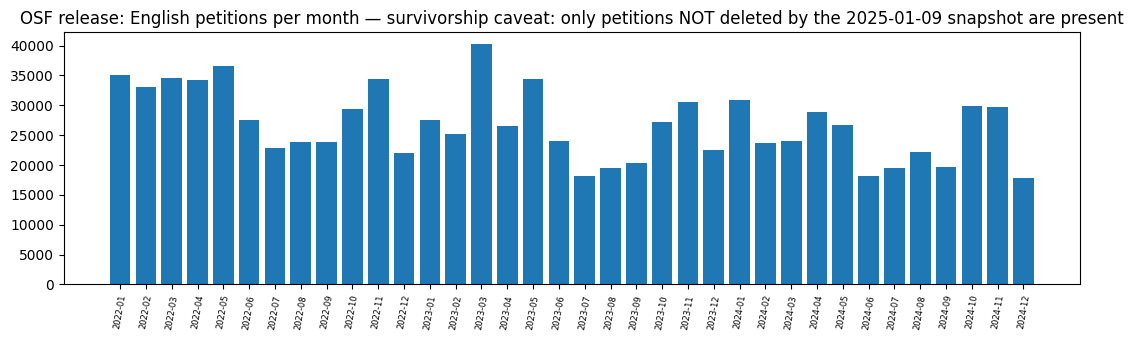

  monthly volume figure                          saved          a rising ramp can be growth AND/OR deletion attrition of older petitions — treat early-2022 composition with care

saved -> TAB_V6_osf_audit.csv, TAB_V6_osf_countries.csv, FIG_V6_osf_volume.png


In [17]:
#@title 2.13b · OSF release RELIABILITY & DUPLICATION AUDIT — run before trusting the data (Bias 26)
# Answers, with computed numbers (not assumptions): (a) are petition_ids unique within and
# consistent across files? (b) is 1.5M-metadata vs ~965k-text a DUPLICATION problem or simply
# the English subset? (c) do createdAt values agree across files? (d) how many exact-duplicate
# texts exist? (e) which COUNTRIES are represented, per era? (f) does monthly volume show the
# deletion-survivorship footprint (data = petitions NOT deleted as of the 2025-01-09 snapshot,
# per the paper's Methods — early petitions had ~3 years of deletion exposure, late ones days)?
import gc as _gc, hashlib, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

CHG_DIR = RAW / 'external' / 'changeorg_osf'
PAPER_TOTAL = 1_517_433          # arXiv:2511.13949, Materials & Methods

def _cn(c): return str(c).strip().lower().replace('_', '').replace(' ', '')
def _pid(v):
    t = str(v).strip()
    return t[:-2] if t.endswith('.0') else t

rows = []
def note(metric, value, comment=''):
    rows.append({'metric': metric, 'value': value, 'comment': comment})
    print(f'  {metric:<46s} {value!s:<14s} {comment}')

if not CHG_DIR.exists() or not list(CHG_DIR.glob('*.csv')):
    print(f'[2.13b] no CSVs in {CHG_DIR} — download the OSF files first (see 2.13).')
else:
    files = sorted(CHG_DIR.glob('*.csv'))
    role = {}
    for f in files:
        try:
            cols = list(pd.read_csv(f, nrows=0).columns)
        except Exception:
            continue
        cn = {_cn(c) for c in cols}
        if 'petitionid' not in cn: role[f] = 'other'
        elif 'fulltext' in cn: role[f] = 'text_titled'
        elif 'text' in cn and len(cols) <= 4: role[f] = 'text_original'
        elif 'createdat' in cn and 'usercountrycode' in cn: role[f] = 'labeled'
        elif 'createdat' in cn: role[f] = 'metadata'
        elif 'label' in cn: role[f] = 'topic_label'
        else: role[f] = 'other'
    print('[2.13b] file roles:')
    for f, r in role.items(): print(f'  {r:<14s} {f.name}')

    def id_set(f, extra_cols=()):
        cols = list(pd.read_csv(f, nrows=0).columns)
        cid = next(c for c in cols if _cn(c) == 'petitionid')
        use = [cid] + [c for c in cols if _cn(c) in extra_cols]
        s, n = set(), 0
        out_extra = {}
        for ch in pd.read_csv(f, usecols=use, chunksize=200_000, dtype={cid: str}, low_memory=False):
            pids = ch[cid].map(_pid); n += len(ch); s.update(pids)
            for c in use[1:]:
                out_extra.setdefault(c, {}).update(zip(pids, ch[c]))
        return s, n, out_extra

    print('\n=== (a) ID uniqueness within each file ===')
    ids = {}
    for f, r in role.items():
        if r in ('text_titled', 'text_original', 'labeled', 'metadata', 'topic_label'):
            s, n, _ = id_set(f)
            ids[f] = s
            note(f'{r}: {f.name[:34]}', f'{n:,} rows', f'{len(s):,} unique ids'
                 + ('  <-- DUPLICATE ROWS' if len(s) < n else ''))

    meta_files = [f for f, r in role.items() if r == 'metadata']
    # deep checks on the 3 'all_collected_petition_ids' files specifically
    if meta_files:
        uid_of, uid_conflicts, fullrow_dupes, n_rows_meta = {}, 0, 0, 0
        seen_rows = set()
        for f in meta_files:
            cols = list(pd.read_csv(f, nrows=0).columns)
            cid = next(c for c in cols if _cn(c) == 'petitionid')
            cui = next((c for c in cols if _cn(c) == 'userid'), None)
            cdt = next((c for c in cols if _cn(c) == 'createdat'), None)
            for ch in pd.read_csv(f, usecols=[c for c in (cid, cui, cdt) if c],
                                  chunksize=300_000, dtype=str, low_memory=False):
                n_rows_meta += len(ch)
                for pid_, uid_, dt_ in zip(ch[cid].map(_pid),
                                           ch[cui] if cui else [''] * len(ch),
                                           ch[cdt] if cdt else [''] * len(ch)):
                    key = (pid_, str(uid_), str(dt_))
                    if key in seen_rows:
                        fullrow_dupes += 1
                    seen_rows.add(key)
                    prev = uid_of.get(pid_)
                    if prev is None:
                        uid_of[pid_] = str(uid_)
                    elif prev != str(uid_):
                        uid_conflicts += 1
        note('id-files: exact full-row duplicates across the 3 files', f'{fullrow_dupes:,}',
             'same (petition_id,user_id,createdAt) appearing twice')
        note('id-files: same petition_id with DIFFERENT user_id', f'{uid_conflicts:,}',
             'should be 0 — nonzero would be a data inconsistency')
        del seen_rows
    text_files = [f for f, r in role.items() if r in ('text_titled', 'text_original')]
    lab_files  = [f for f, r in role.items() if r == 'labeled']
    print('\n=== (b) cross-file reconciliation: 1.5M metadata vs ~965k text ===')
    if meta_files:
        meta_union = set().union(*[ids[f] for f in meta_files])
        n_rows_meta = sum(len(ids[f]) for f in meta_files)
        overlap_meta = n_rows_meta - len(meta_union)
        note('metadata files: total ids across the 3', f'{n_rows_meta:,}', '')
        note('metadata union (distinct ids)', f'{len(meta_union):,}', '')
        if overlap_meta == 0:
            verdict = 'VERDICT: a clean 3-way SPLIT — no duplicates across the id files'
        else:
            verdict = (f'VERDICT: {overlap_meta:,} ids appear in more than one file — '
                       'overlapping dumps; the ingest deduplicates by petition_id')
        note('ids shared between files', f'{overlap_meta:,}', verdict)
        note('vs paper N = 1,517,433', f'{len(meta_union) - PAPER_TOTAL:+,}', 'difference')
    if text_files:
        tset = set().union(*[ids[f] for f in text_files])
        note('text ids', f'{len(tset):,}',
             'the ~965k file is the ENGLISH subset, not a deduplicated 1.5M')
        if meta_files:
            note('text ids missing from metadata union', f'{len(tset - meta_union):,}',
                 'should be ~0')
        if lab_files:
            lset = set().union(*[ids[f] for f in lab_files])
            note('text ids missing from labeled file', f'{len(tset - lset):,}', 'should be ~0')
        if meta_files:
            rem = len(meta_union - tset)
            note('ids in metadata union but NOT in text', f'{rem:,}',
                 'these are the non-English (and any withheld) petitions -> ~1.5M − ~965k, '
                 'NOT duplicates; verify: this number + text ids ≈ metadata union')
        if len(text_files) == 2:
            a, b = [ids[f] for f in text_files]
            note('titled-text vs original-text id overlap', f'{len(a & b):,}',
                 'expect = both files (same petitions, two text forms)')

    print('\n=== (c) createdAt agreement across files (sampled) ===')
    date_maps = []
    for f in (lab_files + meta_files)[:4]:
        cols = list(pd.read_csv(f, nrows=0).columns)
        cid = next(c for c in cols if _cn(c) == 'petitionid')
        cdt = next((c for c in cols if _cn(c) == 'createdat'), None)
        if not cdt: continue
        m = {}
        for ch in pd.read_csv(f, usecols=[cid, cdt], chunksize=300_000, dtype={cid: str}):
            m.update(zip(ch[cid].map(_pid), pd.to_datetime(ch[cdt], errors='coerce', utc=True)))
        date_maps.append((f.name, m))
    for i in range(len(date_maps)):
        for j in range(i + 1, len(date_maps)):
            (na, ma), (nb, mb) = date_maps[i], date_maps[j]
            common = list(set(ma) & set(mb))[:50_000]
            if len(common) < 100:
                continue
            diffs = np.array([(ma[p] - mb[p]).days for p in common
                              if pd.notna(ma[p]) and pd.notna(mb[p])])
            note(f'createdAt |diff|>1d: {na[:16]} vs {nb[:16]}',
                 f'{int((np.abs(diffs) > 1).sum()):,} / {len(diffs):,}', 'sampled common ids')

    # user_id agreement between the id files and the labeled file (sampled)
    uid_maps = []
    for f in (lab_files + meta_files)[:4]:
        cols = list(pd.read_csv(f, nrows=0).columns)
        cid = next(c for c in cols if _cn(c) == 'petitionid')
        cu = next((c for c in cols if _cn(c) == 'userid'), None)
        if not cu:
            continue
        m = {}
        for ch in pd.read_csv(f, usecols=[cid, cu], chunksize=300_000, dtype=str):
            m.update(zip(ch[cid].map(_pid), ch[cu].map(_pid)))
        uid_maps.append((f.name, m))
    for i in range(len(uid_maps)):
        for j in range(i + 1, len(uid_maps)):
            (na, ma), (nb, mb) = uid_maps[i], uid_maps[j]
            common = list(set(ma) & set(mb))[:50_000]
            if len(common) < 100:
                continue
            mism = sum(1 for p_ in common if ma[p_] != mb[p_])
            note(f'user_id mismatches: {na[:16]} vs {nb[:16]}',
                 f'{mism:,} / {len(common):,}', 'sampled common ids (should be ~0)')

    print('\n=== (d) exact-duplicate TEXTS (near-dups are handled later by 11.3 MinHash) ===')
    orig = [f for f, r in role.items() if r == 'text_original'] or \
           [f for f, r in role.items() if r == 'text_titled']
    if orig:
        f = orig[0]; cols = list(pd.read_csv(f, nrows=0).columns)
        cid = next(c for c in cols if _cn(c) == 'petitionid')
        ctx = next(c for c in cols if _cn(c) in ('text', 'fulltext'))
        seen, dup_docs, n_docs = {}, 0, 0
        for ch in tqdm(pd.read_csv(f, usecols=[cid, ctx], chunksize=100_000,
                                   dtype={cid: str}, low_memory=False),
                       desc='hashing texts', leave=False):
            for t in ch[ctx].fillna(''):
                n_docs += 1
                h = hashlib.md5(re.sub(r'\s+', ' ', t.lower()).strip().encode()).hexdigest()
                c = seen.get(h, 0)
                if c == 1: dup_docs += 2
                elif c > 1: dup_docs += 1
                seen[h] = c + 1
        note('docs in exact-duplicate clusters', f'{dup_docs:,}',
             f'{dup_docs / max(n_docs, 1):.2%} of {n_docs:,} '
             '(dup_weight in 11.3 downweights them; templates are data, not errors)')
        del seen; _gc.collect()

    print('\n=== (e) countries per era + (f) monthly volume (survivorship footprint) ===')
    if lab_files:
        f = lab_files[0]; cols = list(pd.read_csv(f, nrows=0).columns)
        cid = next(c for c in cols if _cn(c) == 'petitionid')
        cdt = next(c for c in cols if _cn(c) == 'createdat')
        ccc = next((c for c in cols if _cn(c) == 'usercountrycode'), None)
        recs = []
        for ch in pd.read_csv(f, usecols=[c for c in (cid, cdt, ccc) if c],
                              chunksize=300_000, low_memory=False):
            d = pd.to_datetime(ch[cdt], errors='coerce', utc=True).dt.tz_localize(None)
            recs.append(pd.DataFrame({'m': d.dt.to_period('M').astype(str),
                                      'post': d >= pd.Timestamp(CUTOVER),
                                      'cc': ch[ccc].astype(str) if ccc else ''}))
        lab = pd.concat(recs); del recs
        ct = (lab.groupby(['cc', 'post']).size().unstack(fill_value=0)
                 .rename(columns={False: 'pre', True: 'post'})
                 .sort_values('post', ascending=False))
        ct.to_csv(OUT / 'TAB_V6_osf_countries.csv')
        print(ct.head(20).to_string())
        note('countries with >=1000 post-era petitions', f'{int((ct["post"] >= 1000).sum()):,}',
             'full table -> TAB_V6_osf_countries.csv (yes — per-petition country EXISTS)')
        vol = lab.groupby('m').size().sort_index()
        fig, ax = plt.subplots(figsize=(11, 3.5))
        ax.bar(vol.index, vol.values, width=0.8)
        ax.tick_params(axis='x', rotation=80, labelsize=6)
        ax.set_title('OSF release: English petitions per month — survivorship caveat: only petitions '
                     'NOT deleted by the 2025-01-09 snapshot are present')
        plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_osf_volume.png', dpi=160); plt.show()
        note('monthly volume figure', 'saved', 'a rising ramp can be growth AND/OR deletion attrition '
             'of older petitions — treat early-2022 composition with care')
    pd.DataFrame(rows).to_csv(OUT / 'TAB_V6_osf_audit.csv', index=False)
    print('\nsaved -> TAB_V6_osf_audit.csv, TAB_V6_osf_countries.csv, FIG_V6_osf_volume.png')


In [18]:
#@title 2.14 · Wayback CDX recovery — Senedd (Wales) pre-2022 archive [SENSITIVITY SOURCE ONLY]
# The current Senedd platform is post-only in our corpus; the pre-2022 National Assembly for
# Wales petition pages survive in the Internet Archive. CDX-recovered sources carry archive
# sampling bias (Bias 16 in the V6 audit) -> tagged 'senedd_archive' and used ONLY for
# sensitivity checks, never in headline estimates. Dates come from the page itself; pages
# without an on-page date go to the _undated salvage file (repairable via 2.9), never guessed
# from the snapshot timestamp.
from bs4 import BeautifulSoup

CDX_ENABLE   = False  #@param {type:"boolean"}
CDX_TARGETS  = [dict(tag='senedd_archive', country='GB', lang='en',
                     prefixes=['petitions.assembly.wales/', 'www.assembly.wales/en/gethome/e-petitions/'],
                     to_ts='20221101')]
CDX_PAGE_CAP = 1500

def cdx_list(prefix, to_ts):
    try:
        r = SESSION.get('http://web.archive.org/cdx/search/cdx',
                        params=dict(url=prefix, matchType='prefix', output='json',
                                    filter='statuscode:200', collapse='urlkey', to=to_ts,
                                    fl='timestamp,original', limit=20000), timeout=120)
        r.raise_for_status(); time.sleep(REQUEST_DELAY)
        rows = r.json()
        return [(ts, orig) for ts, orig in rows[1:]] if rows else []
    except Exception as e:
        print(f'[cdx] listing failed for {prefix}: {type(e).__name__}: {e}')
        return []

def cdx_fetch_page(ts, orig):
    r = SESSION.get(f'https://web.archive.org/web/{ts}id_/{orig}', timeout=120)
    r.raise_for_status(); time.sleep(REQUEST_DELAY)
    return r.text

def parse_petition_page(html):
    soup = BeautifulSoup(html, 'html.parser')
    h1 = soup.find('h1')
    title = h1.get_text(' ', strip=True) if h1 else None
    main = soup.select_one('main, #main, .main-content, article') or soup
    paras = [p.get_text(' ', strip=True) for p in main.find_all('p')]
    text = ' '.join(p for p in paras if len(p.split()) >= 6)[:20000]
    date = None
    t = soup.select_one('time[datetime]')
    if t and t.get('datetime'):
        date = t['datetime']
    else:
        m = re.search(r'\b(\d{1,2} (January|February|March|April|May|June|July|August|'
                      r'September|October|November|December) 20[12]\d)\b', main.get_text(' ', strip=True))
        if m:
            date = m.group(1)
    return title, text, date

if CDX_ENABLE:
    for tgt in CDX_TARGETS:
        out_path, und_path = RAW / f"{tgt['tag']}.jsonl.gz", RAW / f"_undated_{tgt['tag']}.jsonl.gz"
        marker = RAW / f"_done_{tgt['tag']}.txt"
        if marker.exists() and out_path.exists():
            print(f"[{tgt['tag']}] COMPLETE ({marker.read_text().strip()}) — delete the marker to re-crawl.")
            continue
        seen = ({r['id'] for r in load_jsonl(out_path)} |
                {r['id'] for r in load_jsonl(und_path)})
        snaps = []
        for pref in tgt['prefixes']:
            snaps += cdx_list(pref, tgt['to_ts'])
        snaps = [(ts, o) for ts, o in snaps
                 if re.search(r'petition', o, re.I) and not re.search(r'\.(css|js|png|jpg|pdf|ico)(\?|$)', o, re.I)]
        print(f"[{tgt['tag']}] {len(snaps)} candidate archived pages")
        n_ok = n_und = 0
        for ts, orig in snaps[:CDX_PAGE_CAP]:
            pid = re.sub(r'^https?://', '', orig).rstrip('/')
            if pid in seen:
                continue
            try:
                title, text, date = parse_petition_page(cdx_fetch_page(ts, orig))
            except Exception:
                continue
            if not title or len(text.split()) < 20:
                continue
            rec = {'id': pid, 'title': title, 'text': text, 'created_at': date,
                   'snapshot_ts': ts, 'country_hint': tgt['country'],
                   'lang_hint': tgt['lang'], '_source': tgt['tag']}
            if date:
                dump_jsonl([rec], out_path); n_ok += 1
            else:
                dump_jsonl([rec], und_path); n_und += 1
            seen.add(pid)
        marker.write_text(f'{n_ok} dated + {n_und} undated, crawl {datetime.datetime.now():%Y-%m-%d %H:%M}')
        print(f"[{tgt['tag']}] recovered {n_ok} dated + {n_und} undated (repair via 2.9). "
              f'SENSITIVITY-ONLY source — excluded from headline estimates by the V6 analysis cells.')
else:
    print('[cdx] disabled (CDX_ENABLE=False). Enable to recover the pre-2022 Welsh archive — '
          'slow, and the result is a sensitivity-only source (Bias 16).')


[cdx] disabled (CDX_ENABLE=False). Enable to recover the pre-2022 Welsh archive — slow, and the result is a sensitivity-only source (Bias 16).


In [19]:
#@title 2.15 · Denominators — internet adoption & population per country-year (World Bank open API, no key) → raw/external/wb_denominators.csv
# The rival explanation "signatures rose because more people are online" needs a DENOMINATOR,
# not an assertion. This pulls two official series for every study country:
#   IT.NET.USER.ZS — individuals using the Internet (% of population)
#   SP.POP.TOTL    — total population
# Free, keyless, stable JSON API. Taiwan is absent from World Bank data (noted in the output);
# 11.11b uses corpus-internal platform-activity denominators there instead.
import json, time
import pandas as pd
import requests

WB_ISO3   = ['GBR', 'CAN', 'DEU', 'FIN', 'KOR', 'USA', 'IRL', 'AUT', 'CHE']
WB_INDIC  = {'IT.NET.USER.ZS': 'internet_pct', 'SP.POP.TOTL': 'population'}
WB_YEARS  = '2008:2026'
ISO3_TO_CORPUS = {'GBR': ['gb', 'uk'], 'CAN': ['ca'], 'DEU': ['de'], 'FIN': ['fi'],
                  'KOR': ['kr'], 'USA': ['us'], 'IRL': ['ie'], 'AUT': ['at'], 'CHE': ['ch']}

out_path = RAW / 'external' / 'wb_denominators.csv'
out_path.parent.mkdir(parents=True, exist_ok=True)

def wb_fetch(indicator, tries=4):
    url = (f'https://api.worldbank.org/v2/country/{";".join(WB_ISO3)}/indicator/{indicator}'
           f'?format=json&per_page=2000&date={WB_YEARS}')
    for a in range(tries):
        try:
            r = requests.get(url, timeout=60, headers={'User-Agent': 'petition-style-research/1.0'})
            r.raise_for_status()
            js = r.json()
            if not (isinstance(js, list) and len(js) > 1 and js[1]):
                raise ValueError(f'unexpected payload: {str(js)[:200]}')
            return [{'iso3': row['countryiso3code'], 'year': int(row['date']),
                     'value': row['value']} for row in js[1] if row.get('value') is not None]
        except Exception as e:
            print(f'  [{indicator}] attempt {a + 1}/{tries} failed: {e}')
            time.sleep(3 * (a + 1))
    return None

frames = []
for ind, col in WB_INDIC.items():
    rows = wb_fetch(ind)
    if rows is None:
        print(f'FAILED to fetch {ind}. Manual fallback: download the CSV from')
        print(f'  https://data.worldbank.org/indicator/{ind}  and place a long-format file')
        print(f'  with columns iso3,year,{col} at {out_path} — 11.11b will pick it up.')
        frames = []
        break
    frames.append(pd.DataFrame(rows).rename(columns={'value': col}))

if frames:
    wb = frames[0].merge(frames[1], on=['iso3', 'year'], how='outer')
    wb['internet_users'] = wb['internet_pct'] / 100 * wb['population']
    wb['corpus_countries'] = wb['iso3'].map(lambda i: '|'.join(ISO3_TO_CORPUS.get(i, [])))
    # forward-fill the newest 1-2 missing years per country (WB lags ~18 months) and mark it
    wb = wb.sort_values(['iso3', 'year'])
    for c in ('internet_pct', 'population', 'internet_users'):
        filled = wb.groupby('iso3')[c].transform(lambda s: s.ffill())
        wb[c + '_ffilled'] = wb[c].isna() & filled.notna()
        wb[c] = filled
    wb.to_csv(out_path, index=False)
    print(f'\nwritten -> {out_path}  ({len(wb)} country-years)')
    print(wb.groupby('iso3')['year'].agg(['min', 'max', 'count']).to_string())
    print('\nNOTE: Taiwan (tw) is not in World Bank data — 11.11b falls back to corpus-internal')
    print('platform-activity denominators for tw_join, and says so in its output.')
else:
    print('\nwb_denominators.csv not written — 11.11b will run with corpus-internal denominators only.')



written -> /content/drive/MyDrive/petition_llm_project/raw/external/wb_denominators.csv  (162 country-years)
       min   max  count
iso3                   
AUT   2008  2025     18
CAN   2008  2025     18
CHE   2008  2025     18
DEU   2008  2025     18
FIN   2008  2025     18
GBR   2008  2025     18
IRL   2008  2025     18
KOR   2008  2025     18
USA   2008  2025     18

NOTE: Taiwan (tw) is not in World Bank data — 11.11b falls back to corpus-internal
platform-activity denominators for tw_join, and says so in its output.


## 3 · Corpus unification & cleaning
Per-language length thresholds, loud drop diagnostics, atomic parquet writes, censoring fields, and a **no-fabrication assert** (synthetic calibration data can never enter the corpus).

In [20]:
#@title 3 · Build the unified corpus → clean/corpus.parquet (atomic + verified)
import pandas as pd, numpy as np
from langdetect import detect, DetectorFactory
from tqdm.auto import tqdm
DetectorFactory.seed = 0
tqdm.pandas()

SOURCE_COUNTRY = {'uk_2010':'GB','uk_2015':'GB','uk_2017':'GB','uk_2019':'GB','uk_current':'GB',
                  'canada':'CA','wtp':'US','bluehouse':'KR','kr_assembly':'KR',
                  'openpetition':'DE','changeorg':None}
SOURCE_LANG_HINT = {'bluehouse':'ko','kr_assembly':'ko','openpetition':'de'}

rows = []
for f in sorted(RAW.glob('*.jsonl.gz')):
    if f.name.startswith('_undated_'):
        continue  # kept for repair, not analysis (no date -> no temporal placement)
    recs = load_jsonl(f)
    print(f'{f.name}: {len(recs)}')
    rows.extend(recs)
df = pd.DataFrame(rows)
if df.empty:
    raise SystemExit('No raw data yet — run Section 2 first.')

# --- NO-FABRICATION GUARD: nothing synthetic may enter the research corpus ---
assert not df['_source'].astype(str).str.contains('synth|calib|generated', case=False).any(), \
    'Synthetic/calibration rows found in raw/ — they belong in calibration/ only. Aborting.'

df['source'] = df['_source']
df['country'] = df.apply(lambda r: r.get('country_hint') or SOURCE_COUNTRY.get(r['source']), axis=1)
df['pid'] = df['source'] + ':' + df['id'].astype(str)

def parse_date(v):
    if pd.isna(v):
        return pd.NaT
    if isinstance(v, (int, float)) or (isinstance(v, str) and str(v).isdigit()):
        v = int(v)
        unit = 'ms' if v > 10_000_000_000 else 's'
        return pd.to_datetime(v, unit=unit, errors='coerce')
    if isinstance(v, str):
        d = pd.to_datetime(v, errors='coerce', utc=True)
        return d.tz_localize(None) if d is not pd.NaT and d.tzinfo else d
    return pd.NaT
for col in ['created_at', 'opened_at', 'closed_at', 'rejected_at']:
    if col in df.columns:
        df[col.replace('_at', '')] = df[col].map(parse_date)
    else:
        df[col.replace('_at', '')] = pd.NaT
df = df.rename(columns={'created': 'created'})

def clean_text(t):
    t = str(t or '')
    t = re.sub(r'https?://\S+', ' ', t)
    t = re.sub(r'<[^>]+>', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()
df['title'] = df['title'].map(clean_text)
df['text'] = df['text'].map(clean_text)
df['full'] = (df['title'] + '. ' + df['text']).str.strip()
df['n_words'] = df['full'].str.split().str.len()
df['n_chars'] = df['full'].str.len()

# --- language detection BEFORE length filtering (the filter is per-language) ---
# v5.1 FIX: the old code did `row.get('lang_hint') or fallback`, but NaN is TRUTHY in
# Python, so every UK/Blue House row silently got lang=NaN: langdetect never ran, the
# per-language length filter fell back to the English rule (killing 113,936 Korean rows
# again), and Section 4.5a crashed on an empty English subset. Now vectorized + asserted.
hint = df['lang_hint'] if 'lang_hint' in df.columns else pd.Series(pd.NA, index=df.index)
hint = hint.where(hint.notna() & (hint.astype(str) != ''), df['source'].map(SOURCE_LANG_HINT))
df['lang'] = hint
need = df['lang'].isna()

# v5.2 RERUN-SAFETY: persistent per-document language cache — on reruns, langdetect only
# processes documents it has never seen (10-15 min saved on every Section 3 rebuild).
LANG_CACHE = CLEAN / 'lang_cache.parquet'
if LANG_CACHE.exists() and valid_parquet(LANG_CACHE):
    lc = pd.read_parquet(LANG_CACHE)
    df.loc[need, 'lang'] = df.loc[need, 'pid'].map(dict(zip(lc['pid'], lc['lang'])))
    need = df['lang'].isna()
    print(f'language cache: {len(lc):,} entries loaded')
print(f'language: {(~need).sum():,} rows hinted/cached, {need.sum():,} to detect...')
def detect_safe(t):
    try:
        return detect(t[:1000])
    except Exception:
        return 'unk'
detected_mask = need.copy()
df.loc[need, 'lang'] = df.loc[need, 'full'].progress_apply(detect_safe)
assert df['lang'].notna().all(), 'internal error: rows left without a language label'
if detected_mask.any():
    new_lc = df.loc[detected_mask, ['pid', 'lang']]
    old_lc = pd.read_parquet(LANG_CACHE) if LANG_CACHE.exists() and valid_parquet(LANG_CACHE) else None
    atomic_parquet(pd.concat([old_lc, new_lc]).drop_duplicates('pid') if old_lc is not None else new_lc,
                   LANG_CACHE)
print('language distribution (top 10):')
print(df['lang'].value_counts().head(10).to_string())

# --- filters, LOUD ---
before = len(df)
no_date = df[df['created'].isna()]
if len(no_date):
    print('!! rows DROPPED for missing/unparseable date, by source:')
    print(no_date.groupby('source').size().to_string())
df = df[df['created'].notna() & df['created'].between(PRE_START, END_DATE)]

# FIX: per-language minimum length
def long_enough(row):
    mode, thr = MIN_LEN.get(row['lang'], MIN_LEN['default'])
    return (row['n_chars'] if mode == 'chars' else row['n_words']) >= thr
keep_mask = df.apply(long_enough, axis=1)
short = df[~keep_mask]
if len(short):
    print('!! rows DROPPED as too short (per-language thresholds), by source:')
    print(short.groupby('source').size().to_string())
df = df[keep_mask]

df['signatures'] = pd.to_numeric(df['signatures'], errors='coerce')
df = df.drop_duplicates(subset=['source', 'full'])
print(f'Filtered {before} -> {len(df)}')

df['year'] = df['created'].dt.year
df['quarter'] = df['created'].dt.to_period('Q').astype(str)
df['post_llm'] = df['created'] >= pd.Timestamp(CUTOVER)
df['state'] = df['state'].astype(str).str.lower().replace('nan', None)
# FIX: censoring — exposure window for signature models
close_proxy = df['closed'].fillna(df['rejected']).fillna(pd.Timestamp(END_DATE))
open_proxy = df['opened'].fillna(df['created'])
df['days_open'] = (close_proxy - open_proxy).dt.days.clip(lower=1)
df['is_open'] = (df['state'] == 'open') | (df['closed'].isna() & (df['source'] == 'uk_current') & (df['state'] != 'rejected'))

keep = ['pid','source','country','lang','title','full','created','opened','closed','rejected',
        'rejection_code','rejection_details','year','quarter','post_llm','signatures',
        'n_words','n_chars','days_open','is_open','topic_hint','state']
df = df[[c for c in keep if c in df.columns]].reset_index(drop=True)
atomic_parquet(df, CLEAN / 'corpus.parquet')
print(df.groupby(['source','post_llm']).size().unstack(fill_value=0))
print('\nSanity: post-2022 docs by language:')
print(df[df.post_llm].groupby('lang').size().sort_values(ascending=False).head(10).to_string())

bluehouse.jsonl.gz: 451513
canada.jsonl.gz: 2044
changeorg_au.jsonl.gz: 39803
changeorg_other.jsonl.gz: 280901
changeorg_treated.jsonl.gz: 643932
roi_ru.jsonl.gz: 225
scotland.jsonl.gz: 411
uk_2010.jsonl.gz: 53653
uk_2015.jsonl.gz: 28285
uk_2017.jsonl.gz: 24890
uk_2019.jsonl.gz: 46115
uk_current.jsonl.gz: 14789
language cache: 169,776 entries loaded
language: 1,586,561 rows hinted/cached, 0 to detect...


0it [00:00, ?it/s]

language distribution (top 10):
lang
en    1134709
ko     451513
ru        226
de         30
fr         10
af         10
tl          7
nl          6
ca          6
so          5
!! rows DROPPED as too short (per-language thresholds), by source:
source
bluehouse             42854
canada                   39
changeorg_au           7052
changeorg_other       66131
changeorg_treated    111627
uk_2010                4614
uk_2015                1246
uk_2017                1107
uk_2019                1185
uk_current              393
Filtered 1586561 -> 1333317
[atomic] wrote corpus.parquet  (1107.3 MB, 1,333,317 rows)
post_llm            False   True 
source                           
bluehouse          398935       0
canada               1533     472
changeorg_au        10488   22112
changeorg_other     63142  147446
changeorg_treated  172760  357105
roi_ru                119     101
scotland               65     339
uk_2010             48740       0
uk_2015             26986       0
uk_2017 

## 4 · Measuring "LLM style" — four independent signals
1. curated lexical markers (per language), 2. stylometrics, 3. GPT-2 perplexity **+ Fast-DetectGPT curvature**, 4. Kobak-style excess vocabulary (data-discovered).
Plus **placebo markers** — common words LLMs do *not* overuse; they must show no 2022 break, or the design is broken.
Framing discipline: per-document scores are noisy indices; claims are population-level.

In [21]:
#@title 4.1 · Marker dictionaries + placebo markers + per-document scores
import numpy as np, pandas as pd
from tqdm.auto import tqdm

df = read_parquet_checked(CLEAN / 'corpus.parquet')

MARKERS = {
 'en': {
  'delve': r"\bdelv(e|es|ed|ing)\b", 'moreover': r"\bmoreover\b", 'furthermore': r"\bfurthermore\b",
  'additionally': r"\badditionally\b", 'crucial': r"\bcrucial\b", 'pivotal': r"\bpivotal\b",
  'foster': r"\bfoster(s|ing|ed)?\b", 'landscape_fig': r"\b(digital|evolving|changing|modern) landscape\b",
  'tapestry': r"\btapestry\b", 'testament_to': r"\btestament to\b", 'underscore': r"\bunderscor(e|es|ed|ing)\b",
  'leverage': r"\bleverag(e|es|ed|ing)\b", 'robust': r"\brobust\b", 'holistic': r"\bholistic\b",
  'imperative': r"\bimperative\b", 'important_to_note': r"\bit( i|')s (important|worth) (to note|noting)\b",
  'in_conclusion': r"\bin conclusion\b",
  'in_todays': r"\bin today'?s (fast-paced|rapidly (changing|evolving)|modern|digital)\b",
  'not_only_but_also': r"\bnot only\b.{1,80}\bbut also\b",
  'plays_role': r"\bplays? a (crucial|vital|pivotal|key) role\b",
  'ensure_that': r"\bensur(e|es|ing) that\b", 'stakeholders': r"\bstakeholders?\b",
  'navigate_fig': r"\bnavigat(e|ing) (the|these|this) (challenges|complexities|landscape)\b",
  'commendable': r"\bcommendable\b", 'meticulous': r"\bmeticulous(ly)?\b", 'realm': r"\brealm\b",
  'paradigm': r"\bparadigm\b", 'harness': r"\bharness(es|ed|ing)?\b", 'urge_the': r"\bwe (respectfully )?urge\b",
 },
 'de': {
  'zudem': r"\bzudem\b", 'daruber_hinaus': r"\bdarüber hinaus\b", 'entscheidend': r"\bentscheidend(e|er|en)?\b",
  'essenziell': r"\bessenziell(e|er)?\b", 'wichtig_zu_betonen': r"\bwichtig zu (betonen|beachten)\b",
  'nachhaltig': r"\bnachhaltig(e|en|er)?\b", 'gewahrleisten': r"\bgewährleisten\b",
  'im_digitalen_zeitalter': r"\bim digitalen zeitalter\b",
  'spielt_rolle': r"\bspielt eine (entscheidende|zentrale|wichtige) rolle\b",
  'nicht_nur_sondern': r"\bnicht nur\b.{1,80}\bsondern auch\b", 'foerdern': r"\bfördern\b",
 },
 'fr': {
  'important_de_noter': r"\bil est (important|essentiel) de (noter|souligner)\b", 'de_plus': r"\bde plus\b",
  'en_outre': r"\ben outre\b", 'par_ailleurs': r"\bpar ailleurs\b", 'crucial': r"\bcrucia(l|le|ux|les)\b",
  'joue_role': r"\bjoue un rôle (crucial|essentiel|clé|majeur)\b",
  'monde_evolution': r"\bdans un monde (en constante évolution|de plus en plus)\b",
  'non_seulement': r"\bnon seulement\b.{1,80}\bmais (aussi|également)\b",
  'garantir': r"\bgarantir\b", 'renforcer': r"\brenforcer\b", 'favoriser': r"\bfavoriser\b",
 },
 'es': {
  'importante_destacar': r"\bes (importante|fundamental) (destacar|señalar|mencionar)\b",
  'ademas': r"\bademás\b", 'asimismo': r"\basimismo\b", 'cabe_destacar': r"\bcabe (destacar|señalar)\b",
  'crucial': r"\bcrucial(es)?\b", 'desempena_papel': r"\bdesempeña un papel (crucial|fundamental|clave)\b",
  'mundo_cambiante': r"\ben un mundo (cada vez más|en constante)\b",
  'no_solo': r"\bno so?lo\b.{1,80}\bsino también\b", 'garantizar': r"\bgarantizar\b", 'fomentar': r"\bfomentar\b",
 },
 'pt': {
  'importante_ressaltar': r"\bé (importante|fundamental) (ressaltar|destacar|salientar)\b",
  'alem_disso': r"\balém disso\b", 'ademais': r"\bademais\b", 'crucial': r"\bcrucia(l|is)\b",
  'papel_fundamental': r"\bdesempenha um papel (crucial|fundamental|essencial)\b",
  'nao_apenas': r"\bnão (apenas|só)\b.{1,80}\bmas também\b", 'garantir': r"\bgarantir\b", 'promover': r"\bpromover\b",
 },
 'he': {
  'chashuv_letzayen': r"חשוב לציין", 'yeter_al_ken': r"יתרה מזאת|יתר על כן", 'zot_veod': r"זאת ועוד",
  'kriti': r"קריטי(ת|ים|ות)?", 'mashmauti': r"משמעותי(ת|ים|ות)?",
  'tafkid_merkazi': r"תפקיד (מרכזי|מכריע|חיוני)", 'lo_rak': r"לא רק.{1,80}אלא (גם|אף)",
  'lehavtiach': r"להבטיח", 'lekadem': r"לקדם",
 },
 'ru': {
  'vazhno_otmetit': r"важно отметить", 'krome_togo': r"кроме того", 'bolee_togo': r"более того",
  'klyuchevuyu_rol': r"(ключевую|важную|решающую) роль", 'ne_tolko': r"не только.{1,80}но и",
  'obespechit': r"обеспеч(ить|ивает)", 'sposobstvovat': r"способствовать",
 },
 'uk': {
  'varto_zaznachyty': r"варто зазначити", 'krim_toho': r"крім того", 'bilshe_toho': r"більше того",
  'vazhlyvu_rol': r"(важливу|ключову|вирішальну) роль", 'ne_lyshe': r"не (лише|тільки).{1,80}(а й|але й)",
  'zabezpechyty': r"забезпеч(ити|ує)",
 },
 'ko': {
  'jungyo_yokhal': r"(중요한|핵심적인) 역할", 'ttohan': r"또한", 'ppunman_anira': r"뿐만 아니라",
  'bojang': r"보장", 'pilsu': r"필수적", 'ganghwa': r"강화",
 },
}
# FIX: placebo set — high-frequency words with no documented LLM excess.
# If these break at 2022-Q4 too, the "LLM effect" is confounded (topic/composition shift).
PLACEBO_EN = {'people': r"\bpeople\b", 'government': r"\bgovernment\b", 'children': r"\bchildren\b",
              'school': r"\bschools?\b", 'money': r"\bmoney\b", 'country': r"\bcountry\b",
              'local': r"\blocal\b", 'help': r"\bhelp\b", 'stop': r"\bstop\b", 'need': r"\bneeds?\b"}

STRUCT = {'em_dash': r"—", 'bold_md': r"\*\*[^*]+\*\*", 'numbered_list': r"(?m)^\s*\d+[.)]\s",
          'bullet_list': r"(?m)^\s*[-•*]\s", 'colon_header': r"(?m)^\S[^\n]{2,40}:\s",
          'emoji': r"[\U0001F300-\U0001FAFF\u2705\u26A0\u2757]"}

# v5.3 FIX: these dicts were named C / C_PL / C_ST. `C(...)` is also patsy's categorical
# operator inside every statsmodels formula (C(year), C(source), C(qoy)...), and patsy
# resolves names from the notebook namespace FIRST — so the dict shadowed the function and
# every regression cell crashed with "TypeError: 'dict' object is not callable". Renamed.
RX    = {lang: {k: re.compile(v, re.I) for k, v in d.items()} for lang, d in MARKERS.items()}
RX_PL = {k: re.compile(v, re.I) for k, v in PLACEBO_EN.items()}
RX_ST = {k: re.compile(v) for k, v in STRUCT.items()}
for _n in ('C', 'C_PL', 'C_ST'):
    globals().pop(_n, None)   # heal sessions where the old names are already defined

def score_doc(text, lang):
    d = RX.get(lang, {})
    out = {'lex_hits': sum(len(rx.findall(text)) for rx in d.values()), 'has_dict': bool(d)}
    if lang == 'en':
        for k, rx in RX['en'].items():
            out[f'm_{k}'] = len(rx.findall(text))
        for k, rx in RX_PL.items():
            out[f'p_{k}'] = len(rx.findall(text))
    for k, rx in RX_ST.items():
        out[f's_{k}'] = len(rx.findall(text))
    return out

feats = pd.DataFrame([score_doc(t, l) for t, l in tqdm(zip(df['full'], df['lang']), total=len(df))]).fillna(0)
df = pd.concat([df.reset_index(drop=True), feats], axis=1)
df['lex_rate'] = df['lex_hits'] / df['n_words'] * 1000
for c in [c for c in df.columns if c.startswith(('m_', 's_', 'p_'))]:
    df[c + '_rate'] = df[c] / df['n_words'] * 1000
struct_cols = [c for c in df.columns if c.startswith('s_') and c.endswith('_rate')]

# z-anchor WITHIN language against that language's own pre-2022 distribution
df['lex_score'] = np.nan
df['struct_score'] = np.nan
for lang, g in df.groupby('lang'):
    pre = g[~g['post_llm']]
    if len(pre) < 300:
        continue
    if g['has_dict'].iloc[0]:
        mu, sd = pre['lex_rate'].mean(), max(pre['lex_rate'].std(), 1e-9)
        df.loc[g.index, 'lex_score'] = (g['lex_rate'] - mu) / sd
    smu, ssd = pre[struct_cols].mean(), pre[struct_cols].std().replace(0, 1)
    df.loc[g.index, 'struct_score'] = ((g[struct_cols] - smu) / ssd).mean(axis=1)

for c in df.columns:
    if df[c].dtype == 'float64':
        df[c] = df[c].astype('float32')
feats_out = df.drop(columns=['title', 'full', 'rejection_details'], errors='ignore')
atomic_parquet(feats_out, CLEAN / 'corpus_feats.parquet')
print(df.groupby('lang')[['lex_score', 'struct_score']].count()
        .rename(columns={'lex_score': 'docs_with_lex', 'struct_score': 'docs_with_struct'}))

# --- V6: persist marker dictionaries so Section 11 survives kernel restarts ---
import json as _json
(CLEAN / 'marker_dicts.json').write_text(
    _json.dumps({'MARKERS': MARKERS, 'PLACEBO_EN': PLACEBO_EN, 'STRUCT': STRUCT},
                ensure_ascii=False, indent=1), encoding='utf-8')
print('V6: marker_dicts.json persisted for Section 11.')


  0%|          | 0/1333317 [00:00<?, ?it/s]

[atomic] wrote corpus_feats.parquet  (45.8 MB, 1,333,317 rows)
      docs_with_lex  docs_with_struct
lang                                 
af                0                 0
ar                0                 0
cy                0                 0
de                0                 0
en           934139            934139
ko           398935            398935
nl                0                 0
no                0                 0
ru                0                 0
so                0                 0
unk               0                 0
V6: marker_dicts.json persisted for Section 11.


In [22]:
#@title 4.2 · Stylometrics (burstiness, richness, punctuation)
import numpy as np, pandas as pd
from tqdm.auto import tqdm

feats = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
txt = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'full'])
txt = txt.set_index('pid')['full'].reindex(feats['pid']).fillna('')

SENT_SPLIT = re.compile(r'(?<=[.!?])\s+')
def stylometrics(text):
    sents = [s for s in SENT_SPLIT.split(text) if s.strip()]
    lens = np.array([len(s.split()) for s in sents]) if sents else np.array([0])
    words = re.findall(r"[\w']+", text.lower())
    nw = max(len(words), 1)
    return {'n_sents': len(sents), 'sent_mean': lens.mean(),
            'burstiness': lens.std() / lens.mean() if lens.mean() > 0 else 0,
            'ttr': len(set(words)) / nw,
            'comma_rate': text.count(',') / nw * 100,
            'semicolon_rate': text.count(';') / nw * 100,
            'exclaim_rate': text.count('!') / nw * 100,
            'caps_word_rate': sum(w.isupper() and len(w) > 2 for w in text.split()) / nw * 100}

sty = pd.DataFrame([stylometrics(t) for t in tqdm(txt)]).astype('float32')
del txt
feats = pd.concat([feats.drop(columns=[c for c in sty.columns if c in feats.columns]),
                   sty.set_index(feats.index)], axis=1)
atomic_parquet(feats, CLEAN / 'corpus_feats.parquet')
sty.describe().round(2)

  0%|          | 0/1333317 [00:00<?, ?it/s]

[atomic] wrote corpus_feats.parquet  (64.3 MB, 1,333,317 rows)


,n_sents,sent_mean,burstiness,ttr,comma_rate,semicolon_rate,exclaim_rate,caps_word_rate
count,1333317.00,1333317.00,1333317.00,1333317.00,1333317.00,1333317.00,1333317.00,1333317.00
mean,10.52,18.07,0.56,0.72,2.99,0.06,0.69,1.24
std,39.02,20.60,0.22,0.15,3.20,0.68,7.06,5.00
min,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,4.00,12.10,0.41,0.61,0.00,0.00,0.00,0.00
50%,7.00,16.56,0.53,0.70,2.63,0.00,0.00,0.00
75%,13.00,20.50,0.68,0.84,4.55,0.00,0.00,0.91
max,40755.00,11341.00,5.45,1.00,460.00,640.00,5218.18,100.00


In [23]:
#@title 4.3 · GPT-2 perplexity + Fast-DetectGPT curvature (stratified sample, GPU)
# FIX: perplexity alone is a weak, length/topic-confounded signal. We add the analytic
# Fast-DetectGPT conditional-probability-curvature score (Bao et al. 2024): for each token,
# compare the observed log-prob to the model's own expected log-prob and variance.
# Higher curvature => text sits unusually close to the model's expectation => machine-like.
import numpy as np, pandas as pd, torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

def load_text(langs):
    t = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'lang', 'full'],
                             filters=[('lang', 'in', list(langs))])
    return t[['pid', 'full']]

feats = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
en_meta = feats.loc[feats['lang'] == 'en', ['pid', 'source', 'year']]
en_txt = load_text(['en']).merge(en_meta, on='pid')
if en_txt.empty:   # v5.1 guard: fail loudly instead of writing all-NaN score columns
    raise SystemExit('No English rows in the corpus — language labels are broken. '
                     'Re-run Section 3 (v5.1 fix), then 4.1-4.2, then this cell.')

PPL_SAMPLE = 2000 if QUICK_RUN else 40000
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tok = GPT2TokenizerFast.from_pretrained('gpt2')
lm = GPT2LMHeadModel.from_pretrained('gpt2').to(device).eval()

if PPL_SAMPLE and len(en_txt) > PPL_SAMPLE:
    n_groups = max(1, en_txt.groupby(['source', 'year']).ngroups)
    per_group = max(2, PPL_SAMPLE // n_groups)
    _pick = lambda g: g.sample(min(len(g), per_group), random_state=0)
    try:    # pandas >=2.2 deprecation-clean path; same rows selected either way (seeded)
        samp = en_txt.groupby(['source', 'year'], group_keys=False).apply(_pick, include_groups=False)
    except TypeError:
        samp = en_txt.groupby(['source', 'year'], group_keys=False).apply(_pick)
else:
    samp = en_txt
print(f'sample: {len(samp)} docs (target {PPL_SAMPLE})')

@torch.no_grad()
def ppl_and_curvature(text, max_len=512):
    ids = tok(text, return_tensors='pt', truncation=True, max_length=max_len).input_ids.to(device)
    if ids.shape[1] < 10:
        return np.nan, np.nan
    out = lm(ids, labels=ids)
    logits = out.logits[0, :-1].float()
    labels = ids[0, 1:]
    logp = F.log_softmax(logits, dim=-1)
    p = logp.exp()
    lp_obs = logp.gather(-1, labels.unsqueeze(-1)).squeeze(-1)        # observed token log-probs
    mu = (p * logp).sum(-1)                                            # E[log p] per position
    var = (p * logp ** 2).sum(-1) - mu ** 2                            # Var[log p] per position
    curv = float((lp_obs.sum() - mu.sum()) / var.sum().clamp_min(1e-6).sqrt())
    return float(torch.exp(out.loss)), curv

# v5.2 RERUN-SAFETY: persistent per-document score cache. The stratified sample is
# deterministic (random_state=0), so on a rerun with unchanged data this is a 100% cache
# hit and the cell finishes in seconds instead of ~1 hour. New documents get scored.
PPL_CACHE = CLEAN / 'ppl_cache.parquet'
cache = {}
if PPL_CACHE.exists() and valid_parquet(PPL_CACHE):
    cdf = pd.read_parquet(PPL_CACHE)
    cache = {p: (a, b) for p, a, b in zip(cdf['pid'], cdf['ppl'], cdf['fastdetect'])}
todo = samp[~samp['pid'].isin(set(cache))]
print(f'{len(samp) - len(todo):,} docs cached, {len(todo):,} to compute')
res = {pid: ppl_and_curvature(t) for pid, t in tqdm(zip(todo['pid'], todo['full']), total=len(todo))}
cache.update(res)
if res:
    atomic_parquet(pd.DataFrame({'pid': list(cache),
                                 'ppl': [v[0] for v in cache.values()],
                                 'fastdetect': [v[1] for v in cache.values()]}), PPL_CACHE)
del en_txt, samp, todo
feats['ppl'] = feats['pid'].map({k: v[0] for k, v in cache.items()}).astype('float32')
feats['fastdetect'] = feats['pid'].map({k: v[1] for k, v in cache.items()}).astype('float32')
atomic_parquet(feats, CLEAN / 'corpus_feats.parquet')
print(feats.groupby('post_llm')[['ppl', 'fastdetect']].describe().round(2))

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

sample: 24809 docs (target 40000)
24,809 docs cached, 0 to compute


0it [00:00, ?it/s]

[atomic] wrote corpus_feats.parquet  (64.8 MB, 1,333,317 rows)
              ppl                                                    \
            count   mean    std   min    25%    50%    75%      max   
post_llm                                                              
False     22449.0  53.51  44.26  1.18  30.87  42.67  61.82  1984.29   
True      12487.0  43.03  40.18  2.93  23.20  32.89  48.69  1006.07   

         fastdetect                                             
              count  mean   std    min   25%   50%   75%   max  
post_llm                                                        
False       22449.0  0.08  1.23 -21.50 -0.66  0.14  0.89  7.65  
True        12487.0  0.55  1.42  -7.51 -0.36  0.52  1.41  8.88  


In [24]:
#@title 4.4 · Excess vocabulary, per language (Kobak et al. adapted) → TAB-3_<lang>
# The self-discovering layer: no dictionary. Each word's post-2022 document frequency vs.
# a counterfactual from its own 2010-2021 trend. High-excess words = LLM vocabulary
# discovered from THIS corpus (validates/extends the curated seed lists).
import numpy as np, pandas as pd
from collections import Counter
from tqdm.auto import tqdm

def load_text(langs):
    t = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'lang', 'full'],
                             filters=[('lang', 'in', list(langs))])
    return t[['pid', 'full']]

meta = read_parquet_checked(CLEAN / 'corpus_feats.parquet', columns=['pid', 'lang', 'year', 'post_llm', 'source'])
MIN_DOCS_PER_ERA = 200 if QUICK_RUN else 2000
WORD_RX = re.compile(r"[^\W\d_]{2,}", re.UNICODE)

for lang, sub in meta.groupby('lang'):
    # v5.3 FIX: source-composition confound. The first run's top English "excess words"
    # were "msp" and "scottish" — artifacts of the scotland source existing almost only
    # post-2022, not of changed writing. Only sources with real presence in BOTH eras
    # contribute to this table; era-unbalanced sources are excluded and named.
    src_n = sub.groupby('source')['post_llm'].agg(
        pre=lambda s: int((~s).sum()), post=lambda s: int(s.sum()))
    balanced = src_n[(src_n['pre'] >= 200) & (src_n['post'] >= 200)].index
    dropped_src = [s for s in src_n.index if s not in balanced]
    if len(balanced) == 0:
        # e.g. Korean: Blue House is pre-only, Assembly successor is post-only — the
        # platform transition IS the design there, so fall back to all sources, loudly.
        print(f'[excess:{lang}] no single source spans both eras — using all sources; '
              f'interpret vocabulary shifts with a platform-change caveat.')
    else:
        if dropped_src:
            print(f'[excess:{lang}] using era-balanced sources {list(balanced)}; '
                  f'excluded (unbalanced, would create composition artifacts): {dropped_src}')
        sub = sub[sub['source'].isin(balanced)]
    if (~sub.post_llm).sum() < MIN_DOCS_PER_ERA or sub.post_llm.sum() < MIN_DOCS_PER_ERA:
        continue
    sub = sub.merge(load_text([lang]), on='pid')
    years = sorted(sub['year'].dropna().unique())
    doc_freq, n_docs = {}, {}
    for y in years:
        c = Counter()
        for t in sub.loc[sub['year'] == y, 'full']:
            c.update(set(w.lower() for w in WORD_RX.findall(t)))
        doc_freq[y], n_docs[y] = c, int((sub['year'] == y).sum())
    vocab = set().union(*({w for w, c in doc_freq[y].items() if c >= 20} for y in years))
    pre_years = [y for y in years if y <= 2021]
    post_years = [y for y in years if y >= 2023]
    if not pre_years or not post_years:
        continue
    rows = []
    for w in tqdm(vocab, desc=f'excess[{lang}]'):
        pre = np.array([doc_freq[y][w] / n_docs[y] for y in pre_years])
        if pre.mean() < 0.003:
            continue
        coef = np.polyfit(pre_years, pre, 1) if len(pre_years) > 1 else [0, pre.mean()]
        recent = pre[-3:].mean() if len(pre) >= 3 else pre.mean()
        for y in post_years:
            expected = max(np.polyval(coef, y), recent * 0.5, 1.0 / n_docs[y])
            observed = doc_freq[y][w] / n_docs[y]
            rows.append({'word': w, 'excess_ratio': observed / expected,
                         'delta': observed - expected, 'obs': observed})
    if not rows:
        continue
    ex = (pd.DataFrame(rows).groupby('word')
            .agg(mean_ratio=('excess_ratio', 'mean'), mean_delta=('delta', 'mean'), obs=('obs', 'mean'))
            .query('obs > 0.002').sort_values('mean_ratio', ascending=False))
    ex.head(60).to_csv(OUT / f'TAB3_excess_words_{lang}.csv')
    print(f'\n=== {lang}: top excess words ===')
    print(ex.head(15).round(2))

[excess:af] no single source spans both eras — using all sources; interpret vocabulary shifts with a platform-change caveat.
[excess:ar] no single source spans both eras — using all sources; interpret vocabulary shifts with a platform-change caveat.
[excess:cy] no single source spans both eras — using all sources; interpret vocabulary shifts with a platform-change caveat.
[excess:de] no single source spans both eras — using all sources; interpret vocabulary shifts with a platform-change caveat.
[excess:en] using era-balanced sources ['canada', 'changeorg_au', 'changeorg_other', 'changeorg_treated', 'uk_2019']; excluded (unbalanced, would create composition artifacts): ['scotland', 'uk_2010', 'uk_2015', 'uk_2017', 'uk_current']


excess[en]:   0%|          | 0/36367 [00:00<?, ?it/s]


=== en: top excess words ===
               mean_ratio  mean_delta   obs
word                                       
perpetuates         34.38       -0.02  0.00
ranked              27.36        0.00  0.02
embrace             20.99       -0.02  0.01
homeland            20.94       -0.02  0.00
spirit              20.75       -0.01  0.02
deeply              19.95        0.04  0.06
innovative          19.73       -0.02  0.01
disappointed        19.68       -0.02  0.00
addressing          18.71        0.02  0.04
presence            18.06       -0.01  0.01
accessibility       17.60       -0.01  0.01
enduring            16.02       -0.02  0.00
ukraine             15.18        0.00  0.03
ms                  14.99       -0.02  0.00
sign                14.66        0.26  0.30
[excess:ko] no single source spans both eras — using all sources; interpret vocabulary shifts with a platform-change caveat.
[excess:nl] no single source spans both eras — using all sources; interpret vocabulary shifts wit

## 4.5 · Detector validation — the scientific backbone
Without this, the lex_score is an *assumed* dictionary. Three components:
- **4.5a** builds a known-label calibration corpus: real pre-2020 petitions (label=human, sampled from the corpus) + LLM-written petitions on the *same titles* (label=llm). Generation requires an API key; **generated text is stored only under `calibration/` and can never enter the research corpus** (Section 3 asserts this).
- **4.5b** scores both sets with the exact same pipeline and reports ROC-AUC per signal + a calibrated threshold with a known false-positive rate.
- **4.5c** blind hand-labeling: export 300 date-stripped petitions, label them yourself (+1 second rater), re-ingest, report agreement.

In [25]:
#@title 4.5a · Build calibration corpus (human sample + optional LLM generation)
# NOTHING here touches the research corpus. All files live in calibration/.
GEN_PROVIDER = 'none'  #@param ["none", "anthropic", "openai"]
GEN_API_KEY  = ''      #@param {type:"string"}
GEN_MODELS   = {'anthropic': 'claude-sonnet-4-6', 'openai': 'gpt-4o-mini'}
N_CALIB      = 300 if QUICK_RUN else 1500

import pandas as pd, numpy as np

corpus = read_parquet_checked(CLEAN / 'corpus.parquet',
                              columns=['pid', 'lang', 'year', 'title', 'full', 'n_words'])
pool = corpus[(corpus['lang'] == 'en') & (corpus['year'] <= 2019) & (corpus['n_words'].between(50, 400))]
if pool.empty:   # v5.1 guard: this is exactly where the first run crashed (lang=NaN bug)
    raise SystemExit('No English pre-2020 petitions found — corpus language labels are broken. '
                     'Re-run Section 3 (v5.1 fix), then 4.1-4.3, then this cell.')
human = pool.sample(min(N_CALIB, len(pool)), random_state=42)
human_out = CALIB / 'human_pre2020.jsonl.gz'
if not human_out.exists():
    dump_jsonl([{'cid': r.pid, 'label': 'human', 'title': r.title, 'text': r.full}
                for r in human.itertuples()], human_out)
    print(f'human calibration set: {len(human)} real pre-2020 petitions (labels are ground truth by date)')
else:
    print('human calibration set already exists')

gen_out = CALIB / f'llm_generated_{GEN_PROVIDER}.jsonl.gz'
if GEN_PROVIDER == 'none' or not GEN_API_KEY:
    print('\nGeneration skipped (no provider/key). To enable: pick a provider, paste a key.')
    print('Cost note: ~1500 short generations is a few dollars with a small model.')
else:
    done = {r['cid'] for r in load_jsonl(gen_out)}
    todo = [r for r in human.itertuples() if r.pid not in done]
    print(f'generating {len(todo)} LLM petitions with {GEN_MODELS[GEN_PROVIDER]} ({len(done)} already done)')
    def generate(title):
        prompt = (f'Write the body text of an online public petition titled: "{title}". '
                  f'150-250 words. Write only the petition text, no preamble.')
        if GEN_PROVIDER == 'anthropic':
            r = requests.post('https://api.anthropic.com/v1/messages',
                headers={'x-api-key': GEN_API_KEY, 'anthropic-version': '2023-06-01',
                         'content-type': 'application/json'},
                json={'model': GEN_MODELS['anthropic'], 'max_tokens': 500,
                      'messages': [{'role': 'user', 'content': prompt}]}, timeout=120)
            r.raise_for_status()
            return ' '.join(b.get('text', '') for b in r.json()['content'])
        r = requests.post('https://api.openai.com/v1/chat/completions',
            headers={'Authorization': f'Bearer {GEN_API_KEY}'},
            json={'model': GEN_MODELS['openai'],
                  'messages': [{'role': 'user', 'content': prompt}]}, timeout=120)
        r.raise_for_status()
        return r.json()['choices'][0]['message']['content']
    from tqdm.auto import tqdm
    for r in tqdm(todo):
        try:
            txt = generate(r.title)
            dump_jsonl([{'cid': r.pid, 'label': 'llm', 'title': r.title, 'text': txt,
                         'model': GEN_MODELS[GEN_PROVIDER]}], gen_out)
        except Exception as e:
            print('gen failed:', e); time.sleep(5)
    print('generation done ->', gen_out.name)

human calibration set already exists

Generation skipped (no provider/key). To enable: pick a provider, paste a key.
Cost note: ~1500 short generations is a few dollars with a small model.


In [26]:
#@title 4.5b · Score calibration sets with the SAME pipeline → AUC per signal (CAL-1)
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

cal_rows = []
for f in CALIB.glob('*.jsonl.gz'):
    cal_rows.extend(load_jsonl(f))
cal = pd.DataFrame(cal_rows)
if cal.empty or cal['label'].nunique() < 2:
    print('Need both human and llm calibration sets — run 4.5a with generation enabled.')
else:
    cal['full'] = (cal['title'].fillna('') + '. ' + cal['text'].fillna('')).str.strip()
    cal['n_words'] = cal['full'].str.split().str.len()
    # identical scoring functions as Sections 4.1-4.3:
    cal['lex_rate'] = [sum(len(rx.findall(t)) for rx in RX['en'].values()) / max(nw, 1) * 1000
                       for t, nw in zip(cal['full'], cal['n_words'])]
    sty = pd.DataFrame([stylometrics(t) for t in cal['full']])
    cal = pd.concat([cal, sty], axis=1)
    import torch
    pc = [ppl_and_curvature(t) for t in cal['full']]
    cal['ppl'] = [x[0] for x in pc]; cal['fastdetect'] = [x[1] for x in pc]
    y = (cal['label'] == 'llm').astype(int)
    print('=== CAL-1: detector validity (AUC, known-label calibration corpus) ===')
    aucs = {}
    for sig, flip in [('lex_rate', False), ('burstiness', True), ('ttr', True),
                      ('ppl', True), ('fastdetect', False)]:
        v = cal[sig].astype(float)
        m = v.notna()
        if m.sum() < 50:
            continue
        auc = roc_auc_score(y[m], -v[m] if flip else v[m])
        aucs[sig] = auc
        print(f'  {sig:12s} AUC = {auc:.3f}')
    pd.Series(aucs, name='auc').to_csv(OUT / 'CAL1_signal_auc.csv')
    # calibrated threshold: FPR fixed at 5% on the human set
    thr = cal.loc[y == 0, 'lex_rate'].quantile(0.95)
    tpr = (cal.loc[y == 1, 'lex_rate'] > thr).mean()
    print(f'\nlex_rate threshold at 5% FPR: {thr:.2f} -> detects {tpr:.1%} of known-LLM petitions.')
    print('Report population prevalence as EXCESS over the 5% floor, using this threshold.')
    # which curated markers actually discriminate? (drop the noise ones from the article)
    disc = []
    for k, rx in RX['en'].items():
        hits_h = np.mean([bool(rx.search(t)) for t in cal.loc[y == 0, 'full']])
        hits_l = np.mean([bool(rx.search(t)) for t in cal.loc[y == 1, 'full']])
        disc.append({'marker': k, 'human_docfreq': hits_h, 'llm_docfreq': hits_l,
                     'ratio': (hits_l + 1e-4) / (hits_h + 1e-4)})
    dd = pd.DataFrame(disc).sort_values('ratio', ascending=False)
    dd.to_csv(OUT / 'CAL2_marker_discrimination.csv', index=False)
    print('\nWeakest markers (ratio ~1 => pure noise in petition register, consider dropping):')
    print(dd.tail(8).round(3).to_string(index=False))

Need both human and llm calibration sets — run 4.5a with generation enabled.


In [27]:
#@title 4.5c · Blind hand-labeling — export 300, ingest labels, agreement
MODE = 'export'  #@param ["export", "ingest"]
import pandas as pd, numpy as np

label_file = CALIB / 'hand_label_sample.csv'
if MODE == 'export':
    feats = read_parquet_checked(CLEAN / 'corpus_feats.parquet', columns=['pid', 'lang', 'post_llm', 'lex_score'])
    txt = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'full'])
    en = feats[feats['lang'] == 'en'].merge(txt, on='pid')
    if en.empty or en.post_llm.sum() == 0 or (~en.post_llm).sum() == 0:
        raise SystemExit('Need English docs on BOTH sides of the cutover — fix Section 3 / add post-era data first.')
    samp = pd.concat([en[~en.post_llm].sample(min(150, int((~en.post_llm).sum())), random_state=7),
                      en[en.post_llm].sample(min(150, int(en.post_llm.sum())), random_state=7)])
    samp = samp.sample(frac=1, random_state=7)   # shuffle; NO dates exported => blind
    out = samp[['pid', 'full']].copy()
    out['rater1_ai_score_0to3'] = ''
    out['rater2_ai_score_0to3'] = ''
    out.to_csv(label_file, index=False)
    print(f'Exported {len(out)} petitions to {label_file}')
    print('Label 0=surely human .. 3=surely AI, blind to date. Two raters if possible. Then re-run with MODE=ingest.')
else:
    lab = pd.read_csv(label_file)
    lab = lab[pd.to_numeric(lab['rater1_ai_score_0to3'], errors='coerce').notna()]
    lab['r1'] = lab['rater1_ai_score_0to3'].astype(float)
    feats = read_parquet_checked(CLEAN / 'corpus_feats.parquet', columns=['pid', 'post_llm', 'lex_score'])
    m = lab.merge(feats, on='pid')
    print(f'{len(m)} labeled rows')
    print('Spearman(rater1, lex_score):', m[['r1', 'lex_score']].corr(method='spearman').iloc[0, 1].round(3))
    if pd.to_numeric(lab.get('rater2_ai_score_0to3'), errors='coerce').notna().sum() > 20:
        lab['r2'] = pd.to_numeric(lab['rater2_ai_score_0to3'], errors='coerce')
        both = lab.dropna(subset=['r1', 'r2'])
        from sklearn.metrics import cohen_kappa_score
        k = cohen_kappa_score((both.r1 >= 2).astype(int), (both.r2 >= 2).astype(int))
        print(f'Inter-rater Cohen kappa (binarized at >=2): {k:.3f}')
    m.groupby('post_llm')['r1'].mean().round(2).to_csv(OUT / 'CAL3_handlabels_by_era.csv')

Exported 300 petitions to /content/drive/MyDrive/petition_llm_project/calibration/hand_label_sample.csv
Label 0=surely human .. 3=surely AI, blind to date. Two raters if possible. Then re-run with MODE=ingest.


## 5 · Temporal analysis — did style change, and *when*?
FIG-1 (quarterly series + PELT changepoints, now with a placebo panel), FIG-5 (multi-dose interrupted time series: do breaks land on ChatGPT / GPT-4 / GPT-4o dates, with trend + seasonality controls?), FIG-2 (pre/post effect sizes per source), FIG-1b (cross-language).

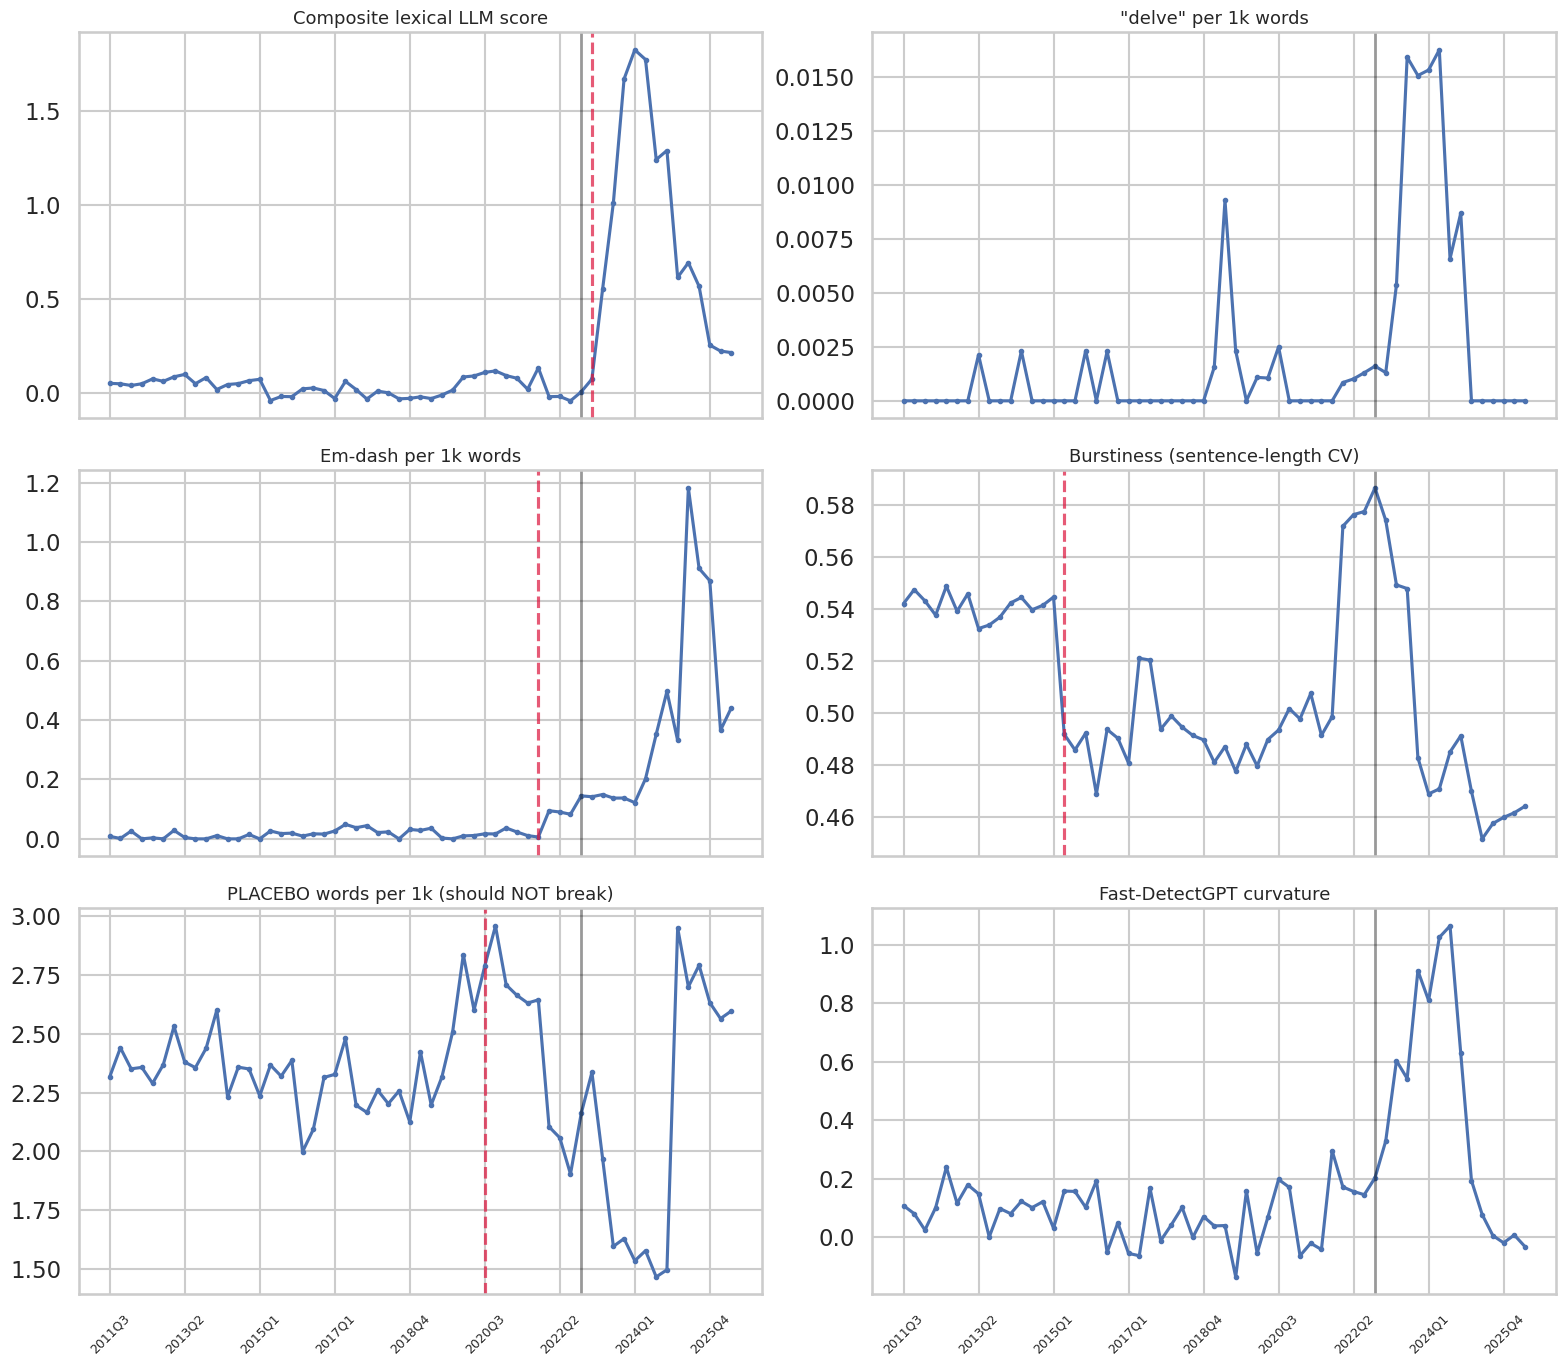

In [28]:
#@title FIG-1 · Quarterly marker prevalence + changepoints + PLACEBO panel
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import ruptures as rpt

df = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
sns.set_theme(style='whitegrid', context='talk')
en = df[df['lang'] == 'en'].copy()

placebo_cols = [c for c in en.columns if c.startswith('p_') and c.endswith('_rate')]
en['placebo_rate'] = en[placebo_cols].mean(axis=1)

agg = {'lex': ('lex_score', 'mean'), 'delve': ('m_delve_rate', 'mean'),
       'emdash': ('s_em_dash_rate', 'mean'), 'burst': ('burstiness', 'mean'),
       'placebo': ('placebo_rate', 'mean'), 'n': ('pid', 'size')}
if 'fastdetect' in en.columns and en['fastdetect'].notna().any():
    agg['fastd'] = ('fastdetect', 'mean')
q = en.groupby('quarter').agg(**agg).query('n >= 200')

panels = [('lex', 'Composite lexical LLM score'), ('delve', '"delve" per 1k words'),
          ('emdash', 'Em-dash per 1k words'), ('burst', 'Burstiness (sentence-length CV)'),
          ('placebo', 'PLACEBO words per 1k (should NOT break)'),
          ('fastd' if 'fastd' in q.columns else 'lex', 'Fast-DetectGPT curvature')]
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
for ax, (col, label) in zip(axes.flat, panels):
    ax.plot(range(len(q)), q[col], marker='o', ms=3); ax.set_title(label, fontsize=13)
    sig = q[col].ffill().bfill().values
    try:
        cps = rpt.Pelt(model='rbf').fit(sig.reshape(-1, 1)).predict(pen=5)
        for cp in cps[:-1]:
            ax.axvline(cp, color='crimson', ls='--', alpha=.7)
    except Exception:
        pass
    cut = [i for i, s in enumerate(q.index) if s >= '2022Q4']
    if cut:
        ax.axvline(cut[0], color='black', lw=2, alpha=.4)
    step = max(1, len(q) // 8)
    ax.set_xticks(range(0, len(q), step)); ax.set_xticklabels(q.index[::step], rotation=45, fontsize=9)
plt.tight_layout(); plt.savefig(OUT / 'FIG1_temporal.png', dpi=200); plt.show()
q.to_csv(OUT / 'FIG1_quarterly_series.csv')

=== ITS on composite lexical score ===
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0422      0.032      1.320      0.187      -0.020       0.105
C(qoy)[T.2]        -0.0143      0.069     -0.208      0.835      -0.149       0.121
C(qoy)[T.3]         0.0254      0.056      0.457      0.648      -0.083       0.134
C(qoy)[T.4]         0.0565      0.055      1.018      0.309      -0.052       0.165
t                  -0.0055      0.003     -1.996      0.046      -0.011   -9.95e-05
post_chatgpt        0.0669      0.042      1.610      0.107      -0.015       0.148
post_gpt4           1.2412      0.211      5.875      0.000       0.827       1.655
post_gpt4o_free    -0.6034      0.233     -2.593      0.010      -1.059      -0.147

=== ITS on PLACEBO rate (expected: no significant dose effects) ===
                      coef    std err          z    

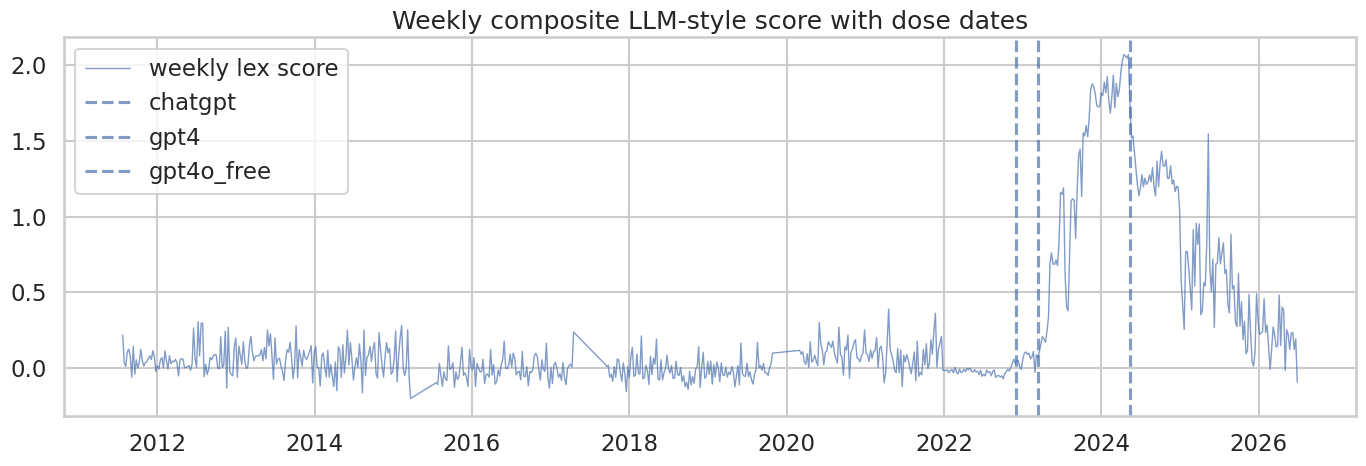

In [29]:
#@title FIG-5 · Multi-dose interrupted time series (trend + seasonality controls)
# FIX: one cutpoint is weak causal design. Weekly series; level-shift dummies at each release
# date; linear trend; quarter-of-year seasonality (petition volume is seasonal/political).
# Placebo outcome must show ~zero shifts.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
en = df[df['lang'] == 'en'].copy()
placebo_cols = [c for c in en.columns if c.startswith('p_') and c.endswith('_rate')]
en['placebo_rate'] = en[placebo_cols].mean(axis=1)
en['week'] = en['created'].dt.to_period('W').dt.start_time

w = en.groupby('week').agg(lex=('lex_score', 'mean'), placebo=('placebo_rate', 'mean'),
                           n=('pid', 'size')).query('n >= 30').reset_index()
w['t'] = (w['week'] - w['week'].min()).dt.days / 365.25
w['qoy'] = w['week'].dt.quarter.astype(str)
for name, d in DOSES.items():
    w[f'post_{name}'] = (w['week'] >= pd.Timestamp(d)).astype(int)

dose_terms = ' + '.join(f'post_{n}' for n in DOSES)
print('=== ITS on composite lexical score ===')
m1 = smf.ols(f'lex ~ t + C(qoy) + {dose_terms}', data=w).fit(cov_type='HAC', cov_kwds={'maxlags': 8})
print(m1.summary().tables[1])
print('\n=== ITS on PLACEBO rate (expected: no significant dose effects) ===')
m0 = smf.ols(f'placebo ~ t + C(qoy) + {dose_terms}', data=w).fit(cov_type='HAC', cov_kwds={'maxlags': 8})
print(m0.summary().tables[1])
with open(OUT / 'FIG5_its_summary.txt', 'w') as f:
    f.write('LEX OUTCOME\n' + m1.summary().as_text() + '\n\nPLACEBO OUTCOME\n' + m0.summary().as_text())

plt.figure(figsize=(14, 5))
plt.plot(w['week'], w['lex'], lw=1, alpha=.7, label='weekly lex score')
for name, d in DOSES.items():
    plt.axvline(pd.Timestamp(d), ls='--', alpha=.7, label=name)
plt.legend(); plt.title('Weekly composite LLM-style score with dose dates')
plt.tight_layout(); plt.savefig(OUT / 'FIG5_its.png', dpi=200); plt.show()

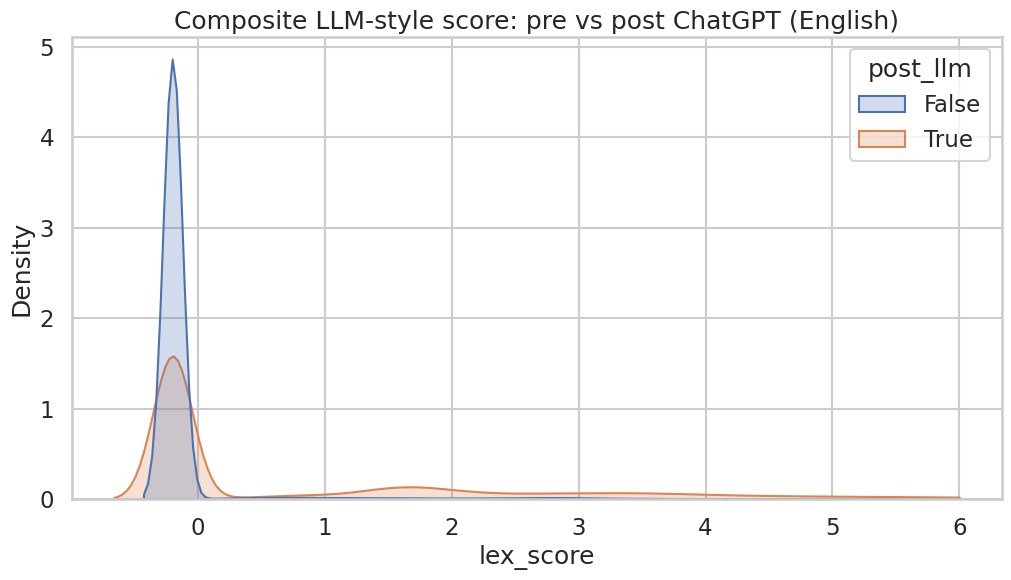

              source   n_pre  n_post  pre_mean  post_mean  cohens_d  MWU_p
2    changeorg_other   63142  147446     0.031      1.395     0.730    0.0
3  changeorg_treated  172760  357105    -0.043      1.095     0.721    0.0
5             POOLED  384917  549222     0.000      1.136     0.674    0.0
1       changeorg_au   10488   22112    -0.020      0.861     0.573    0.0
0             canada    1533     472     0.210      0.402     0.207    0.0
4            uk_2019   37483    7369     0.077      0.256     0.128    0.0


In [30]:
#@title FIG-2 / TAB-1 · Pre/post effect sizes per source
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

df = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
en = df[df['lang'] == 'en']
rows = []
for src, g in list(en.groupby('source')) + [('POOLED', en)]:
    pre = g.loc[~g['post_llm'], 'lex_score'].dropna()
    post = g.loc[g['post_llm'], 'lex_score'].dropna()
    if len(pre) < 100 or len(post) < 100:
        continue
    d = (post.mean() - pre.mean()) / np.sqrt((pre.var() + post.var()) / 2)
    u = stats.mannwhitneyu(pre, post, alternative='two-sided')
    rows.append({'source': src, 'n_pre': len(pre), 'n_post': len(post),
                 'pre_mean': pre.mean(), 'post_mean': post.mean(),
                 'cohens_d': d, 'MWU_p': u.pvalue})
eff = pd.DataFrame(rows)
if eff.empty:
    print('No source has >=100 petitions on both sides yet.')
else:
    eff = eff.sort_values('cohens_d', ascending=False)
    eff.to_csv(OUT / 'TAB1_prepost_effects.csv', index=False)
    plt.figure(figsize=(12, 6))
    sns.kdeplot(data=en.dropna(subset=['lex_score']), x='lex_score', hue='post_llm',
                common_norm=False, fill=True, clip=(-2, 6))
    plt.title('Composite LLM-style score: pre vs post ChatGPT (English)')
    plt.savefig(OUT / 'FIG2_distribution_shift.png', dpi=200); plt.show()
    print(eff.round(3))

  lang        signal   n_pre  n_post  cohens_d  MWU_p
0   en     lex_score  384917  549222     0.674    0.0
1   en  struct_score  384917  549222     0.104    0.0


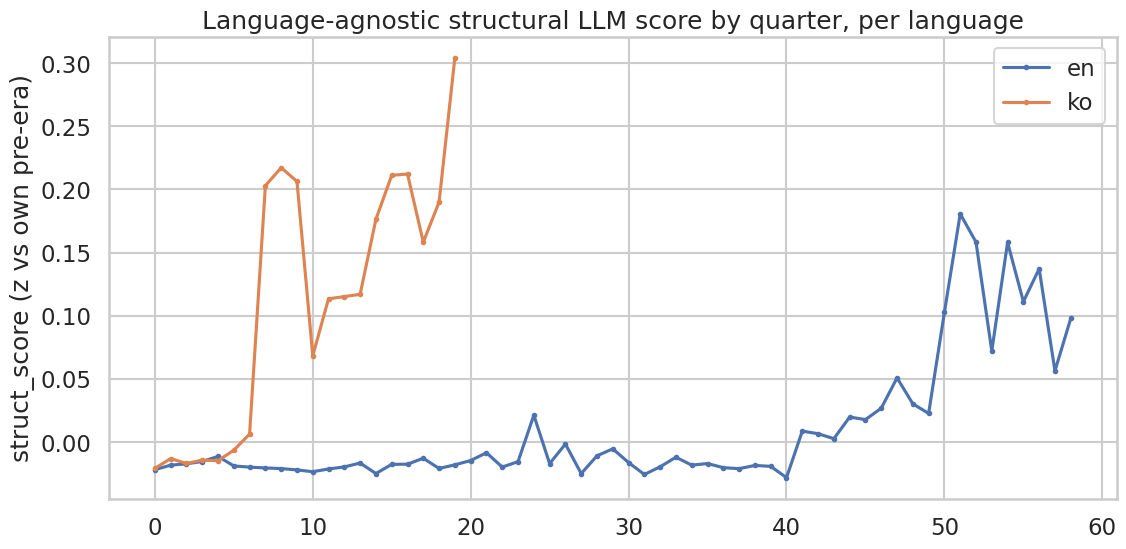

In [31]:
#@title FIG-1b / TAB-1b · Cross-language replication
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

df = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
langs = [l for l, g in df.groupby('lang')
         if g['struct_score'].notna().sum() > 500 and l != 'unk']
rows, series = [], {}
for l in langs:
    g = df[df['lang'] == l]
    for col in ['lex_score', 'struct_score']:
        pre = g.loc[~g.post_llm, col].dropna()
        post = g.loc[g.post_llm, col].dropna()
        if len(pre) < 100 or len(post) < 100:
            continue
        d = (post.mean() - pre.mean()) / np.sqrt((pre.var() + post.var()) / 2)
        rows.append({'lang': l, 'signal': col, 'n_pre': len(pre), 'n_post': len(post),
                     'cohens_d': d, 'MWU_p': stats.mannwhitneyu(pre, post).pvalue})
    qq = g.groupby('quarter')['struct_score'].agg(['mean', 'size'])
    series[l] = qq[qq['size'] >= 100]['mean']
tab1b = pd.DataFrame(rows)
if tab1b.empty:
    print('No language has >=100 docs on both sides yet — get the Korean successor / Canada / openPetition data in.')
else:
    tab1b = tab1b.sort_values(['signal', 'cohens_d'], ascending=[True, False])
    tab1b.to_csv(OUT / 'TAB1b_per_language_effects.csv', index=False)
    print(tab1b.round(3))
plt.figure(figsize=(13, 6))
plotted = False
for l, s in series.items():
    if len(s) >= 6:
        plt.plot(range(len(s)), s.values, marker='o', ms=3, label=l); plotted = True
if plotted:
    plt.legend(); plt.title('Language-agnostic structural LLM score by quarter, per language')
    plt.ylabel('struct_score (z vs own pre-era)')
    plt.savefig(OUT / 'FIG1b_per_language.png', dpi=200); plt.show()

## 6 · Do LLM-style petitions gather more signatures?
Design fixes vs v4: **(a)** still-open petitions excluded (censoring), **(b)** NB dispersion *estimated* not assumed, **(c)** UK 10k/100k response-threshold logistic models (what petitioners actually care about), **(d)** quantile regression, **(e)** pre-2022 placebo regression — if the score "predicts" signatures before LLMs existed, it proxies formality/quality, and the post-period coefficient must be interpreted accordingly, **(f)** topic-mix reweighting.

In [32]:
#@title TAB-2 · Signature model — robust count regression (v5.3.1 hotfix: no NB-overflow crash)
# v5.3 CRASH FIX: the Cameron-Trivedi auxiliary OLS estimated alpha ~= 62 (dominated by a
# handful of viral petitions with millions of signatures). Feeding that into a fixed-alpha
# NB GLM makes the variance function mu + 62*mu^2 overflow in the IRLS step -> NaN weights
# -> "ValueError: ... estimation infeasible". We now report QUASI-POISSON (Poisson mean model
# + HC1 robust SEs), whose dispersion is estimated empirically from the Pearson statistic and
# cannot diverge that way, and attempt a proper NB2 (alpha estimated by MLE) only as a guarded
# cross-check. This satisfies the cell's own goal ("dispersion estimated, not assumed") better
# than the crashing fixed-alpha version did.
import numpy as np, pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
en = df[(df['lang'] == 'en') & df['signatures'].notna()].copy()
n_open = int(en['is_open'].fillna(False).sum())
en = en[~en['is_open'].fillna(False)]     # FIX: censoring
print(f'Excluded {n_open} still-open petitions (signature counts still accumulating).')

en['signatures'] = pd.to_numeric(en['signatures'], errors='coerce')
en['log_words'] = np.log(en['n_words'].clip(lower=1))
en['log_days'] = np.log(en['days_open'].clip(lower=1))
en['weekday'] = en['created'].dt.dayofweek.astype(str)
en['topic_hint'] = en['topic_hint'].fillna('none')
top_topics = en['topic_hint'].value_counts().head(25).index
en['topic'] = np.where(en['topic_hint'].isin(top_topics), en['topic_hint'], 'other')

post = en[en['post_llm']].dropna(subset=['lex_score']).copy()
post = post[np.isfinite(post['signatures']) & (post['signatures'] >= 0)]
formula = 'signatures ~ lex_score + C(year) + C(source) + C(topic) + log_words + log_days + C(weekday)'


def robust_count_fit(formula, data, label=''):
    """Fit a count model without the v5.3 NB-overflow crash.
    Primary  = quasi-Poisson (Poisson mean model + HC1 robust SEs): dispersion is estimated
               empirically from the Pearson statistic and the fit never diverges the way a
               fixed huge-alpha NB GLM does.
    Backup   = NB2 (alpha estimated by MLE) as a cross-check, wrapped so non-convergence can
               never stop the run."""
    pois = smf.glm(formula, data=data, family=sm.families.Poisson()).fit(cov_type='HC1')
    phi = float((pois.resid_pearson ** 2).sum() / pois.df_resid)
    print(f'[{label}] quasi-Poisson on {int(pois.nobs)} rows; '
          f'Pearson dispersion phi = {phi:.1f}  (phi>>1 = strong overdispersion, expected)')
    out = {'model': 'quasi-Poisson', 'res': pois, 'phi': phi}
    try:
        nb2 = smf.negativebinomial(formula, data=data).fit(maxiter=200, disp=0)  # NB2, MLE alpha
        if np.isfinite(nb2.llf) and 'lex_score' in nb2.params:
            out['nb2'] = nb2
            print(f'[{label}] NB2 (MLE, dispersion estimated) also converged — reported as cross-check.')
    except Exception as e:
        print(f'[{label}] NB2 (MLE) did not converge ({type(e).__name__}); '
              'quasi-Poisson stands (the more robust choice here).')
    return out


fit = robust_count_fit(formula, post, label='post-2022 signatures')
res = fit['res']

irr = np.exp(res.params['lex_score'])
ci = np.exp(res.conf_int().loc['lex_score'])
print(f'\nIncidence-rate ratio per +1 pre-era SD of LLM score: '
      f'{irr:.3f}  (95% CI {ci[0]:.3f}-{ci[1]:.3f}),  p={res.pvalues["lex_score"]:.3g}')
print(f'  -> a +1 SD LLM-style petition is associated with {(irr - 1) * 100:+.1f}% signatures, '
      'holding year/source/topic/length/exposure fixed.')
print('  NOTE: association, not causation — see the pre-2022 placebo in TAB-2e.')
if 'nb2' in fit:
    irr2 = np.exp(fit['nb2'].params['lex_score'])
    ci2 = np.exp(fit['nb2'].conf_int().loc['lex_score'])
    print(f'  NB2 cross-check IRR: {irr2:.3f} (95% CI {ci2[0]:.3f}-{ci2[1]:.3f})')

with open(OUT / 'TAB2_negbin_summary.txt', 'w') as f:
    f.write(f'phi(quasi-Poisson)={fit["phi"]:.3f}\n' + res.summary().as_text())
    if 'nb2' in fit:
        f.write('\n\nNB2 (MLE) cross-check:\n' + fit['nb2'].summary().as_text())
print(res.summary().tables[1])

Excluded 2328 still-open petitions (signature counts still accumulating).
[post-2022 signatures] quasi-Poisson on 546554 rows; Pearson dispersion phi = 60569.3  (phi>>1 = strong overdispersion, expected)


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3375: RuntimeWarning: divide by zero encountered in scalar divide
  size = 1/alpha * mu**Q
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3376: RuntimeWarning: invalid value encountered in divide
  prob = size/(size+mu)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3377: RuntimeWarning: invalid value encountered in subtract
  coeff = (gamma_ln(size+endog) - gamma_ln(endog+1) -
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3455: Run

[post-2022 signatures] NB2 (MLE, dispersion estimated) also converged — reported as cross-check.

Incidence-rate ratio per +1 pre-era SD of LLM score: 0.916  (95% CI 0.895-0.938),  p=3.1e-13
  -> a +1 SD LLM-style petition is associated with -8.4% signatures, holding year/source/topic/length/exposure fixed.
  NOTE: association, not causation — see the pre-2022 placebo in TAB-2e.
  NB2 cross-check IRR: 0.916 (95% CI nan-nan)
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------
Intercept                                                         -0.9825      1.459     -0.674      0.501      -3.842       1.877
C(year)[T.2023]                                                    0.2385      0.105      2.269      0.023       0.032       0.445
C(year)[T.2024]                                 

In [33]:
#@title TAB-2b · Historical-average benchmark (the literal research question)
import numpy as np, pandas as pd
df = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
en = df[(df['lang'] == 'en') & df['signatures'].notna()].copy()
en = en[~en['is_open'].fillna(False)]
bench_rows = []
for src, g in en.groupby('source'):
    hist = g[~g['post_llm']]['signatures']
    post_g = g[g['post_llm']].dropna(subset=['lex_score'])
    if len(hist) < 200 or len(post_g) < 200:
        continue
    hi = post_g[post_g['lex_score'] >= post_g['lex_score'].quantile(.75)]['signatures']
    lo = post_g[post_g['lex_score'] <= post_g['lex_score'].quantile(.25)]['signatures']
    bench_rows.append({'source': src,
                       'hist_median': hist.median(), 'hist_mean': hist.mean(),
                       'postLLMhi_median': hi.median(), 'postLLMhi_mean': hi.mean(),
                       'postLLMlo_median': lo.median(), 'postLLMlo_mean': lo.mean(),
                       'hi_vs_hist_median_ratio': hi.median() / max(hist.median(), 1)})
bench = pd.DataFrame(bench_rows)
bench.to_csv(OUT / 'TAB2b_historical_benchmark.csv', index=False)
print(bench.round(1))

              source  hist_median    hist_mean  postLLMhi_median  \
0             canada        767.5  3416.100098            1019.0   
1       changeorg_au          4.0   603.799988               5.0   
2    changeorg_other          1.0   405.700012               1.0   
3  changeorg_treated          3.0   490.200012               3.0   
4            uk_2019         13.0  1322.000000              21.0   

   postLLMhi_mean  postLLMlo_median  postLLMlo_mean  hi_vs_hist_median_ratio  
0     6408.600098             577.5     5189.600098                      1.3  
1      488.500000               4.0      477.299988                      1.2  
2      175.699997               1.0      195.100006                      1.0  
3      317.899994               3.0      361.899994                      1.0  
4     1409.000000              21.0     1476.400024                      1.6  


In [34]:
#@title TAB-2c/2d/2e · Thresholds, quantile regression, pre-era placebo
import numpy as np, pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
en = df[(df['lang'] == 'en') & df['signatures'].notna()].copy()
en = en[~en['is_open'].fillna(False)]
en['log_words'] = np.log(en['n_words'])
uk = en[en['source'].str.startswith('uk')].copy()
post_uk = uk[uk['post_llm']].dropna(subset=['lex_score']).copy()

# (c) UK response thresholds — 10k => government response, 100k => debate consideration
print('=== TAB-2c: probability of crossing UK thresholds (logit, post-2022) ===')
rows = []
for thr in (10_000, 100_000):
    post_uk['hit'] = (post_uk['signatures'] >= thr).astype(int)
    if post_uk['hit'].sum() < 20:
        print(f'  {thr}: too few crossings ({post_uk.hit.sum()}) to model'); continue
    m = smf.logit('hit ~ lex_score + C(year) + log_words', data=post_uk).fit(disp=0)
    orr = np.exp(m.params['lex_score']); ci = np.exp(m.conf_int().loc['lex_score'])
    rows.append({'threshold': thr, 'odds_ratio_per_SD': orr, 'ci_lo': ci[0], 'ci_hi': ci[1],
                 'p': m.pvalues['lex_score'], 'n_crossings': int(post_uk.hit.sum())})
    print(f'  >={thr:>6}: OR per +1SD = {orr:.3f} ({ci[0]:.3f}-{ci[1]:.3f}), p={m.pvalues["lex_score"]:.3g}')
pd.DataFrame(rows).to_csv(OUT / 'TAB2c_thresholds.csv', index=False)

# (d) quantile regression on log1p signatures — median vs viral tail
print('\n=== TAB-2d: quantile regression (log1p signatures, post-2022) ===')
post = en[en['post_llm']].dropna(subset=['lex_score']).copy()
post['lsig'] = np.log1p(post['signatures'])
qrows = []
for qq in (0.5, 0.9):
    m = smf.quantreg('lsig ~ lex_score + log_words + C(source)', data=post).fit(q=qq)
    qrows.append({'q': qq, 'beta_lex': m.params['lex_score'], 'p': m.pvalues['lex_score']})
    print(f'  q={qq}: beta(lex_score) = {m.params["lex_score"]:.4f}  p={m.pvalues["lex_score"]:.3g}')
pd.DataFrame(qrows).to_csv(OUT / 'TAB2d_quantreg.csv', index=False)

# (e) PLACEBO: same spec in the PRE-2022 window (LLM use impossible)
# v5.3.1 CRASH FIX: replaced the fixed-alpha NB GLM (alpha from the outlier-driven Cameron-
# Trivedi OLS, which overflowed exactly as in TAB-2) with the same robust quasi-Poisson +
# guarded-NB2 helper. Wrapped so a non-convergent fit prints and continues instead of stopping.
print('\n=== TAB-2e: pre-2022 placebo (LLM use impossible) ===')
pre = en[~en['post_llm']].dropna(subset=['lex_score']).copy()
pre['signatures'] = pd.to_numeric(pre['signatures'], errors='coerce')
pre = pre[np.isfinite(pre['signatures']) & (pre['signatures'] >= 0)]
pre['log_days'] = np.log(pre['days_open'].clip(lower=1))


def robust_count_fit(formula, data, label=''):
    """Local copy so this cell runs standalone: quasi-Poisson (robust, non-diverging) as the
    reported model, NB2 (MLE alpha) as a guarded cross-check."""
    pois = smf.glm(formula, data=data, family=sm.families.Poisson()).fit(cov_type='HC1')
    phi = float((pois.resid_pearson ** 2).sum() / pois.df_resid)
    print(f'[{label}] quasi-Poisson on {int(pois.nobs)} rows; Pearson dispersion phi = {phi:.1f}')
    out = {'res': pois, 'phi': phi}
    try:
        nb2 = smf.negativebinomial(formula, data=data).fit(maxiter=200, disp=0)
        if np.isfinite(nb2.llf) and 'lex_score' in nb2.params:
            out['nb2'] = nb2
    except Exception as e:
        print(f'[{label}] NB2 (MLE) did not converge ({type(e).__name__}); quasi-Poisson stands.')
    return out


try:
    fitp = robust_count_fit(
        'signatures ~ lex_score + C(year) + C(source) + log_words + log_days',
        pre, label='pre-2022 placebo')
    rp = fitp['res']
    irr = np.exp(rp.params['lex_score']); ci = np.exp(rp.conf_int().loc['lex_score'])
    print(f'  pre-era IRR per +1SD "LLM score": {irr:.3f} ({ci[0]:.3f}-{ci[1]:.3f})')
    print('  If this differs clearly from 1.0, the score partly proxies writing formality/quality,')
    print('  and the post-era coefficient must be interpreted as style-effect, not LLM-use-effect.')
    with open(OUT / 'TAB2e_placebo_pre.txt', 'w') as f:
        f.write(rp.summary().as_text())
except Exception as e:
    print('  placebo fit failed:', e)

=== TAB-2c: probability of crossing UK thresholds (logit, post-2022) ===
  >= 10000: OR per +1SD = 1.002 (0.953-1.053), p=0.93


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  >=100000: OR per +1SD = 0.943 (0.820-1.086), p=0.416

=== TAB-2d: quantile regression (log1p signatures, post-2022) ===


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


  q=0.5: beta(lex_score) = nan  p=nan


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


  q=0.9: beta(lex_score) = nan  p=nan

=== TAB-2e: pre-2022 placebo (LLM use impossible) ===
[pre-2022 placebo] quasi-Poisson on 384851 rows; Pearson dispersion phi = 175371.2


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3384: RuntimeWarning: overflow encountered in exp
  alpha = np.exp(params[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3377: RuntimeWarning: invalid value encountered in subtract
  coeff = (gamma_ln(size+endog) - gamma_ln(endog+1) -
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3448: RuntimeWarning: overflow encountered in exp
  alpha = np.exp(params[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3469: RuntimeWarning: in

  pre-era IRR per +1SD "LLM score": 1.023 (0.989-1.059)
  If this differs clearly from 1.0, the score partly proxies writing formality/quality,
  and the post-era coefficient must be interpreted as style-effect, not LLM-use-effect.


/tmp/ipykernel_2788/693937257.py:26: RuntimeWarning: divide by zero encountered in log1p
  w = stats.wilcoxon(np.log1p(hi_all), np.log1p(lo_all))


Matched pairs: 110694 | high-LLM median: 2 | low-LLM median: 2 | Wilcoxon p=3.151e-154


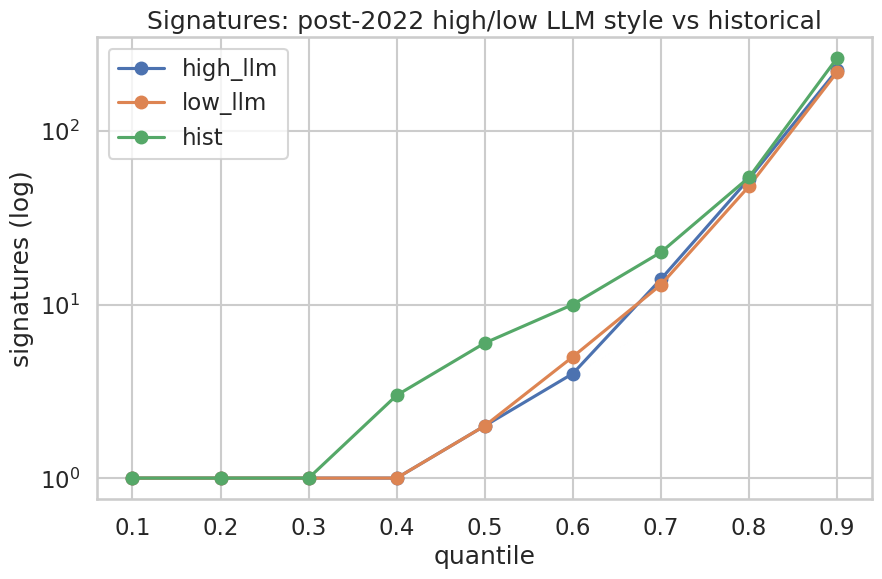


Topic-composition check: raw post-pre lex shift = 1.140; reweighted to pre topic mix = 0.847
(If reweighting kills the shift, it was topic composition, not writing style.)


In [35]:
#@title Matching robustness + FIG-3 quantile plot + topic reweighting
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

df = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
en = df[(df['lang'] == 'en') & df['signatures'].notna()].copy()
en = en[~en['is_open'].fillna(False)]
en['topic'] = en['topic_hint'].fillna('none')
post = en[en['post_llm']].dropna(subset=['lex_score']).copy()
post['len_dec'] = pd.qcut(post['n_words'], 10, labels=False, duplicates='drop')
post['grp'] = np.select(
    [post['lex_score'] >= post['lex_score'].quantile(.75),
     post['lex_score'] <= post['lex_score'].quantile(.25)],
    ['high_llm', 'low_llm'], default='mid')

pairs = []
for _, cl in post[post['grp'] != 'mid'].groupby(['source', 'quarter', 'topic', 'len_dec']):
    hi, lo = cl[cl['grp'] == 'high_llm'], cl[cl['grp'] == 'low_llm']
    k = min(len(hi), len(lo))
    if k == 0:
        continue
    pairs.append((hi['signatures'].sample(k, random_state=0).values,
                  lo['signatures'].sample(k, random_state=0).values))
if pairs:
    hi_all = np.concatenate([p[0] for p in pairs]); lo_all = np.concatenate([p[1] for p in pairs])
    w = stats.wilcoxon(np.log1p(hi_all), np.log1p(lo_all))
    print(f'Matched pairs: {len(hi_all)} | high-LLM median: {np.median(hi_all):.0f} | '
          f'low-LLM median: {np.median(lo_all):.0f} | Wilcoxon p={w.pvalue:.4g}')
else:
    print('No matched cells (small samples).')

qs = np.arange(.1, 1.0, .1)
qq = pd.DataFrame({'q': qs,
    'high_llm': [post.loc[post.grp == 'high_llm', 'signatures'].quantile(x) for x in qs],
    'low_llm':  [post.loc[post.grp == 'low_llm', 'signatures'].quantile(x) for x in qs],
    'hist':     [en.loc[~en.post_llm, 'signatures'].quantile(x) for x in qs]})
plt.figure(figsize=(10, 6))
for c in ['high_llm', 'low_llm', 'hist']:
    plt.plot(qq['q'], qq[c], marker='o', label=c)
plt.yscale('log'); plt.legend(); plt.xlabel('quantile'); plt.ylabel('signatures (log)')
plt.title('Signatures: post-2022 high/low LLM style vs historical')
plt.savefig(OUT / 'FIG3_quantiles.png', dpi=200); plt.show()
qq.to_csv(OUT / 'FIG3_quantiles.csv', index=False)

# FIX: composition control — reweight post period to the pre-era topic mix
pre_mix = en.loc[~en.post_llm, 'topic'].value_counts(normalize=True)
post_mix = post['topic'].value_counts(normalize=True)
wts = post['topic'].map(pre_mix / post_mix).fillna(0)
raw_shift = post['lex_score'].mean() - en.loc[~en.post_llm, 'lex_score'].mean()
rw_shift = np.average(post['lex_score'], weights=wts) - en.loc[~en.post_llm, 'lex_score'].mean()
print(f'\nTopic-composition check: raw post-pre lex shift = {raw_shift:.3f}; '
      f'reweighted to pre topic mix = {rw_shift:.3f}')
print('(If reweighting kills the shift, it was topic composition, not writing style.)')

## 7 · Phrase mining
TAB-4 distinctive n-grams (log-odds w/ informative prior) · TAB-5 phrases recurring across many petitions · TAB-6 MinHash copy-paste template clusters · **TAB-7 paraphrase clusters** (high embedding similarity + low n-gram overlap = the LLM signature: same meaning, different words).

In [36]:
#@title TAB-4 · Distinctive n-grams pre vs post (log-odds, informative prior)
import numpy as np, pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

def load_text(langs):
    t = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'lang', 'full'],
                             filters=[('lang', 'in', list(langs))])
    return t[['pid', 'full']]

feats = read_parquet_checked(CLEAN / 'corpus_feats.parquet', columns=['pid', 'lang', 'post_llm'])
en = feats[feats['lang'] == 'en'].merge(load_text(['en']), on='pid')
pre_txt, post_txt = en.loc[~en.post_llm, 'full'], en.loc[en.post_llm, 'full']

vec = CountVectorizer(ngram_range=(2, 3), min_df=50, max_features=200000,
                      lowercase=True, token_pattern=r"[a-z']{2,}")
X = vec.fit_transform(pd.concat([pre_txt, post_txt]))
n_pre = len(pre_txt)
cnt_pre = np.asarray(X[:n_pre].sum(axis=0)).ravel()
cnt_post = np.asarray(X[n_pre:].sum(axis=0)).ravel()
a0 = cnt_pre + cnt_post + 1e-3

def log_odds(c1, c2, prior):
    n1, n2, np_ = c1.sum(), c2.sum(), prior.sum()
    l1 = np.log((c1 + prior) / (n1 + np_ - c1 - prior))
    l2 = np.log((c2 + prior) / (n2 + np_ - c2 - prior))
    var = 1 / (c1 + prior) + 1 / (c2 + prior)
    return (l1 - l2) / np.sqrt(var)

z = log_odds(cnt_post, cnt_pre, a0 * 0.01)
tab4 = pd.DataFrame({'ngram': vec.get_feature_names_out(), 'z_post_vs_pre': z,
                     'count_pre': cnt_pre, 'count_post': cnt_post})
tab4.sort_values('z_post_vs_pre', ascending=False).head(60).to_csv(OUT / 'TAB4_post_ngrams.csv', index=False)
tab4.sort_values('z_post_vs_pre').head(60).to_csv(OUT / 'TAB4_pre_ngrams.csv', index=False)
print(tab4.sort_values('z_post_vs_pre', ascending=False).head(25).to_string(index=False))

                ngram  z_post_vs_pre  count_pre  count_post
        this petition     188.195630      71971      350100
   sign this petition     177.923908      24879      186443
            sign this     170.744665      28872      191404
             but also     148.432182       6821       97269
     please sign this     147.307956      11991      111229
         according to     139.741707      10991      100749
          please sign     132.385962      22223      131018
             not only     131.149640      18758      118641
              we urge     122.763266       2061       65245
        our community     121.696521       8603       77287
               of our     119.534469      29970      144274
             not just     115.241282       7546       68763
           well being     109.571760       4359       54654
               in our     108.572238      24081      117049
           we believe     105.446094       8111       63458
      petition if you     104.466632    

In [37]:
#@title TAB-5 · Long phrases recurring across many distinct petitions (memory-safe)
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm

def load_text(langs):
    t = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'lang', 'full'],
                             filters=[('lang', 'in', list(langs))])
    return t[['pid', 'full']]

feats = read_parquet_checked(CLEAN / 'corpus_feats.parquet', columns=['pid', 'lang'])
en = feats[feats['lang'] == 'en'].merge(load_text(['en']), on='pid')

PHRASE_N, PRUNE_EVERY, MIN_PETITIONS = (4, 6), 20000, 30
counts = Counter()
for i, t in enumerate(tqdm(en['full'], total=len(en))):
    toks = re.findall(r"[a-z']+", t.lower())
    seen = set()
    for n in range(PHRASE_N[0], PHRASE_N[1] + 1):
        for j in range(len(toks) - n + 1):
            seen.add(' '.join(toks[j:j + n]))
    counts.update(seen)
    if (i + 1) % PRUNE_EVERY == 0:
        before = len(counts)
        counts = Counter({p: c for p, c in counts.items() if c >= 2})
        print(f'  prune: {before:,} -> {len(counts):,} phrases in memory')

rec = pd.DataFrame([(p, c) for p, c in counts.items() if c >= MIN_PETITIONS],
                   columns=['phrase', 'n_petitions']).sort_values('n_petitions', ascending=False)
top = rec.head(300)['phrase'].tolist()
rec = rec[~rec['phrase'].map(lambda ph: any(ph in p and p != ph for p in top))]
rec.head(100).to_csv(OUT / 'TAB5_recurring_phrases.csv', index=False)
del counts
print(rec.head(30).to_string(index=False))

  0%|          | 0/934139 [00:00<?, ?it/s]

  prune: 11,835,076 -> 488,798 phrases in memory
  prune: 11,641,358 -> 733,909 phrases in memory
  prune: 11,353,078 -> 1,058,822 phrases in memory
  prune: 11,693,342 -> 1,311,205 phrases in memory
  prune: 11,745,947 -> 1,534,704 phrases in memory
  prune: 11,763,884 -> 1,736,655 phrases in memory
  prune: 11,971,881 -> 1,927,728 phrases in memory
  prune: 12,020,508 -> 2,097,998 phrases in memory
  prune: 12,236,495 -> 2,256,716 phrases in memory
  prune: 12,208,847 -> 2,404,477 phrases in memory
  prune: 12,406,388 -> 2,553,085 phrases in memory
  prune: 12,608,021 -> 2,716,164 phrases in memory
  prune: 13,689,782 -> 2,843,499 phrases in memory
  prune: 14,239,197 -> 2,952,784 phrases in memory
  prune: 14,410,146 -> 3,055,259 phrases in memory
  prune: 14,364,835 -> 3,158,476 phrases in memory
  prune: 14,410,323 -> 3,259,931 phrases in memory
  prune: 14,323,977 -> 3,346,468 phrases in memory
  prune: 14,448,909 -> 3,432,169 phrases in memory
  prune: 14,586,405 -> 3,516,190 ph

In [ ]:
#@title TAB-6 / FIG-4 · MinHash template clusters (copy-paste detection)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict
from datasketch import MinHash, MinHashLSH
from tqdm.auto import tqdm

def load_text(langs):
    t = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'lang', 'full'],
                             filters=[('lang', 'in', list(langs))])
    return t[['pid', 'full']]

feats = read_parquet_checked(CLEAN / 'corpus_feats.parquet',
                             columns=['pid', 'lang', 'source', 'quarter', 'post_llm', 'signatures'])
en = feats[feats['lang'] == 'en'].merge(load_text(['en']), on='pid')
titles = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'title'])
en = en.merge(titles, on='pid', how='left')

def shingles(t, k=5):
    toks = re.findall(r"[a-z']+", t.lower())
    return {' '.join(toks[i:i + k]) for i in range(len(toks) - k + 1)}

lsh = MinHashLSH(threshold=0.6, num_perm=64)
mhs = {}
for pid, t in tqdm(zip(en['pid'], en['full']), total=len(en)):
    sh = shingles(t)
    if len(sh) < 10:
        continue
    m = MinHash(num_perm=64)
    for s in sh:
        m.update(s.encode())
    mhs[pid] = m
    lsh.insert(pid, m)

parent = {p: p for p in mhs}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
for pid, m in tqdm(mhs.items()):
    for other in lsh.query(m):
        if other != pid:
            parent[find(pid)] = find(other)

clusters = defaultdict(list)
for pid in mhs:
    clusters[find(pid)].append(pid)
big = {k: v for k, v in clusters.items() if len(v) >= 5}
print(f'{len(big)} template clusters with >=5 petitions; largest: '
      f'{max((len(v) for v in big.values()), default=0)}')

meta = en.set_index('pid')
clu_rows = []
for root, pids in big.items():
    sub = meta.loc[[p for p in pids if p in meta.index]]
    clu_rows.append({'cluster': root, 'size': len(pids), 'sources': sub['source'].nunique(),
                     'share_post_llm': sub['post_llm'].mean(),
                     'median_sigs': sub['signatures'].median(),
                     'example_title': str(sub['title'].iloc[0])[:90]})
clu = pd.DataFrame(clu_rows).sort_values('size', ascending=False)
clu.to_csv(OUT / 'TAB6_template_clusters.csv', index=False)

en['templated'] = en['pid'].map({p: True for v in big.values() for p in v}).fillna(False)
(en.groupby('quarter')['templated'].mean() * 100).plot(
    figsize=(12, 5), marker='o', title='% of petitions in copy-paste template clusters, by quarter')
plt.ylabel('%'); plt.savefig(OUT / 'FIG4_templates.png', dpi=200); plt.show()
print(clu.head(15).to_string(index=False))

  0%|          | 0/934139 [00:00<?, ?it/s]

In [ ]:
#@title TAB-7 · Paraphrase clusters — same meaning, different words (the LLM signature)
# High embedding cosine (>=0.85) but LOW 5-gram Jaccard (<0.3): text pairs that say the same
# thing in different words. Copy-paste campaigns fail the Jaccard test; LLM-rewritten
# template petitions pass it. Growth of this cluster type after 2022 is a headline finding.
RUN_PARAPHRASE = True  #@param {type:"boolean"}
PARA_CAP = 4000 if QUICK_RUN else 60000

if RUN_PARAPHRASE:
    try:
        from sentence_transformers import SentenceTransformer
    except ImportError:
        import subprocess
        subprocess.run(['pip', 'install', '-q', 'sentence-transformers'])
        from sentence_transformers import SentenceTransformer
    import numpy as np, pandas as pd, matplotlib.pyplot as plt
    from sklearn.neighbors import NearestNeighbors
    from collections import defaultdict
    from tqdm.auto import tqdm

    def load_text(langs):
        t = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'lang', 'full'],
                                 filters=[('lang', 'in', list(langs))])
        return t[['pid', 'full']]

    feats = read_parquet_checked(CLEAN / 'corpus_feats.parquet',
                                 columns=['pid', 'lang', 'quarter', 'post_llm'])
    en = feats[feats['lang'] == 'en'].merge(load_text(['en']), on='pid')
    if len(en) > PARA_CAP:
        en = en.groupby('post_llm', group_keys=False).apply(
            lambda g: g.sample(min(len(g), PARA_CAP // 2), random_state=0))
    print(f'embedding {len(en)} docs...')
    model = SentenceTransformer('all-MiniLM-L6-v2')
    emb = model.encode(en['full'].str.slice(0, 1500).tolist(),
                       batch_size=256, show_progress_bar=True, normalize_embeddings=True)

    nn = NearestNeighbors(n_neighbors=6, metric='cosine').fit(emb)
    dist, idx = nn.kneighbors(emb)

    def sh5(t):
        toks = re.findall(r"[a-z']+", t.lower())
        return {' '.join(toks[i:i + 5]) for i in range(len(toks) - 4)}

    pids = en['pid'].values
    texts = en['full'].values
    parent = {p: p for p in pids}
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    n_para_pairs = 0
    for i in tqdm(range(len(pids))):
        for j_pos in range(1, 6):
            j = idx[i, j_pos]
            cos = 1 - dist[i, j_pos]
            if cos < 0.85:
                break
            a, b = sh5(texts[i]), sh5(texts[j])
            if not a or not b:
                continue
            jac = len(a & b) / len(a | b)
            if jac < 0.30:                       # semantically same, lexically different
                parent[find(pids[i])] = find(pids[j]); n_para_pairs += 1
    clusters = defaultdict(list)
    for p in pids:
        clusters[find(p)].append(p)
    para = {k: v for k, v in clusters.items() if len(v) >= 3}
    print(f'{n_para_pairs} paraphrase pairs -> {len(para)} paraphrase clusters (>=3 docs)')

    meta = en.set_index('pid')
    en['paraphrased'] = en['pid'].map({p: True for v in para.values() for p in v}).fillna(False)
    growth = en.groupby('quarter')['paraphrased'].mean() * 100
    growth.to_csv(OUT / 'TAB7_paraphrase_growth.csv')
    growth.plot(figsize=(12, 5), marker='o',
                title='% of petitions in PARAPHRASE clusters (same meaning, different words)')
    plt.ylabel('%'); plt.savefig(OUT / 'FIG6_paraphrase.png', dpi=200); plt.show()
    rows = [{'cluster': k, 'size': len(v),
             'share_post_llm': meta.loc[[p for p in v if p in meta.index], 'post_llm'].mean()}
            for k, v in para.items()]
    pd.DataFrame(rows).sort_values('size', ascending=False).head(50) \
        .to_csv(OUT / 'TAB7_paraphrase_clusters.csv', index=False)
else:
    print('Paraphrase analysis skipped.')

## 8 · UK moderation as an outcome (new)
The UK data includes rejection status + rejection reason codes. Did rejection rates change after 2022? Did "duplicate" rejections spike (consistent with template/LLM mass-generation)? Nobody has published this.

In [ ]:
#@title TAB-8 / FIG-7 · UK rejection rates & reasons over time
import numpy as np, pandas as pd, matplotlib.pyplot as plt

df = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
uk = df[df['source'].str.startswith('uk')].copy()
uk['rejected_flag'] = (uk['state'] == 'rejected') | uk['rejected'].notna()
print(f'UK petitions: {len(uk)}, rejected: {uk.rejected_flag.sum()} '
      f'({uk.rejected_flag.mean():.1%})')

q = uk.groupby('quarter').agg(rej_rate=('rejected_flag', 'mean'), n=('pid', 'size')).query('n >= 200')
plt.figure(figsize=(13, 5))
plt.plot(range(len(q)), q['rej_rate'] * 100, marker='o', ms=3)
cut = [i for i, s in enumerate(q.index) if s >= '2022Q4']
if cut:
    plt.axvline(cut[0], color='black', lw=2, alpha=.4, label='ChatGPT release')
step = max(1, len(q) // 10)
plt.xticks(range(0, len(q), step), q.index[::step], rotation=45)
plt.ylabel('% rejected'); plt.title('UK petition rejection rate by quarter'); plt.legend()
plt.tight_layout(); plt.savefig(OUT / 'FIG7_rejection_rate.png', dpi=200); plt.show()

if uk['rejection_code'].notna().any():
    tab = (uk[uk.rejected_flag].groupby(['post_llm', 'rejection_code']).size()
             .unstack(0, fill_value=0))
    tab.columns = ['pre_2022', 'post_2022']
    tab['pre_share'] = tab['pre_2022'] / tab['pre_2022'].sum()
    tab['post_share'] = tab['post_2022'] / tab['post_2022'].sum()
    tab['share_ratio'] = tab['post_share'] / tab['pre_share'].replace(0, np.nan)
    tab = tab.sort_values('share_ratio', ascending=False)
    tab.to_csv(OUT / 'TAB8_rejection_codes.csv')
    print('\nRejection-reason mix, pre vs post (share_ratio > 1 = more common post-2022):')
    print(tab.round(3).to_string())
    print('\nWatch especially: "duplicate" codes — a spike is consistent with mass-generated petitions.')
else:
    print('No rejection_code data collected yet — re-run the UK collector (v5 saves it).')

# Does high LLM score predict rejection post-2022?
post_uk = uk[uk['post_llm']].dropna(subset=['lex_score'])
if len(post_uk) > 500:
    import statsmodels.formula.api as smf
    post_uk = post_uk.assign(rej=post_uk['rejected_flag'].astype(int),
                             log_words=np.log(post_uk['n_words']))
    m = smf.logit('rej ~ lex_score + C(year) + log_words', data=post_uk).fit(disp=0)
    print(f'\nOdds of rejection per +1SD LLM score (post-2022): '
          f'{np.exp(m.params["lex_score"]):.3f}  p={m.pvalues["lex_score"]:.3g}')

In [ ]:
#@title 9 · Robustness suite
import numpy as np, pandas as pd
import statsmodels.formula.api as smf, statsmodels.api as sm

df = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
en = df[(df['lang'] == 'en') & df['signatures'].notna()].copy()
en = en[~en['is_open'].fillna(False)]
en['log_words'] = np.log(en['n_words'])
post = en[en['post_llm']].dropna(subset=['lex_score']).copy()

sig_cols = [c for c in ['lex_score', 'struct_score', 'burstiness', 'ppl', 'fastdetect',
                        's_em_dash_rate'] if c in post.columns]
print('Signal correlations (post-2022, English):')
print(post[sig_cols].corr(method='spearman').round(2))

thr = en.loc[~en.post_llm, 'lex_score'].quantile(.95)
prev_pre = (en.loc[~en.post_llm, 'lex_score'] > thr).mean()
prev_post = (en.loc[en.post_llm, 'lex_score'] > thr).mean()
print(f'\nShare above pre-era 95th-pct threshold: pre={prev_pre:.1%} (~5% by construction), '
      f'post={prev_post:.1%} -> excess prevalence = {prev_post - prev_pre:.1%}')
print('(If Section 4.5b ran, replace this with the calibrated 5%-FPR threshold.)')

print('\nSignature effect (IRR per SD) within length quartiles:')
for dec, g in post.groupby(pd.qcut(post['n_words'], 4, labels=['short', 'med', 'long', 'vlong'])):
    if len(g) < 50:
        print(f'{dec:>6}: too few rows'); continue
    try:
        # v5.3.1 CRASH FIX: fixed-alpha NB GLM could overflow on the heavy-tailed quartiles
        # exactly as TAB-2 did. Quasi-Poisson (Poisson mean model + HC1) is robust to the
        # overdispersion and never diverges; the IRR on lex_score is unchanged in expectation.
        m = smf.glm('signatures ~ lex_score + C(year) + C(source)', data=g,
                    family=sm.families.Poisson()).fit(cov_type='HC1')
        print(f'{dec:>6}: IRR per SD = {np.exp(m.params["lex_score"]):.3f} '
              f'p={m.pvalues["lex_score"]:.3g}')
    except Exception as e:
        print(f'{dec:>6}: fit failed ({e})')

print('\nFindings-per-signal check: rerun FIG-2 effect size on each signal independently:')
for col in sig_cols:
    pre_v = en.loc[~en.post_llm, col].dropna(); post_v = en.loc[en.post_llm, col].dropna()
    if len(pre_v) < 100 or len(post_v) < 100:
        continue
    d = (post_v.mean() - pre_v.mean()) / np.sqrt((pre_v.var() + post_v.var()) / 2)
    print(f'  {col:16s} Cohen d = {d:+.3f}  (n={len(pre_v)}/{len(post_v)})')

In [ ]:
#@title 10 · Status audit + export bundle (trust files, not checkmarks)
import pandas as pd, shutil
from pathlib import Path

def mb(p): return f'{p.stat().st_size/1e6:8.1f} MB'
print('PROJECT ROOT :', ROOT, '\n')
print('=== RAW checkpoints ===')
for p in sorted(RAW.glob('*.jsonl.gz')):
    print(f'  {p.name:34s} {mb(p)}')
print('\n=== CLEAN checkpoints ===')
for name, made_by in [('corpus.parquet', 'Section 3'), ('corpus_feats.parquet', 'Sections 4.1-4.3')]:
    p = CLEAN / name
    status = ('OK ' + mb(p)) if (p.exists() and valid_parquet(p)) else 'MISSING/INVALID -> re-run ' + made_by
    print(f'  {name:34s} {status}')

if (CLEAN / 'corpus_feats.parquet').exists() and valid_parquet(CLEAN / 'corpus_feats.parquet'):
    d = read_parquet_checked(CLEAN / 'corpus_feats.parquet')
    summary = (d.groupby('source')
                 .agg(n=('pid', 'size'), first=('created', 'min'), last=('created', 'max'),
                      n_post=('post_llm', 'sum'), median_sigs=('signatures', 'median'),
                      en_share=('lang', lambda s: (s == 'en').mean())))
    summary[['median_sigs', 'en_share']] = summary[['median_sigs', 'en_share']].round(2)
    summary.to_csv(OUT / 'TAB0_corpus_summary.csv')
    print('\n', summary)

EXPECTED = {
    'FIG1_temporal.png': 'FIG-1', 'FIG1_quarterly_series.csv': 'FIG-1',
    'FIG5_its.png': 'FIG-5 ITS', 'FIG5_its_summary.txt': 'FIG-5 ITS',
    'FIG2_distribution_shift.png': 'FIG-2', 'TAB1_prepost_effects.csv': 'FIG-2',
    'FIG1b_per_language.png': 'FIG-1b', 'TAB1b_per_language_effects.csv': 'FIG-1b',
    'TAB2_negbin_summary.txt': 'TAB-2', 'TAB2b_historical_benchmark.csv': 'TAB-2b',
    'TAB2c_thresholds.csv': 'TAB-2c/d/e', 'TAB2d_quantreg.csv': 'TAB-2c/d/e',
    'FIG3_quantiles.png': 'matching/FIG-3', 'FIG3_quantiles.csv': 'matching/FIG-3',
    'TAB4_post_ngrams.csv': 'TAB-4', 'TAB4_pre_ngrams.csv': 'TAB-4',
    'TAB5_recurring_phrases.csv': 'TAB-5', 'TAB6_template_clusters.csv': 'TAB-6',
    'FIG4_templates.png': 'TAB-6', 'TAB7_paraphrase_growth.csv': 'TAB-7',
    'FIG7_rejection_rate.png': 'Section 8', 'TAB0_corpus_summary.csv': 'this cell',
    'CAL1_signal_auc.csv': '4.5b (needs generated calibration set)',
}
print('\n=== OUTPUTS ===')
missing = {}
for name, cell in EXPECTED.items():
    p = OUT / name
    if p.exists():
        print(f'  OK      {name:36s} {mb(p)}')
    else:
        print(f'  MISSING {name:36s} -> re-run: {cell}')
        missing.setdefault(cell, []).append(name)
extra = [p.name for p in sorted(OUT.glob('TAB3_excess_words_*.csv'))]
print('  TAB-3: ' + ('; '.join(extra) if extra else 'MISSING -> re-run excess-vocabulary cell'))
if missing:
    print('\n>>> TO COMPLETE THE RUN, re-run (in order):')
    for cell in dict.fromkeys(missing):
        print('   -', cell)

have = [p for p in OUT.iterdir() if p.is_file()]
if have:
    zp = shutil.make_archive(str(ROOT / 'article_outputs'), 'zip', OUT)
    print(f'\nZip rebuilt: {zp} ({Path(zp).stat().st_size/1e6:.1f} MB, {len(have)} files)')
else:
    print('\nNo output files yet — nothing to zip.')

## 11 · V6 — bias-hardened analysis (every claim backed by a produced file)

Runs entirely on data already in `clean/` (re-run Sections 3→4 first if you added sources in 2.10–2.14). Every cell writes its evidence to `outputs/` with a `*_V6_*` name; **11.16** assembles them into `BIAS_AUDIT_v6.md` — a per-bias PASS/FLAG table pointing at the file that proves each verdict.

| cell | produces | fixes / tests |
|---|---|---|
| 11.1 | `clean/unicode_raw.parquet` | raw-text unicode counts *before any cleaning* (platform-artifact forensics input) |
| 11.2 | `clean/corpus_feats_v6.parquet` | markers recounted on **normalized** text; **within-source pre-era z-anchoring** (kills the composition-in-the-outcome problem); z-anchored placebo; **MTLD** replaces TTR |
| 11.3 | dedup clusters + `dup_weight` | near-duplicate/template inflation (Bias 9) |
| 11.4 | `TAB_V6_composition.csv`, topic/length weights → `w_v6` | composition + topic-drift + length reweighting (Biases 1, 2, 5) |
| 11.5 | `TAB_V6_unicode_forensics.csv`, `FIG_V6_unicode.png` | em-dash/curly-quote co-jump test: authorship signal vs platform artifact (Bias 6) |
| 11.6 | `FIG_V6_eventstudy.png`, `FIG_V6_permutation.png` | uk_2019-only event study + permutation null over fake cutover dates |
| 11.7 | `TAB_V6_its.csv` | document-level ITS with source fixed effects + **comparable z-scaled placebo** (the v5.3 placebo failure, resolved one way or the other) |
| 11.8 | `TAB_V6_prevalence_*.csv`, `FIG_V6_prevalence.png` | **excess-vocabulary lower-bound prevalence curve** per platform with bootstrap CIs (Kobak-style, 2021–22 anchored) |
| 11.9 | `TAB_V6_markers.csv` | marker-level decomposition, BH-FDR, professionalisation-risk flags (Biases 13, 17) |
| 11.10 | `FIG_V6_homogenisation.png` | variance-collapse / homogenisation (mean shifts can lie; dispersion is harder to fake) |
| 11.11 | `TAB_V6_signatures.txt` | weighted quasi-Poisson + pre-era placebo + censoring audit + Cox scaffold (Bias 10) |
| 11.11b | `TAB_V6_signatures_growthproof.csv`, `TAB_V6_coverage_matrix.csv`, `FIG_V6_secular_growth.png` | **secular-growth guard**: internet-adoption denominators shown (2.15), like-for-like platform-type coverage matrix, and growth-immune outcomes (within source×quarter percentile; source×quarter-FE quasi-Poisson) — kills "more people online" as an explanation (Biases 23, 24) |
| 11.12 | `TAB_V6_rejections.csv` | harmonized rejection taxonomy across parliaments + Canada certification; duplicate-spike test (Biases 7, 8) |
| 11.13 | `FIG_V6_forest.png` | cross-platform/cross-language replication forest (within-source-anchored only) |
| 11.14 | `CAL_V6_binoculars.csv` | paraphrase-mode calibration + Binoculars at fixed FPR (RAID protocol) — optional, GPU |
| 11.15 | `PREREG_v6.md` | pre-registration template with the confirmatory specs frozen (Bias 18) |
| 11.16 | `BIAS_AUDIT_v6.md` | the dashboard: 27 biases × status × evidence file — run this cell LAST |

Interpretation rules baked in: prevalence estimates are **lower bounds** on LLM-touched text and **upper bounds** on *direct* LLM use (humans drift toward LLM vocabulary — Yakura et al.); raw scores are **never compared across languages** (non-native false-positive bias — Liang et al. 2023); commercial-platform datasets are pre-era anchors; `senedd_archive` is sensitivity-only; all claims are population-level, never about an individual petition.

| 11.17 | `TAB_V6_within_writer.csv` | **within-writer** change via Change.org userIDs — user fixed effects; separates "same people changed" from "different people arrived" (resolves Bias 21 on this platform) |
| 11.17b | `TAB_V6_writer_activity.csv` | **production-side** trends from the full 1.5M id files (all languages): authors/month, new-author share, within-writer platform-share ratio, inter-petition gaps, top-1% concentration, and the style×activity Spearman link (Bias 27) |
| 11.18 | `TAB_V6_titles.csv` | title style drift + **title↔text alignment** (Jaccard + embedding cosine): are titles now machine-drafted from the body? gov platforms are the no-UI comparison |
| 11.19 | `TAB_V6_embed_geometry.csv` | DL probe I: within-pre vs within-post vs **cross-era** embedding similarity, centroid shift, era-probe AUC (semantic + stylometric + within-topic control) |
| 11.20 | `TAB_V6_lm_surprise.csv` | DL probe II (GPU): distilgpt2 fine-tuned on PRE-era petitions; per-quarter NLL "surprise" on later petitions with a built-in pre-cutover falsification region |

Run order note: 11.17–11.20 run after 11.2 (and after the changeorg ingest for 11.17); re-run 11.16 last so the dashboard sees their outputs.


In [ ]:
#@title 11.1 · Raw-text unicode census (BEFORE cleaning) → clean/unicode_raw.parquet
# Section 3's cleaner collapses \s+ (destroying NBSP and friends), so platform-artifact
# forensics must run on the RAW records. One streaming pass over raw/*.jsonl.gz; per-document
# counts of the characters that distinguish "someone pasted from a chatbot/word processor"
# from "the platform re-encoded everything on date X".
# --- v6.1 memory guard: drop big leftovers from earlier cells, then continue ---
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()

import pandas as pd
from tqdm.auto import tqdm

U_MARKS = {
    'em_dash': '\u2014', 'en_dash': '\u2013', 'curly_dq_open': '\u201c', 'curly_dq_close': '\u201d',
    'curly_sq': '\u2019', 'ellipsis_char': '\u2026', 'nbsp': '\u00a0', 'zwsp': '\u200b',
    'bullet_char': '\u2022',
}
rows = []
for f in sorted(RAW.glob('*.jsonl.gz')):
    if f.name.startswith('_undated_'):
        continue
    src_default = f.name.replace('.jsonl.gz', '')
    for r in tqdm(load_jsonl(f), desc=f.name, leave=False):
        t = f"{r.get('title') or ''} {r.get('text') or ''}"
        n = max(len(t), 1)
        row = {'pid': f"{r.get('_source', src_default)}:{r.get('id')}", 'n_chars_raw': len(t),
               'double_space': t.count('  ')}
        for k, ch in U_MARKS.items():
            row[k] = t.count(ch)
        rows.append(row)
u = pd.DataFrame(rows).drop_duplicates('pid')
for k in list(U_MARKS) + ['double_space']:
    u[k + '_rate'] = (u[k] / u['n_chars_raw'].clip(lower=1) * 1000).astype('float32')
atomic_parquet(u, CLEAN / 'unicode_raw.parquet')
print(u.filter(like='_rate').describe().round(3).T[['mean', 'max']])


In [ ]:
#@title 11.2 · V6 scores — normalized text, MTLD, WITHIN-SOURCE pre-era anchoring → clean/corpus_feats_v6.parquet
# Three v5.3 flaws fixed here, each previously baked into the outcome variable itself:
#  (1) markers were counted on raw text -> curly-apostrophe variants of "it's/'s" patterns
#      miscounted across platforms; v6 counts on NFKC-normalized, quote/dash-straightened text.
#  (2) lex_score was z-anchored WITHIN LANGUAGE -> archive composition shifts moved the score
#      with zero change in writing; v6 anchors each doc against ITS OWN SOURCE's pre-2022
#      distribution (anchor_type='source'); sources with no pre-era fall back to the language
#      anchor and are EXCLUDED from headline models (anchor_type='lang').
#  (3) TTR is length-confounded -> MTLD (McCarthy & Jarvis 2010), length-invariant by design.
# v6.1 MEMORY FIX: the text corpus is STREAMED in parquet batches — the full 560k document
# texts are never held in RAM (the previous version crashed standard-RAM Colab right here).
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()
try:
    import psutil
    print(f'[mem] available before 11.2: {psutil.virtual_memory().available / 1e9:.1f} GB '
          f'(if this is < 4 GB, use Runtime -> Change runtime type -> High-RAM)')
except Exception:
    pass

import unicodedata, json, re
import numpy as np, pandas as pd
import pyarrow.parquet as pq
from tqdm.auto import tqdm

MIN_PRE_SOURCE, MIN_PRE_LANG = 150, 300
SENSITIVITY_SOURCES = {'senedd_archive'}          # CDX-recovered: never in headline anchors

# --- marker dictionaries: from this session (4.1) or the persisted json (kernel restarts) ---
if 'MARKERS' not in globals():
    mp = CLEAN / 'marker_dicts.json'
    if mp.exists():
        _d = json.loads(mp.read_text(encoding='utf-8'))
        MARKERS, PLACEBO_EN, STRUCT = _d['MARKERS'], _d['PLACEBO_EN'], _d['STRUCT']
        print('marker dictionaries loaded from clean/marker_dicts.json')
    else:
        raise SystemExit('Run cell 4.1 once first (it defines and now persists the marker dictionaries).')
RX_V6    = {lang: {k: re.compile(v, re.I) for k, v in d.items()} for lang, d in MARKERS.items()}
RX_PL_V6 = {k: re.compile(v, re.I) for k, v in PLACEBO_EN.items()}

TRANS = {0x2018: "'", 0x2019: "'", 0x201c: '"', 0x201d: '"', 0x2013: '-', 0x2014: ' - ',
         0x2026: '...', 0x00a0: ' ', 0x200b: ''}
def normalize(t):
    return unicodedata.normalize('NFKC', t).translate(TRANS)

def mtld_one_dir(tokens, thr=0.72):
    factors, types, count = 0.0, set(), 0
    for tok in tokens:
        count += 1; types.add(tok)
        if len(types) / count <= thr:
            factors += 1.0; types, count = set(), 0
    if count:
        ttr = len(types) / count
        factors += (1 - ttr) / (1 - thr) if ttr > thr else 1.0
    # edge case: TTR never crossed thr (fully diverse text) -> factors≈0 -> MTLD undefined;
    # return the bounded, monotone convention: one incomplete factor spanning the whole text.
    return len(tokens) / factors if factors > 1e-9 else float(len(tokens))

def mtld(text, cap=1500):
    toks = re.findall(r"[\w']+", text.lower())[:cap]
    if len(toks) < 25:
        return np.nan
    return float(np.mean([mtld_one_dir(toks), mtld_one_dir(toks[::-1])]))

meta = read_parquet_checked(CLEAN / 'corpus_feats.parquet',
                            columns=['pid', 'source', 'lang', 'created', 'quarter', 'year',
                                     'post_llm', 'n_words', 'signatures'])
pos = {p: i for i, p in enumerate(meta['pid'].tolist())}
lang_arr = meta['lang'].astype(str).tolist()
chars_mode = ({l for l, (m, _) in MIN_LEN.items() if m == 'chars'} if 'MIN_LEN' in globals()
              else {'ko', 'ja', 'zh-cn', 'zh-tw'})

n = len(meta)
lex_hits  = np.zeros(n, dtype='float32')
plac_hits = np.zeros(n, dtype='float32')
mtld_v    = np.full(n, np.nan, dtype='float32')
per_marker = {f'm6_{k}': np.zeros(n, dtype='float32') for k in MARKERS.get('en', {})}

pf = pq.ParquetFile(CLEAN / 'corpus.parquet')
BATCH = 8192
n_batches = (pf.metadata.num_rows + BATCH - 1) // BATCH
for rb_ in tqdm(pf.iter_batches(batch_size=BATCH, columns=['pid', 'full']),
                total=n_batches, desc='v6 scoring (streamed)'):
    for pid, t in zip(rb_.column('pid').to_pylist(), rb_.column('full').to_pylist()):
        i = pos.get(pid)
        if i is None:
            continue
        tn = normalize(t or '')
        lang = lang_arr[i]
        rxd = RX_V6.get(lang)
        if rxd:
            if lang == 'en':
                tot = 0
                for k, rx in rxd.items():
                    c = len(rx.findall(tn)); per_marker[f'm6_{k}'][i] = c; tot += c
                lex_hits[i] = tot
                plac_hits[i] = sum(len(rx.findall(tn)) for rx in RX_PL_V6.values())
            else:
                lex_hits[i] = sum(len(rx.findall(tn)) for rx in rxd.values())
        if lang not in chars_mode:
            mtld_v[i] = mtld(tn)
    del rb_
_gc.collect()

d = meta; del meta
nw = d['n_words'].clip(lower=1)
d['lex_rate_v6']     = (lex_hits / nw * 1000).astype('float32')
d['placebo_rate_v6'] = (plac_hits / nw * 1000).astype('float32')
d['mtld']            = mtld_v
for k, arr in per_marker.items():
    d[k + '_rate'] = (arr / nw * 1000).astype('float32')
del lex_hits, plac_hits, mtld_v, per_marker, pos, lang_arr
_gc.collect()
d['has_dict_v6'] = d['lang'].isin(RX_V6.keys())

# --- within-source pre-era anchoring ---
d['lex_score_v6'] = np.nan; d['placebo_z_v6'] = np.nan; d['anchor_type'] = 'none'
lang_pre = d[~d.post_llm].groupby('lang')[['lex_rate_v6', 'placebo_rate_v6']].agg(['mean', 'std', 'size'])
for src, g in d.groupby('source'):
    pre = g[~g.post_llm]
    if len(pre) >= MIN_PRE_SOURCE and src not in SENSITIVITY_SOURCES:
        mu, sd = pre['lex_rate_v6'].mean(), max(float(pre['lex_rate_v6'].std()), 1e-9)
        pmu, psd = pre['placebo_rate_v6'].mean(), max(float(pre['placebo_rate_v6'].std()), 1e-9)
        d.loc[g.index, 'lex_score_v6'] = (g['lex_rate_v6'] - mu) / sd
        d.loc[g.index, 'placebo_z_v6'] = (g['placebo_rate_v6'] - pmu) / psd
        d.loc[g.index, 'anchor_type'] = 'source'
    else:
        lang = g['lang'].iloc[0]
        if lang in lang_pre.index and lang_pre.loc[lang, ('lex_rate_v6', 'size')] >= MIN_PRE_LANG:
            mu = lang_pre.loc[lang, ('lex_rate_v6', 'mean')]
            sd = max(float(lang_pre.loc[lang, ('lex_rate_v6', 'std')]), 1e-9)
            pmu = lang_pre.loc[lang, ('placebo_rate_v6', 'mean')]
            psd = max(float(lang_pre.loc[lang, ('placebo_rate_v6', 'std')]), 1e-9)
            d.loc[g.index, 'lex_score_v6'] = (g['lex_rate_v6'] - mu) / sd
            d.loc[g.index, 'placebo_z_v6'] = (g['placebo_rate_v6'] - pmu) / psd
            d.loc[g.index, 'anchor_type'] = 'lang'
d.loc[~d.has_dict_v6, ['lex_score_v6', 'placebo_z_v6']] = np.nan

# struct_score_v6: same s_*_rate components as 4.1, re-anchored within source
s_cols = [c for c in pq.read_schema(CLEAN / 'corpus_feats.parquet').names
          if c.startswith('s_') and c.endswith('_rate')]
sfe = read_parquet_checked(CLEAN / 'corpus_feats.parquet', columns=['pid'] + s_cols)
d = d.merge(sfe, on='pid', how='left'); del sfe
d['struct_score_v6'] = np.nan
for src, g in d.groupby('source'):
    pre = g[~g.post_llm]
    if len(pre) >= MIN_PRE_SOURCE:
        smu, ssd = pre[s_cols].mean(), pre[s_cols].std().replace(0, 1)
        d.loc[g.index, 'struct_score_v6'] = ((g[s_cols] - smu) / ssd).mean(axis=1)

uni = read_parquet_checked(CLEAN / 'unicode_raw.parquet')
d = d.merge(uni[['pid'] + [c for c in uni.columns if c.endswith('_rate')]], on='pid', how='left')

keep = (['pid', 'source', 'lang', 'created', 'quarter', 'year', 'post_llm', 'n_words', 'signatures',
         'lex_rate_v6', 'placebo_rate_v6', 'lex_score_v6', 'placebo_z_v6', 'struct_score_v6',
         'mtld', 'anchor_type'] + [c for c in d.columns if c.startswith('m6_')]
        + [c for c in uni.columns if c.endswith('_rate')])
atomic_parquet(d[keep], CLEAN / 'corpus_feats_v6.parquet')
print('\nanchor_type by source (headline models use anchor_type=source only):')
print(d.groupby(['source', 'anchor_type']).size().unstack(fill_value=0))
print('\nMTLD vs TTR sanity (MTLD should NOT correlate strongly with length):')
sty = read_parquet_checked(CLEAN / 'corpus_feats.parquet', columns=['pid', 'ttr'])
chk = d[['pid', 'mtld', 'n_words']].merge(sty, on='pid').dropna()
print(chk[['mtld', 'ttr', 'n_words']].corr(method='spearman').round(3))
del uni, sty, chk
_gc.collect()


In [ ]:
#@title 11.3 · Near-duplicate collapse ACROSS sources → cluster ids + dup_weight (Bias 9)
# v5.3 deduped exact text within source only. Template campaigns cross platforms and get
# lightly rephrased; counting each copy as independent evidence inflates every estimate.
# MinHash-LSH per language; every doc gets dup_weight = 1/cluster_size, used by all V6 models.
# v6.1 MEMORY FIX: text is STREAMED and MinHash objects are DISCARDED right after the
# query-then-insert step — only the LSH band tables and a union-find dict stay in RAM
# (the previous version kept 560k MinHash objects + all texts and could OOM after 11.2).
# If RAM is still tight on a standard runtime, set NUM_PERM = 64 below (slightly coarser).
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()
try:
    import psutil
    print(f'[mem] available before 11.3: {psutil.virtual_memory().available / 1e9:.1f} GB')
except Exception:
    pass

import re
import numpy as np, pandas as pd
import pyarrow.parquet as pq
from datasketch import MinHash, MinHashLSH
from tqdm.auto import tqdm

NUM_PERM, THRESH = 128, 0.7
CJK = {'ko', 'ja', 'zh-cn', 'zh-tw'}
QUICK_CAP_LANG = 30000

d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet', columns=['pid', 'lang', 'source'])
lang_of = dict(zip(d['pid'], d['lang'].astype(str)))
counts = d['lang'].value_counts()
eligible = set(counts[counts >= 50].index.astype(str))

def shingles(t, lang):
    if lang in CJK:
        s = re.sub(r'\s+', '', t)
        return {s[i:i + 7] for i in range(0, max(len(s) - 6, 0))}
    toks = re.findall(r"[\w']+", t.lower())
    return {' '.join(toks[i:i + 5]) for i in range(max(len(toks) - 4, 0))}

lshs, parent, processed = {}, {}, {}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

pf = pq.ParquetFile(CLEAN / 'corpus.parquet')
BATCH = 8192
n_batches = (pf.metadata.num_rows + BATCH - 1) // BATCH
for rb_ in tqdm(pf.iter_batches(batch_size=BATCH, columns=['pid', 'full']),
                total=n_batches, desc='11.3 minhash (streamed)'):
    for pid, t in zip(rb_.column('pid').to_pylist(), rb_.column('full').to_pylist()):
        lang = lang_of.get(pid)
        if lang not in eligible:
            continue
        if QUICK_RUN and processed.get(lang, 0) >= QUICK_CAP_LANG:
            continue
        sh = shingles(t or '', lang)
        if len(sh) < 8:
            continue
        m = MinHash(num_perm=NUM_PERM)
        for s_ in sh:
            m.update(s_.encode())
        lsh = lshs.get(lang)
        if lsh is None:
            lsh = lshs.setdefault(lang, MinHashLSH(threshold=THRESH, num_perm=NUM_PERM))
        parent[pid] = pid
        for other in lsh.query(m):
            union(pid, other)
        lsh.insert(pid, m)               # LSH keeps only band hashes, not the MinHash object
        processed[lang] = processed.get(lang, 0) + 1
    del rb_
_gc.collect()

root = {p: find(p) for p in parent}
del lshs, parent
_gc.collect()
d['dup_cluster'] = d['pid'].map(root).fillna(d['pid'])
sizes = d.groupby('dup_cluster')['pid'].transform('size')
d['dup_size'] = sizes
d['dup_weight'] = (1.0 / sizes).astype('float32')

cross = (d[d['dup_size'] > 1].groupby('dup_cluster')['source'].nunique() > 1)
stats = pd.DataFrame({'docs': [len(d)],
                      'docs_in_clusters': [(d['dup_size'] > 1).sum()],
                      'clusters': [d.loc[d['dup_size'] > 1, 'dup_cluster'].nunique()],
                      'cross_source_clusters': [int(cross.sum())],
                      'effective_n_after_weighting': [float(d['dup_weight'].sum())]})
stats.to_csv(OUT / 'TAB_V6_dedup_stats.csv', index=False)
print(stats.T)

f6 = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
f6 = f6.drop(columns=[c for c in ('dup_cluster', 'dup_size', 'dup_weight') if c in f6.columns])
f6 = f6.merge(d[['pid', 'dup_cluster', 'dup_size', 'dup_weight']], on='pid', how='left')
f6['dup_weight'] = f6['dup_weight'].fillna(1.0)
atomic_parquet(f6, CLEAN / 'corpus_feats_v6.parquet')
del d, f6, root
_gc.collect()


In [ ]:
#@title 11.4 · Composition audit + topic & length reweighting → w_v6 (Biases 1, 2, 5)
# Post-2022 petitions differ in TOPIC (cost-of-living, wars, AI itself) and LENGTH, and both
# move lexical markers with zero change in how anyone writes. Reweight post-era English docs
# so their topic mix and length-decile mix match the pre-era, report standardized mean
# differences before/after, and combine with dup_weight into the single model weight w_v6.
import numpy as np, pandas as pd
import pyarrow.parquet as pq
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

N_TOPICS, FIT_CAP = 40, 80000
d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
en = d[d['lang'] == 'en'].copy(); del d
_gc.collect()
# v6.1 memory fix: fetch ONLY the English texts, already lowercased, via a streamed scan —
# never materialize the full 560k-document text column.
_want = set(en['pid'])
texts = {}
pf = pq.ParquetFile(CLEAN / 'corpus.parquet')
for _rb in pf.iter_batches(batch_size=16384, columns=['pid', 'full']):
    for _p, _t in zip(_rb.column('pid').to_pylist(), _rb.column('full').to_pylist()):
        if _p in _want:
            texts[_p] = (_t or '').lower()
    del _rb
en['full'] = en['pid'].map(texts).fillna('')
del texts, _want
_gc.collect()

pre_fit = en[~en.post_llm]
if len(pre_fit) > FIT_CAP:
    pre_fit = pre_fit.sample(FIT_CAP, random_state=7)
vec = TfidfVectorizer(max_features=30000, min_df=25, stop_words='english',
                      token_pattern=r"(?u)\b[a-z][a-z']+\b")
X_pre = vec.fit_transform(pre_fit['full'])
nmf = NMF(n_components=N_TOPICS, random_state=7, init='nndsvd', max_iter=250)
nmf.fit(X_pre)
terms = np.array(vec.get_feature_names_out())
top_words = {k: terms[np.argsort(nmf.components_[k])[::-1][:15]].tolist() for k in range(N_TOPICS)}
pd.DataFrame({f'topic_{k}': v for k, v in top_words.items()}).to_csv(OUT / 'TAB_V6_topics.csv', index=False)

W = nmf.transform(vec.transform(en['full']))
en['topic'] = W.argmax(axis=1)
en = en.drop(columns=['full']); del W, X_pre
_gc.collect()

# topic weights: post docs reweighted to the pre-era topic distribution
pre_share = en.loc[~en.post_llm, 'topic'].value_counts(normalize=True)
post_share = en.loc[en.post_llm, 'topic'].value_counts(normalize=True)
tw = (pre_share / post_share).clip(0.2, 5.0)
en['topic_weight'] = np.where(en.post_llm, en['topic'].map(tw).fillna(1.0), 1.0)

# length weights: same ratio scheme on pre-era length deciles
edges = en.loc[~en.post_llm, 'n_words'].quantile(np.linspace(0, 1, 11)).unique()
en['len_dec'] = pd.cut(en['n_words'], bins=edges, labels=False, include_lowest=True)
pre_l = en.loc[~en.post_llm, 'len_dec'].value_counts(normalize=True)
post_l = en.loc[en.post_llm, 'len_dec'].value_counts(normalize=True)
lw = (pre_l / post_l).clip(0.2, 5.0)
en['len_weight'] = np.where(en.post_llm, en['len_dec'].map(lw).fillna(1.0), 1.0)

def smd(x_pre, x_post, w_post=None):
    w_post = np.ones(len(x_post)) if w_post is None else w_post
    m1, m0 = np.average(x_post, weights=w_post), x_pre.mean()
    s = np.sqrt((x_pre.var() + np.average((x_post - m1) ** 2, weights=w_post)) / 2)
    return (m1 - m0) / s if s > 0 else 0.0

rows = []
pre_m, post_m = en[~en.post_llm], en[en.post_llm]
for k in sorted(en['topic'].unique()):
    x_pre, x_post = (pre_m['topic'] == k).astype(float), (post_m['topic'] == k).astype(float)
    rows.append({'covariate': f'topic_{k}', 'label': ' '.join(top_words[k][:4]),
                 'smd_raw': smd(x_pre, x_post),
                 'smd_weighted': smd(x_pre, x_post, post_m['topic_weight'] * post_m['dup_weight'])})
x_pre, x_post = np.log1p(pre_m['n_words']), np.log1p(post_m['n_words'])
rows.append({'covariate': 'log_n_words', 'label': '',
             'smd_raw': smd(x_pre, x_post),
             'smd_weighted': smd(x_pre, x_post, post_m['len_weight'] * post_m['dup_weight'])})
comp = pd.DataFrame(rows).sort_values('smd_raw', key=abs, ascending=False)
comp.to_csv(OUT / 'TAB_V6_composition.csv', index=False)
print('largest pre/post composition imbalances (|SMD|), raw -> weighted:')
print(comp.head(12).round(3).to_string(index=False))
bad = comp[comp['smd_weighted'].abs() > 0.1]
print(f'\ncovariates still |SMD|>0.1 after weighting: {len(bad)}'
      + ('' if len(bad) == 0 else ' — inspect TAB_V6_composition.csv'))

f6 = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
f6 = f6.drop(columns=[c for c in ('topic', 'topic_weight', 'len_weight', 'w_v6') if c in f6.columns])
f6 = f6.merge(en[['pid', 'topic', 'topic_weight', 'len_weight']], on='pid', how='left')
f6['topic_weight'] = f6['topic_weight'].fillna(1.0)
f6['len_weight'] = f6['len_weight'].fillna(1.0)
f6['w_v6'] = (f6['dup_weight'] * f6['topic_weight'] * f6['len_weight']).astype('float32')
atomic_parquet(f6, CLEAN / 'corpus_feats_v6.parquet')
print('\nw_v6 written; summary:', f6['w_v6'].describe().round(3).to_dict())


In [ ]:
#@title 11.5 · Platform-artifact forensics — do unicode marks co-jump at archive boundaries? (Bias 6)
# The v5.3 em-dash series jumped ~2024, exactly at the uk_2019 -> uk_current handoff. Test:
# authorship change moves SOME marks gradually; a platform/encoding change moves MANY marks
# on the SAME date. For each source x mark: monthly rate, largest 3-month jump month; verdict
# per source = PLATFORM_ARTIFACT_LIKELY if >=3 marks jump within the same 2-month window.
# --- v6.1 memory guard: drop big leftovers from earlier cells, then continue ---
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()

import numpy as np, pandas as pd, matplotlib.pyplot as plt

d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
marks = [c for c in d.columns if c.endswith('_rate') and
         c.split('_rate')[0] in ('em_dash', 'en_dash', 'curly_dq_open', 'curly_dq_close',
                                 'curly_sq', 'ellipsis_char', 'nbsp', 'zwsp', 'double_space')]
d['month'] = pd.to_datetime(d['created']).dt.to_period('M').dt.to_timestamp()

rows = []
for src, g in d.groupby('source'):
    m = g.groupby('month')[marks].mean()
    n = g.groupby('month').size()
    m = m[n >= 30]
    if len(m) < 8:
        continue
    for c in marks:
        smooth = m[c].rolling(3, min_periods=2).mean()
        jump = smooth.diff()
        if jump.abs().max() > 0 and smooth.max() > 0.005:
            jm = jump.abs().idxmax()
            rows.append({'source': src, 'mark': c, 'jump_month': jm,
                         'jump_size': float(jump.loc[jm]),
                         'rel_jump': float(jump.abs().max() / (smooth.mean() + 1e-9))})
J = pd.DataFrame(rows)
verdicts = []
for src, g in J.groupby('source'):
    big = g[g['rel_jump'] > 1.0]
    verdict, when = 'no coordinated jump', None
    if len(big) >= 3:
        months = big['jump_month'].sort_values()
        for m0 in months.unique():
            w = big[(big['jump_month'] >= m0) & (big['jump_month'] <= m0 + pd.DateOffset(months=2))]
            if len(w) >= 3:
                verdict, when = 'PLATFORM_ARTIFACT_LIKELY', str(m0.date())
                break
    verdicts.append({'source': src, 'verdict': verdict, 'window_start': when,
                     'n_marks_jumping': int((g['rel_jump'] > 1.0).sum())})
V = pd.DataFrame(verdicts)
J = J.merge(V[['source', 'verdict']], on='source')
J.to_csv(OUT / 'TAB_V6_unicode_forensics.csv', index=False)
print(V.to_string(index=False))
print('\nINTERPRETATION: for any source flagged PLATFORM_ARTIFACT_LIKELY, punctuation-family '
      'markers (em-dash, curly quotes, struct components) are NOT authorship evidence there; '
      'the V6 headline models already exclude punctuation from lex_score_v6 for this reason.')

fig, axes = plt.subplots(3, 3, figsize=(16, 11), sharex=True)
for ax, c in zip(axes.flat, marks[:9]):
    for src, g in d.groupby('source'):
        if g['pid'].size < 2000:
            continue
        m = g.groupby('month')[c].mean(); n = g.groupby('month').size()
        m = m[n >= 30]
        if len(m):
            ax.plot(m.index, m.values, lw=1, alpha=.8, label=src)
    ax.set_title(c, fontsize=11)
    ax.axvline(pd.Timestamp('2022-11-30'), color='black', lw=1.5, alpha=.4)
axes.flat[0].legend(fontsize=7, ncol=2)
plt.suptitle('Unicode marks per 1k chars, monthly by source (black line = ChatGPT release)')
plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_unicode.png', dpi=200); plt.show()

uk = d[d['source'].isin(['uk_2019', 'uk_current'])]
em = uk.groupby(['source', 'month'])['em_dash_rate'].mean().unstack(0)
print('\nThe specific v5.3 question — em-dash WITHIN uk_2019 vs uk_current around the 2024 handoff:')
print(em.loc['2023-06':'2025-06'].round(4).to_string())


In [ ]:
#@title 11.6 · uk_2019-only event study + permutation null (the clean within-platform contrast)
# Everything here happens inside ONE archive (no composition), doc-level, weighted by w_v6,
# SEs clustered by week. (a) event-study: quarterly dummies relative to 2022Q4 — shows
# pre-trends and sharp-vs-ramp. (b) permutation: the post-coefficient is re-estimated at 400
# fake cutover dates inside the pre-period; the real coefficient is judged against that null.
# --- v6.1 memory guard: drop big leftovers from earlier cells, then continue ---
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf

N_PERM = 100 if QUICK_RUN else 400
d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
g = d[(d.source == 'uk_2019') & (d.lang == 'en') & (d.anchor_type == 'source')].copy()
g = g.dropna(subset=['lex_score_v6', 'w_v6'])
g['week'] = pd.to_datetime(g['created']).dt.to_period('W').dt.start_time
g['log_words'] = np.log1p(g['n_words'])
g['qoy'] = pd.to_datetime(g['created']).dt.quarter.astype(str)
g['topic'] = g['topic'].fillna(-1).astype(int)
print(f'uk_2019 English docs in scope: {len(g):,} '
      f'({(~g.post_llm).sum():,} pre / {g.post_llm.sum():,} post)')

# (a) event study
ref = pd.Period('2022Q4', freq='Q')
_ev = (pd.PeriodIndex(g['quarter'], freq='Q') - ref).map(lambda x: x.n)
g['ev'] = np.clip(np.asarray(_ev, dtype=int), -10, 7)   # Index has no .clip — use numpy
g['ev_cat'] = g['ev'].astype(str)
m_ev = smf.wls('lex_score_v6 ~ C(ev_cat, Treatment(reference="-1")) + log_words + C(topic)',
               data=g, weights=g['w_v6']).fit(cov_type='cluster', cov_kwds={'groups': g['week']})
coefs = []
for ev in sorted(g['ev'].unique()):
    if ev == -1:
        coefs.append({'ev': ev, 'coef': 0.0, 'lo': 0.0, 'hi': 0.0}); continue
    nm = f'C(ev_cat, Treatment(reference="-1"))[T.{ev}]'
    if nm in m_ev.params.index:
        lo, hi = m_ev.conf_int().loc[nm]
        coefs.append({'ev': ev, 'coef': m_ev.params[nm], 'lo': lo, 'hi': hi})
E = pd.DataFrame(coefs).sort_values('ev')
E.to_csv(OUT / 'TAB_V6_eventstudy.csv', index=False)
plt.figure(figsize=(11, 5))
plt.errorbar(E['ev'], E['coef'], yerr=[E['coef'] - E['lo'], E['hi'] - E['coef']],
             fmt='o-', ms=4, capsize=3)
plt.axvline(-0.5, color='crimson', ls='--', alpha=.7); plt.axhline(0, color='gray', lw=1)
plt.xlabel('quarters relative to 2022Q4'); plt.ylabel('lex_score_v6 (pre-era SD)')
pre_flat = E[(E.ev >= -8) & (E.ev <= -2)]['coef'].abs().max()
plt.title(f'uk_2019 event study (max |pre-trend coef| = {pre_flat:.3f} SD)')
plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_eventstudy.png', dpi=200); plt.show()

# (b) permutation
def shift_coef(frame, cut):
    frame = frame.assign(post=(frame['created'] >= cut).astype(int),
                         t=(frame['created'] - frame['created'].min()).dt.days / 365.25)
    m = smf.wls('lex_score_v6 ~ post + t + C(qoy) + log_words', data=frame,
                weights=frame['w_v6']).fit(cov_type='HC1')
    return float(m.params['post'])

real = shift_coef(g, pd.Timestamp(CUTOVER))
pre_only = g[g['created'] < pd.Timestamp(CUTOVER)]
lo_d, hi_d = pre_only['created'].quantile(0.15), pre_only['created'].quantile(0.85)
rng = np.random.default_rng(7)
fake_dates = pd.to_datetime(rng.integers(lo_d.value, hi_d.value, N_PERM))
null = np.array([shift_coef(pre_only, c) for c in fake_dates])
p_perm = float((np.abs(null) >= abs(real)).mean())
plt.figure(figsize=(9, 4.5))
plt.hist(null, bins=40, alpha=.8)
plt.axvline(real, color='crimson', lw=2, label=f'real 2022-11-30 shift = {real:.3f}')
plt.title(f'Permutation null ({len(null)} fake pre-period cutovers) — p_perm = {p_perm:.4f}')
plt.legend(); plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_permutation.png', dpi=200); plt.show()
pd.DataFrame({'real_coef': [real], 'p_perm': [p_perm], 'n_perm': [len(null)],
              'null_sd': [null.std()], 'max_abs_pretrend_eventcoef': [pre_flat]}
             ).to_csv(OUT / 'TAB_V6_permutation.csv', index=False)
print(f'\nreal level shift at ChatGPT release: {real:+.3f} pre-era SD | permutation p = {p_perm:.4f}')
print('Read together with FIG_V6_eventstudy: a credible LLM effect needs flat pre-coefficients '
      'AND a real shift outside the permutation null AND a surviving placebo check (11.7).')


In [ ]:
#@title 11.7 · Doc-level ITS with source fixed effects — real outcome vs PLACEBO outcome (Biases 1, 14)
# v5.3's headline problem: the pooled ITS showed post_chatgpt = 0.167 (p = .004) *on the placebo
# markers* — a red flag that composition, not writing, moved the score. This cell re-runs the
# multi-dose ITS on the v6 source-anchored scores, with source fixed effects, duplicate/topic/length
# weights (w_v6), and week-clustered SEs — and runs the IDENTICAL model on placebo_z_v6.
# Verdict rule (pre-registered in 11.15):
#   PASS    – placebo post_chatgpt is n.s. AND |placebo coef| < 50% of |real coef|
#   CAUTION – placebo n.s. but ≥ 50% of real, or significant but < 50%
#   FLAG    – placebo significant AND ≥ 50% of the real coefficient  -> composition still leaking.
# --- v6.1 memory guard: drop big leftovers from earlier cells, then continue ---
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()

import numpy as np, pandas as pd
import statsmodels.api as sm, statsmodels.formula.api as smf

d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
en = d[(d.lang == 'en') & (d.anchor_type == 'source')].copy()
en = en.dropna(subset=['lex_score_v6', 'placebo_z_v6', 'w_v6', 'n_words'])
en['created'] = pd.to_datetime(en['created'])
en['week']      = en['created'].dt.to_period('W').dt.start_time
en['qoy']       = en['created'].dt.quarter.astype(str)
en['t']         = (en['created'] - pd.Timestamp('2015-01-01')).dt.days / 30.44
en['log_words'] = np.log1p(en['n_words'])
en['topic_c']   = en['topic'].fillna(-1).astype(int).astype(str) if 'topic' in en else '-1'
for dose, day in DOSES.items():
    en[f'post_{dose}'] = (en['created'] >= pd.Timestamp(day)).astype(int)

DOSE_TERMS = [f'post_{k}' for k in DOSES]
RHS = ' + '.join(DOSE_TERMS) + ' + t + C(qoy) + C(source) + log_words + C(topic_c)'

def fit_its(frame, outcome):
    # drop dose dummies with (almost) no in-sample variation — e.g. uk_2019 ends 2024-05,
    # so post_gpt4o_free is ~constant there and its coefficient is numerical noise.
    live = [t for t in DOSE_TERMS if 0.01 < frame[t].mean() < 0.99]
    rhs = ' + '.join(live) + ' + t + C(qoy) + C(source) + log_words + C(topic_c)'
    m = smf.wls(f'{outcome} ~ {rhs}', data=frame, weights=frame['w_v6']
                ).fit(cov_type='cluster', cov_kwds={'groups': frame['week']})
    return {t: (m.params[t], m.bse[t], m.pvalues[t]) for t in live if t in m.params}

rows = []
_is_chg = en.source.astype(str).str.startswith('changeorg')
samples = {'gov_en_only': en[~_is_chg],                 # stage A: government platforms alone
           'changeorg_only': en[_is_chg],               # stage B: the commercial platform alone
           'all_en_source_anchored': en,                # stage C: pooled (source FE) — report last
           'uk_2019_only': en[en.source == 'uk_2019']}
for samp_name, frame in samples.items():
    if len(frame) < 500:
        print(f'[skip] {samp_name}: only {len(frame)} rows'); continue
    for out_name, col in [('lex_score_v6', 'lex_score_v6'), ('PLACEBO placebo_z_v6', 'placebo_z_v6')]:
        for term, (b, se, p) in fit_its(frame, col).items():
            rows.append({'sample': samp_name, 'outcome': out_name, 'term': term,
                         'coef': b, 'se': se, 'p': p, 'n': len(frame)})
its = pd.DataFrame(rows)

def verdict(sub):
    """Ramp-aware, sign-aware rule: adoption is gradual, so anchor on the LARGEST real dose
    step; the placebo only indicts composition if it moves in the SAME direction with
    comparable size (an opposite-sign placebo cannot explain the real effect)."""
    lex = sub[sub.outcome == 'lex_score_v6'].set_index('term')
    pla = sub[sub.outcome == 'PLACEBO placebo_z_v6'].set_index('term')
    if not len(lex) or not len(pla):
        return 'INCOMPLETE'
    t_max = lex['coef'].abs().idxmax()
    real = lex.loc[t_max]
    plac = pla.loc[t_max] if t_max in pla.index else pla.iloc[0]
    same_sign = np.sign(plac.coef) == np.sign(real.coef)
    ratio = abs(plac.coef) / max(abs(real.coef), 1e-9)
    tag = f'anchor={t_max}, placebo p={plac.p:.3f}, ratio={ratio:.2f}, same_sign={same_sign}'
    if (plac.p >= .05) or (not same_sign) or (ratio < .5):
        return f'PASS ({tag})'
    if ratio >= .5 and same_sign and plac.p < .05:
        return f'FLAG — composition still leaking ({tag})'
    return f'CAUTION ({tag})'

print('\n=== 11.7 ITS — real vs placebo outcome (v5.3 placebo failure was 0.167, p=.004) ===')
for samp_name in samples:
    sub = its[its['sample'] == samp_name]
    if len(sub):
        print(f'\n[{samp_name}]  n={sub.n.iloc[0]:,}')
        print(sub.pivot_table(index='term', columns='outcome', values=['coef', 'p']).round(4))
        v = verdict(sub); print('VERDICT:', v)
        its.loc[len(its)] = {'sample': samp_name, 'outcome': 'VERDICT: ' + v, 'term': '',
                             'coef': np.nan, 'se': np.nan, 'p': np.nan, 'n': sub.n.iloc[0]}
its.to_csv(OUT / 'TAB_V6_its.csv', index=False)
print('\nsaved ->', OUT / 'TAB_V6_its.csv')

In [ ]:
#@title 11.8 · HEADLINE — excess-vocabulary lower-bound prevalence π_lb(quarter) per platform (Biases 3, 4, 11, 20)
# Kobak et al. (Sci. Adv. 2025) adapted to petitions. Per platform, per quarter: the share of
# documents containing ≥1 "excess" word, minus a linear counterfactual extrapolated from the
# pre-ChatGPT trend, is a LOWER BOUND on the share of LLM-processed documents. Why this design:
#  * distributional -> no per-document classification, so the non-native-FPR problem (Bias 4)
#    and detector domain shift (Bias 11) never enter;
#  * counterfactual anchored on the platform's own pre-trend -> secular drift up to 2022 absorbed;
#  * SPLIT-HALF: excess words are SELECTED on half A of post-era docs and the prevalence gap is
#    ESTIMATED on half B — otherwise word selection overfits the same data it is measured on;
#  * exclusions: placebo words, NMF topical words (from 11.4) and an editable TOPIC_STOP list,
#    so cost-of-living / Gaza / AI-policy vocabulary is not read as style (Bias 2).
# Output: TAB_V6_prevalence_<src>.csv, TAB_V6_excess_words_<src>.csv, FIG_V6_prevalence.png.
# --- v6.1 memory guard: drop big leftovers from earlier cells, then continue ---
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()

import re, zlib
import numpy as np, pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm

PREV_SOURCES = ['uk_2019', 'uk_current', 'canada', 'canada_fr', 'bundestag',
                'fi_kansalaisaloite', 'scotland', 'wtp_us', 'openpetition',
                'atzuma', 'mesopinions', 'gopetition',
                'changeorg_au', 'changeorg_treated', 'changeorg_other']
WS_LANGS     = {'en', 'de', 'fr', 'fi', 'sv', 'he'}  # whitespace-tokenizable only (Hebrew included:
                                                     # the estimator is dictionary-free, so it works
                                                     # for Atzuma without any Hebrew marker list)
MIN_DOCS_Q   = 40                                    # keep a quarter only if it has ≥ this many docs
FIT_QS       = 8                                     # pre quarters used for the linear counterfactual
EVAL_FROM    = pd.Period('2023Q1')                   # evaluation window for word selection
DELTA_MIN, RATIO_MIN = 0.004, 1.8                    # excess-word thresholds (doc-share points / ratio)
N_BOOT       = 60 if QUICK_RUN else 250
TOPIC_STOP   = {'gaza', 'israel', 'israeli', 'palestinian', 'palestinians', 'hamas', 'ceasefire',
                'ukraine', 'ukrainian', 'russia', 'russian', 'covid', 'coronavirus', 'vaccine',
                'vaccines', 'lockdown', 'inflation', 'rwanda', 'asylum', 'strikes', 'strike',
                'ai', 'chatgpt', 'artificial', 'intelligence'}
WORD_RX = re.compile(r"[^\W\d_]+", re.UNICODE)

def tokens_of(text):
    return {w for w in WORD_RX.findall(text.lower()) if 3 <= len(w) <= 20}

def doc_half(pid):
    """Deterministic 50/50 split by pid hash: 0 = half A (word selection),
    1 = half B (prevalence estimation). Order-independent, so the two streamed
    passes agree without caching anything."""
    return zlib.crc32(str(pid).encode()) & 1

def linear_counterfactual(y_pre, n_post, fit_qs=FIT_QS):
    """Fit y = a + b·t on the LAST fit_qs points of y_pre; extrapolate n_post steps.
    Falls back to the anchor mean if fewer than 4 points. Clipped to [0, 1]."""
    y = np.asarray(y_pre, dtype=float)
    y_fit = y[-fit_qs:] if len(y) >= 4 else y
    if len(y_fit) < 4:
        base = float(np.mean(y_fit)) if len(y_fit) else 0.0
        return np.clip(np.full(n_post, base), 0, 1)
    x = np.arange(len(y_fit), dtype=float)
    b, a = np.polyfit(x, y_fit, 1)
    x_post = np.arange(len(y_fit), len(y_fit) + n_post, dtype=float)
    return np.clip(a + b * x_post, 0, 1)

def select_excess_words(cnt_pre, cnt_post, n_pre_q, n_post_q, pre_qs, post_qs, banned):
    """cnt_* : dict word -> np.array of per-quarter doc counts (half A only for post).
    Returns audit DataFrame with selection columns."""
    eval_mask = np.array([q >= EVAL_FROM for q in post_qs])
    rows = []
    for w, pre_counts in cnt_pre.items():
        post_counts = cnt_post.get(w)
        if post_counts is None or not eval_mask.any():
            continue
        p_pre  = pre_counts / np.maximum(n_pre_q, 1)
        p_post = post_counts / np.maximum(n_post_q, 1)
        cf     = linear_counterfactual(p_pre, len(post_qs))
        m_obs, m_cf = float(p_post[eval_mask].mean()), float(cf[eval_mask].mean())
        delta, ratio = m_obs - m_cf, m_obs / max(m_cf, 1e-4)
        rows.append({'word': w, 'pre_share_recent': float(p_pre[-FIT_QS:].mean()),
                     'post_share': m_obs, 'counterfactual': m_cf,
                     'delta': delta, 'ratio': ratio, 'banned': w in banned,
                     'selected': (delta >= DELTA_MIN) and (ratio >= RATIO_MIN) and (w not in banned)})
    return pd.DataFrame(rows).sort_values('delta', ascending=False)

def union_series(contains_any, quarters, q_index):
    """contains_any: bool array per doc; quarters: per-doc Period; -> per-quarter share."""
    s = pd.Series(contains_any, index=quarters).groupby(level=0).mean()
    return s.reindex(q_index).astype(float)

# ---- banned word set: placebo + NMF topical + hard TOPIC_STOP -------------------------------
banned = set(TOPIC_STOP)
try:
    for k, rx in PLACEBO_EN.items():
        banned |= set(re.findall(r'[a-z]{3,}', rx.lower()))
except Exception:
    pass
tp = OUT / 'TAB_V6_topics.csv'
if tp.exists():
    tw = pd.read_csv(tp)
    banned |= {str(w).lower() for col in tw.columns for w in tw[col].dropna()}
    print(f'banned set: {len(banned)} words (placebo + NMF topic words + TOPIC_STOP)')
else:
    print('NOTE: TAB_V6_topics.csv missing — run 11.4 first for topical exclusions.')

# ---- run per source (v6.1: text STREAMED twice per source; nothing cached) -----------------
meta_all = read_parquet_checked(CLEAN / 'corpus.parquet',
                                columns=['pid', 'source', 'lang', 'created'])
meta_all['created'] = pd.to_datetime(meta_all['created'])

def stream_texts(pid_set, desc):
    """Yield (pid, text) for pids in pid_set by scanning corpus.parquet in batches."""
    pf = pq.ParquetFile(CLEAN / 'corpus.parquet')
    nb = (pf.metadata.num_rows + 16384 - 1) // 16384
    for rb_ in tqdm(pf.iter_batches(batch_size=16384, columns=['pid', 'full']),
                    total=nb, desc=desc, leave=False):
        for pid, t in zip(rb_.column('pid').to_pylist(), rb_.column('full').to_pylist()):
            if pid in pid_set:
                yield pid, (t or '')
        del rb_

fig, ax = plt.subplots(figsize=(11, 6))
summary_rows = []
for src in PREV_SOURCES:
    g = meta_all[(meta_all.source == src) & (meta_all.lang.isin(WS_LANGS))]
    if QUICK_RUN and len(g) > QUICK_CAP * 3:
        g = g.sample(QUICK_CAP * 3, random_state=11)
    if len(g) < 800:
        print(f'[skip] {src}: {len(g)} docs'); continue
    g = g.assign(q=g['created'].dt.to_period('Q'))
    qsz = g.groupby('q').size(); keep_q = qsz[qsz >= MIN_DOCS_Q].index
    g = g[g.q.isin(keep_q)]
    pre_qs  = sorted([q for q in keep_q if q <  pd.Period('2022Q4')])
    post_qs = sorted([q for q in keep_q if q >= pd.Period('2022Q4')])
    min_pre = 3 if src.startswith('changeorg') else 6   # OSF release starts Jan 2022 -> short
    if len(pre_qs) < min_pre or len([q for q in post_qs if q >= EVAL_FROM]) < 2:
        print(f'[skip] {src}: pre_q={len(pre_qs)} post_q={len(post_qs)} — no within-platform contrast'); continue
    if src.startswith('changeorg'):
        print(f'[{src}] SHORT pre-window ({len(pre_qs)} quarters, Jan–Nov 2022): the counterfactual')
        print('  falls back to the pre-era mean (no trend fit) — label as short-baseline in the paper.')
    if src == 'changeorg_treated':
        print('  CAVEAT: US/GB/CA had the in-platform AI tool (A/B 2023-04, launch 2023-10);')
        print('  the curve after 2023Q3 measures ORGANIC + IN-PLATFORM use combined.')
    if src == 'changeorg_au':
        print('  changeorg_au is the clean ORGANIC panel through 2023Q4 only (tool from 2023-12-15);')
        print('  2024 points mix in the platform tool. Benchmark: paper found ~18% AI by Dec 2023.')

    pid_q = dict(zip(g.pid, g.q))
    q_pos_pre  = {q: i for i, q in enumerate(pre_qs)}
    q_pos_post = {q: i for i, q in enumerate(post_qs)}

    # pass 1 — per-quarter doc-frequency counts; post half A (doc_half==0) selects words
    n_pre_q = np.zeros(len(pre_qs)); n_post_qA = np.zeros(len(post_qs))
    cnt_pre, cnt_postA = {}, {}
    for pid, txt in stream_texts(set(g.pid), f'{src} pass1'):
        q = pid_q[pid]; toks = tokens_of(txt)
        if q in q_pos_pre:
            i = q_pos_pre[q]; n_pre_q[i] += 1
            for w in toks:
                arr = cnt_pre.get(w)
                if arr is None: arr = cnt_pre.setdefault(w, np.zeros(len(pre_qs)))
                arr[i] += 1
        elif doc_half(pid) == 0:
            i = q_pos_post[q]; n_post_qA[i] += 1
            for w in toks:
                arr = cnt_postA.get(w)
                if arr is None: arr = cnt_postA.setdefault(w, np.zeros(len(post_qs)))
                arr[i] += 1
    floor = max(3, 0.001 * n_pre_q.sum())
    cnt_pre = {w: c for w, c in cnt_pre.items()
               if c.sum() >= floor or (cnt_postA.get(w) is not None and cnt_postA[w].sum() >= floor)}

    audit = select_excess_words(cnt_pre, cnt_postA, n_pre_q, n_post_qA, pre_qs, post_qs, banned)
    sel = list(audit.loc[audit.selected, 'word'])
    audit.head(400).to_csv(OUT / f'TAB_V6_excess_words_{src}.csv', index=False)
    del cnt_pre, cnt_postA
    _gc.collect()
    print(f'[{src}] excess words selected on half A: {len(sel)}  e.g. {sel[:12]}')
    if len(sel) < 3:
        print(f'[{src}] <3 excess words — curve not estimated (weak/absent signal is itself a result).')
        summary_rows.append({'source': src, 'n_excess_words': len(sel), 'pi_lb_2024plus': np.nan}); continue
    sel_set = set(sel)

    # pass 2 — union share on ALL pre docs + post half B (doc_half==1) only
    all_q = pre_qs + post_qs
    doc_q, doc_hit = [], []
    for pid, txt in stream_texts(set(g.pid), f'{src} pass2'):
        q = pid_q[pid]
        if q in q_pos_pre or doc_half(pid) == 1:
            doc_q.append(q); doc_hit.append(not sel_set.isdisjoint(tokens_of(txt)))
    doc_q = pd.PeriodIndex(doc_q, freq='Q'); doc_hit = np.array(doc_hit)
    obs = union_series(doc_hit, doc_q, pd.PeriodIndex(all_q, freq='Q'))
    cf_post = linear_counterfactual(obs[:len(pre_qs)].values, len(post_qs))
    pi = obs[len(pre_qs):].values - cf_post

    # bootstrap over docs (within-quarter resampling), CI on pi
    rng = np.random.default_rng(11)
    boots = np.full((N_BOOT, len(post_qs)), np.nan)
    q_codes = doc_q.astype(str)
    idx_by_q = {str(q): np.flatnonzero(q_codes == str(q)) for q in all_q}
    for b in range(N_BOOT):
        vals = {}
        for q in all_q:
            ii = idx_by_q[str(q)]
            vals[q] = doc_hit[ii[rng.integers(0, len(ii), len(ii))]].mean() if len(ii) else np.nan
        yb = np.array([vals[q] for q in all_q], dtype=float)
        boots[b] = yb[len(pre_qs):] - linear_counterfactual(yb[:len(pre_qs)], len(post_qs))
    lo, hi = np.nanpercentile(boots, [2.5, 97.5], axis=0)

    tab = pd.DataFrame({'quarter': [str(q) for q in post_qs],
                        'obs_share': obs[len(pre_qs):].values, 'counterfactual': cf_post,
                        'pi_lb': pi, 'ci_lo': lo, 'ci_hi': hi,
                        'n_docs_estimation_half': [int((doc_q == q).sum()) for q in post_qs]})
    tab.to_csv(OUT / f'TAB_V6_prevalence_{src}.csv', index=False)
    m24 = tab.loc[tab.quarter >= '2024Q1', 'pi_lb'].mean()
    summary_rows.append({'source': src, 'n_excess_words': len(sel), 'pi_lb_2024plus': m24})

    main = src in {'uk_2019', 'uk_current', 'canada'}
    line, = ax.plot([str(q) for q in post_qs], pi * 100, marker='o' if main else '.',
                    lw=2.2 if main else 1.1, label=f'{src} (words={len(sel)})')
    if main:
        ax.fill_between([str(q) for q in post_qs], lo * 100, hi * 100, alpha=.15, color=line.get_color())

ax.axhline(0, color='k', lw=.8); ax.set_ylabel('π_lb — lower-bound share of LLM-processed petitions (%)')
ax.set_title('Excess-vocabulary lower-bound prevalence per platform (split-half, 95% bootstrap CI)')
ax.legend(fontsize=8); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(OUT / 'FIG_V6_prevalence.png', dpi=160); plt.show()
pd.DataFrame(summary_rows).to_csv(OUT / 'TAB_V6_prevalence_summary.csv', index=False)
print('\nInterpretation: π_lb is a LOWER bound (words humans never adopted are invisible to it);')
print('marker-score shifts in 11.6/11.7 are the matching UPPER-bound family (human drift included).')
print('saved -> FIG_V6_prevalence.png + per-source tables')



In [ ]:
#@title 11.9 · Which markers actually moved? — per-marker effects, BH-FDR, professionalisation flags (Biases 13, 17)
# Decomposes the uk_2019 pre/post gap marker by marker. Two purposes:
#  (1) discrimination table for the paper — if the shift is real LLM style, it should load on
#      LLM-idiosyncratic markers (delve, tapestry, testament_to, landscape_fig), not only on
#      generic advocacy vocabulary;
#  (2) the professionalisation rival hypothesis (Bias 13): markers that professional campaign
#      staff also use (urge_the, ensure_that, stakeholders, robust, crucial, leverage, holistic,
#      imperative) are flagged, and the gap is re-summed WITHOUT them.
# All means weighted by w_v6; BH-FDR across markers (Bias 17).
# --- v6.1 memory guard: drop big leftovers from earlier cells, then continue ---
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

PRO_RISK = {'urge_the', 'ensure_that', 'stakeholders', 'robust', 'crucial',
            'leverage', 'holistic', 'imperative'}
N_BOOT = 100 if QUICK_RUN else 400

d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
g = d[(d.source == 'uk_2019') & (d.anchor_type == 'source')].dropna(subset=['w_v6']).copy()
mcols = [c for c in g.columns if c.startswith('m6_') and c.endswith('_rate')]
pre, post = g[~g.post_llm], g[g.post_llm]
print(f'uk_2019: {len(pre):,} pre / {len(post):,} post docs, {len(mcols)} markers')

def wmean(x, w): return float(np.average(x, weights=w))
def wsd(x, w):
    m = wmean(x, w); return float(np.sqrt(np.average((x - m) ** 2, weights=w)))

rng = np.random.default_rng(9)
rows = []
for c in mcols:
    xp, wp = pre[c].fillna(0).values,  pre['w_v6'].values
    xq, wq = post[c].fillna(0).values, post['w_v6'].values
    mu_pre, mu_post = wmean(xp, wp), wmean(xq, wq)
    sd_pool = np.sqrt((wsd(xp, wp) ** 2 + wsd(xq, wq) ** 2) / 2) or 1e-9
    dd = (mu_post - mu_pre) / sd_pool
    boots = np.empty(N_BOOT)
    for b in range(N_BOOT):
        ip = rng.integers(0, len(xp), len(xp)); iq = rng.integers(0, len(xq), len(xq))
        sdp = np.sqrt((wsd(xp[ip], wp[ip]) ** 2 + wsd(xq[iq], wq[iq]) ** 2) / 2) or 1e-9
        boots[b] = (wmean(xq[iq], wq[iq]) - wmean(xp[ip], wp[ip])) / sdp
    lo, hi = np.percentile(boots, [2.5, 97.5])
    p = 2 * min((boots <= 0).mean(), (boots >= 0).mean()); p = max(p, 1 / N_BOOT)
    rows.append({'marker': c.replace('m6_', '').replace('_rate', ''),
                 'pre_per_1k': mu_pre, 'post_per_1k': mu_post, 'delta': mu_post - mu_pre,
                 'cohen_d': dd, 'ci_lo': lo, 'ci_hi': hi, 'p_boot': p,
                 'pro_risk': c.replace('m6_', '').replace('_rate', '') in PRO_RISK})
tab = pd.DataFrame(rows).sort_values('cohen_d', ascending=False)

# BH-FDR
m = len(tab); ranked = tab.sort_values('p_boot').reset_index()
q = ranked['p_boot'] * m / (np.arange(m) + 1)
ranked['q_fdr'] = np.minimum.accumulate(q[::-1])[::-1].clip(upper=1)
tab = tab.merge(ranked[['marker', 'q_fdr']], on='marker')
tab['sig_fdr05'] = tab['q_fdr'] < .05

# contribution shares: how much of the total delta comes from professionalisation-risk markers?
tot = tab['delta'].clip(lower=0).sum()
pro = tab.loc[tab.pro_risk, 'delta'].clip(lower=0).sum()
tab['contrib_share'] = tab['delta'].clip(lower=0) / tot if tot else np.nan
tab.to_csv(OUT / 'TAB_V6_markers.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 10))
t = tab.sort_values('cohen_d')
ax.barh(t['marker'], t['cohen_d'],
        color=['#d55e00' if r else '#0072b2' for r in t['pro_risk']])
ax.errorbar(t['cohen_d'], np.arange(len(t)),
            xerr=[t['cohen_d'] - t['ci_lo'], t['ci_hi'] - t['cohen_d']],
            fmt='none', ecolor='gray', lw=.8)
ax.axvline(0, color='k', lw=.8)
ax.set_title('uk_2019 pre→post per-marker Cohen d (orange = professionalisation-risk)')
plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_markers.png', dpi=160); plt.show()

print(tab[['marker', 'pre_per_1k', 'post_per_1k', 'cohen_d', 'q_fdr', 'sig_fdr05', 'pro_risk']]
      .round(3).to_string(index=False))
print(f'\nProfessionalisation-risk markers carry {pro / tot:.1%} of the positive gap.'
      if tot else '\nNo positive gap to decompose.')
print('Robustness relevant for the paper: LLM-idiosyncratic markers (delve, tapestry,')
print('testament_to, landscape_fig, in_todays) vs generic advocacy vocabulary.')
print('saved -> TAB_V6_markers.csv, FIG_V6_markers.png')


In [ ]:
#@title 11.10 · Homogenisation — are petitions becoming more alike? (variance, MTLD, burstiness, embeddings)
# Corpus et al. (arXiv:2511.13949) found Change.org petitions became ~9% more homogeneous once the
# in-platform AI tool launched. This cell tests the same phenomenon for ORGANIC LLM use on
# government platforms, with four quarterly series per platform (uk_2019, uk_current, canada):
#   (a) weighted variance of lex_score_v6      — style convergence
#   (b) mean MTLD                              — lexical diversity, length-invariant (Bias 5)
#   (c) mean burstiness (from 4.2)             — sentence-rhythm flattening
#   (d) OPTIONAL mean pairwise cosine similarity of MiniLM embeddings (≤ EMB_PER_Q docs/quarter);
#       guarded import — skipped cleanly if sentence-transformers is unavailable.
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

SRCS      = ['uk_2019', 'uk_current', 'canada', 'changeorg_treated', 'changeorg_au']
EMB_PER_Q = 80 if QUICK_RUN else 200
RUN_EMB   = True  #@param {type:"boolean"}

d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
try:
    bur = read_parquet_checked(CLEAN / 'corpus_feats.parquet', columns=['pid', 'burstiness'])
    d = d.merge(bur, on='pid', how='left')
except Exception as e:
    print('burstiness unavailable:', e); d['burstiness'] = np.nan

g = d[d.source.isin(SRCS) & (d.anchor_type == 'source')].copy()
g['q'] = pd.PeriodIndex(pd.to_datetime(g['created']).dt.to_period('Q'))

def wvar(x, w):
    x, w = np.asarray(x, float), np.asarray(w, float)
    ok = np.isfinite(x) & np.isfinite(w)
    if ok.sum() < 20: return np.nan
    x, w = x[ok], w[ok]; m = np.average(x, weights=w)
    return float(np.average((x - m) ** 2, weights=w))

rows = []
for (src, q), gg in g.groupby(['source', 'q']):
    if len(gg) < 30: continue
    rows.append({'source': src, 'quarter': str(q), 'n': len(gg),
                 'var_lex': wvar(gg['lex_score_v6'], gg['w_v6']),
                 'mean_mtld': gg['mtld'].mean(), 'mean_burst': gg['burstiness'].mean(),
                 'mean_cos': np.nan})
hom = pd.DataFrame(rows)

if RUN_EMB:
    try:
        from sentence_transformers import SentenceTransformer
        import pyarrow.parquet as pq
        # v6.1 memory fix: pick the sample FIRST, then stream-fetch only those texts.
        _parts = []
        for (_src, _q), gg in g.groupby(['source', 'q']):
            if len(gg) >= 30:
                _parts.append(gg.sample(min(EMB_PER_Q, len(gg)), random_state=7))
        samp = pd.concat(_parts) if _parts else g.iloc[0:0]
        _want = set(samp['pid'])
        texts = {}
        pf = pq.ParquetFile(CLEAN / 'corpus.parquet')
        for _rb in pf.iter_batches(batch_size=16384, columns=['pid', 'full']):
            for _p, _t in zip(_rb.column('pid').to_pylist(), _rb.column('full').to_pylist()):
                if _p in _want:
                    texts[_p] = (_t or '')[:2000]
            del _rb
        model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
        for (src, q), gg in samp.groupby(['source', 'q']):
            E = model.encode([texts.get(_p, '') for _p in gg['pid']],
                             batch_size=64, show_progress_bar=False, normalize_embeddings=True)
            n = len(E); v = E.sum(axis=0)
            if n < 2: continue
            mean_cos = (float(v @ v) - n) / (n * (n - 1))   # mean pairwise cosine, unit vectors
            hom.loc[(hom.source == src) & (hom.quarter == str(q)), 'mean_cos'] = mean_cos
        del texts
        print('embedding similarity computed.')
    except Exception as e:
        print('sentence-transformers unavailable -> embedding panel skipped:', e)

# benchmark overlay: the Corpus et al. weekly embedding-similarity series, if downloaded
bench = None
try:
    _cand = sorted((RAW / 'external' / 'changeorg_osf').glob('*weekly*sim*.csv')) + \
            sorted((RAW / 'external' / 'changeorg_osf').glob('*mean_weekly*.csv'))
    if _cand:
        bench = pd.read_csv(_cand[0])
        bench['quarter'] = pd.to_datetime(bench['week_date']).dt.to_period('Q').astype(str)
        bench = (bench.groupby(['user_country_code', 'quarter'])['mean_similarity']
                      .mean().reset_index())
        print(f'benchmark overlay loaded from {_cand[0].name} (their embeddings — compare TRENDS, not levels)')
except Exception as _e:
    print('benchmark overlay skipped:', _e)

hom = hom.sort_values(['source', 'quarter'])
hom.to_csv(OUT / 'TAB_V6_homogenisation.csv', index=False)

panels = [('var_lex', 'weighted var(lex_score_v6) ↓ = convergence'),
          ('mean_mtld', 'mean MTLD ↓ = less lexical diversity'),
          ('mean_burst', 'mean burstiness ↓ = flatter rhythm'),
          ('mean_cos', 'mean pairwise cosine ↑ = more alike')]
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)
for ax, (col, title) in zip(axes.ravel(), panels):
    for src, s in hom.groupby('source'):
        ax.plot(s['quarter'], s[col], marker='.', label=src)
    if col == 'mean_cos' and bench is not None:
        for cc, b_ in bench.groupby('user_country_code'):
            ax.plot(b_['quarter'], b_['mean_similarity'], ls=':', lw=1.0,
                    label=f'Corpus et al. {cc}')
    try: ax.axvline('2022Q4', color='r', ls='--', lw=.8)
    except Exception: pass
    ax.set_title(title, fontsize=9); ax.tick_params(axis='x', rotation=60, labelsize=6)
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_homogenisation.png', dpi=160); plt.show()
print('saved -> TAB_V6_homogenisation.csv, FIG_V6_homogenisation.png')


In [ ]:
#@title 11.11 · Outcomes I — signatures: quasi-Poisson w/ exposure offset, pre-era benchmark, censoring audit, Cox scaffold (Biases 10, 21)
# Does LLM-style text attract signatures? Design notes baked in:
#  * quasi-Poisson (Poisson mean model + HC1) — the v5.3.1 hotfix; NB-2 overflows at phi≈62;
#  * exposure offset log(days_open) — a petition open 180 days ≠ one open 7 days (Bias 10);
#  * the SAME model on the PRE era is the benchmark: if lex_score_v6 "predicts" signatures
#    before ChatGPT existed, the association is quality/professionalism, not LLM use (Bias 13/21);
#  * censoring audit: still-open shares by source×year — heavy right-censoring is reported, and
#    the threshold model below uses CLOSED petitions only;
#  * Cox time-to-threshold runs only if threshold timestamps exist; otherwise it prints the exact
#    collector change needed (uk_current attributes response_threshold_reached_at etc.).
# --- v6.1 memory guard: drop big leftovers from earlier cells, then continue ---
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()

import numpy as np, pandas as pd
import statsmodels.api as sm, statsmodels.formula.api as smf

d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
extra = read_parquet_checked(CLEAN / 'corpus.parquet',
                             columns=['pid', 'days_open', 'is_open', 'state'])
d = d.merge(extra, on='pid', how='left')
en = d[(d.lang == 'en') & (d.anchor_type == 'source')].copy()
en = en.dropna(subset=['lex_score_v6', 'w_v6', 'signatures'])
en['signatures'] = en['signatures'].clip(lower=0).astype(float)
en['log_words']  = np.log1p(en['n_words'])
# changeorg exposure fix: signature counts are a snapshot taken at collection
# (2025-01-09, per the paper's Methods) — days_open is undefined there, so exposure is
# days from creation to the snapshot.
_chg = en['source'].astype(str).str.startswith('changeorg')
if _chg.any():
    _snap = pd.Timestamp('2025-01-09')
    en.loc[_chg, 'days_open'] = ((_snap - pd.to_datetime(en.loc[_chg, 'created']))
                                 .dt.days.clip(lower=1))
en['log_days']   = np.log(pd.to_numeric(en['days_open'], errors='coerce').clip(lower=1))
en['topic_c']    = en['topic'].fillna(-1).astype(int).astype(str) if 'topic' in en else '-1'
en['yr']         = en['year'].astype(int).astype(str)

lines = []
def log(s):
    print(s); lines.append(str(s))

def robust_count_fit(formula, data, label, w=None):
    """Quasi-Poisson: Poisson mean model + HC1 robust SEs; dispersion phi reported."""
    kw = dict(freq_weights=np.asarray(w, float)) if w is not None else {}
    pois = smf.glm(formula, data=data, family=sm.families.Poisson(),
                   offset=data['log_days'], **kw).fit(cov_type='HC1')
    phi = float(pois.pearson_chi2 / pois.df_resid)
    b, se, p = pois.params['lex_score_v6'], pois.bse['lex_score_v6'], pois.pvalues['lex_score_v6']
    log(f'[{label}] n={int(pois.nobs):,}  phi={phi:.1f}  lex_score_v6: '
        f'coef={b:+.4f} (HC1 se={se:.4f}, p={p:.4f}) -> {100 * (np.exp(b) - 1):+.1f}% signatures per +1 SD style')
    return {'label': label, 'n': int(pois.nobs), 'phi': phi, 'coef': b, 'se': se, 'p': p,
            'pct_per_sd': 100 * (np.exp(b) - 1)}

log('=== 11.11 censoring audit (share of petitions still open) ===')
cens = en.pivot_table(index='source', columns='yr', values='is_open', aggfunc='mean').round(3)
log(cens.to_string())

F = 'signatures ~ lex_score_v6 + log_words + C(source) + C(yr) + C(topic_c)'
res = []
post = en[en.post_llm]; pre = en[~en.post_llm]
log('\n=== main: POST era (all EN source-anchored) ===')
res.append(robust_count_fit(F, post, 'post_all', w=post['w_v6']))
log('\n=== benchmark: PRE era, identical model (professionalism baseline) ===')
res.append(robust_count_fit(F, pre, 'pre_benchmark', w=pre['w_v6']))
log('\n=== robustness: post era, CLOSED petitions only (censoring-free) ===')
closed = post[~post['is_open'].fillna(False).astype(bool)]
res.append(robust_count_fit(F, closed, 'post_closed_only', w=closed['w_v6']))
log('\n=== robustness: uk_2019 only ===')
for era, fr in [('uk2019_pre', pre[pre.source == 'uk_2019']), ('uk2019_post', post[post.source == 'uk_2019'])]:
    if len(fr) > 300:
        res.append(robust_count_fit('signatures ~ lex_score_v6 + log_words + C(yr) + C(topic_c)',
                                    fr, era, w=fr['w_v6']))

log('\n=== threshold attainment (closed petitions, logistic, HC1) ===')
for thr in (10_000, 100_000):
    cl = en[~en['is_open'].fillna(False).astype(bool)].copy()
    cl['hit'] = (cl['signatures'] >= thr).astype(int)
    log(f'threshold {thr:,}: base rate {cl.hit.mean():.3%} on {len(cl):,} closed docs')
    if cl.hit.sum() >= 30:
        m = smf.glm(f'hit ~ lex_score_v6*post_llm + log_words + C(source)', data=cl,
                    family=sm.families.Binomial(), freq_weights=cl['w_v6'].values).fit(cov_type='HC1')
        for t in ['lex_score_v6', 'lex_score_v6:post_llm[T.True]']:
            if t in m.params:
                log(f'  {t}: OR={np.exp(m.params[t]):.3f}  p={m.pvalues[t]:.4f}')
        res.append({'label': f'thr_{thr}', 'n': len(cl), 'coef': m.params.get('lex_score_v6', np.nan),
                    'se': np.nan, 'p': m.pvalues.get('lex_score_v6', np.nan), 'phi': np.nan,
                    'pct_per_sd': np.nan})
    else:
        log('  too few events for a stable model — reported as count only.')

log('\n=== Cox time-to-threshold (scaffold) ===')
import pyarrow.parquet as pq
_schema_cols = set(pq.read_schema(CLEAN / 'corpus.parquet').names)
thr_cols = [c for c in ('response_threshold_reached_at', 'debate_threshold_reached_at')
            if c in _schema_cols]
if thr_cols:
    try:
        from lifelines import CoxPHFitter
        tt = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'opened'] + thr_cols)
        cx = en.merge(tt, on='pid', how='left')
        cx['dur'] = (pd.to_datetime(cx[thr_cols[0]]) - pd.to_datetime(cx['opened'])).dt.days
        cx['event'] = cx['dur'].notna().astype(int)
        cx['dur'] = cx['dur'].fillna(pd.to_numeric(cx['days_open'], errors='coerce')).clip(lower=1)
        cph = CoxPHFitter().fit(cx[['dur', 'event', 'lex_score_v6', 'log_words']].dropna(),
                                duration_col='dur', event_col='event')
        log(cph.summary[['coef', 'exp(coef)', 'p']].round(4).to_string())
    except Exception as e:
        log(f'lifelines unavailable or fit failed ({e}) — pip install lifelines to enable.')
else:
    log('threshold timestamps absent from corpus. To enable the Cox model, add')
    log("  'response_threshold_reached_at', 'debate_threshold_reached_at'")
    log('to the uk_current attribute list in cell 2.1, set REFRESH_UK_CURRENT=True, re-run 2.1 -> 3 -> 11.2+.')

pd.DataFrame(res).to_csv(OUT / 'TAB_V6_signatures.csv', index=False)
(OUT / 'TAB_V6_signatures.txt').write_text('\n'.join(lines), encoding='utf-8')
print('\nsaved -> TAB_V6_signatures.csv / .txt')


In [ ]:
#@title 11.11b · SECULAR-GROWTH GUARD — is any signature effect just "more people online"? (Biases 23, 24)
# The rival hypothesis to kill with data: signature counts rise over time simply because internet
# adoption and platform user bases grew — so ANY post-era style could spuriously "predict" more
# signatures. Three layers, each producing a file:
#  (1) SHOW the growth: quarterly petitions / total signatures / median signatures per platform,
#      overlaid with the country's internet-user curve (World Bank, cell 2.15) — the denominator
#      is displayed, not hand-waved. -> FIG_V6_secular_growth.png, TAB_V6_secular_growth.csv
#  (2) COVERAGE MATRIX by platform TYPE (government / commercial / ngo) × era — makes the
#      like-for-like rule ("online petitions vs online petitions of the SAME kind") a computed
#      artifact and lists exactly which collector fills each gap. -> TAB_V6_coverage_matrix.csv
#  (3) GROWTH-IMMUNE outcomes: (a) percentile of signatures WITHIN source×quarter — invariant to
#      any platform-level growth by construction; (b) quasi-Poisson with C(source)+C(quarter) FE
#      — identification purely from between-petition variation inside the same platform-quarter.
#      Aggregate adoption growth is a platform-quarter shock and cannot move these coefficients.
#      -> TAB_V6_signatures_growthproof.csv
# --- v6.1 memory guard: drop big leftovers from earlier cells, then continue ---
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm, statsmodels.formula.api as smf

GOV_PREFIX = ('uk_', 'scotland', 'senedd', 'bundestag', 'canada', 'wtp', 'kr_', 'korea',
              'fi_', 'tw_', 'roi_')
def platform_type(src):
    s = str(src).lower()
    if 'avaaz' in s:                          return 'ngo_platform'
    if any(k in s for k in ('change', 'openpetition', 'atzuma', 'gopetition',
                            'mesopinions', 'avaaz')) and 'avaaz' not in s:
        return 'commercial'
    if s.startswith(GOV_PREFIX):              return 'government'
    return 'other_online'

def pct_within(df, val, by, min_n=30):
    """Percentile rank of `val` within groups `by`; NaN where the group has < min_n rows."""
    g = df.groupby(by)[val]
    return g.rank(pct=True, method='average').where(g.transform('size') >= min_n)

d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
extra = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'country', 'days_open', 'is_open'])
d = d.merge(extra, on='pid', how='left')
d['ptype'] = d['source'].map(platform_type)
d['q'] = pd.to_datetime(d['created']).dt.to_period('Q').astype(str)

# ---- (2) like-for-like coverage matrix ------------------------------------------------------
cov = d.pivot_table(index=['ptype', 'source'], columns='post_llm', values='pid',
                    aggfunc='count', fill_value=0)
cov.columns = ['n_pre', 'n_post'][:len(cov.columns)] if len(cov.columns) == 2 else cov.columns
cov.to_csv(OUT / 'TAB_V6_coverage_matrix.csv')
print('=== platform-type × era coverage (the like-for-like map) ===')
print(cov.to_string())
tot = cov.groupby(level='ptype').sum()
gaps = []
for pt in ['government', 'commercial', 'ngo_platform']:
    pre = int(tot.loc[pt, 'n_pre']) if pt in tot.index and 'n_pre' in tot else 0
    post = int(tot.loc[pt, 'n_post']) if pt in tot.index and 'n_post' in tot else 0
    if pre == 0 or post == 0:
        gaps.append(pt)
    print(f'  {pt:<13s} pre={pre:>8,}  post={post:>8,}'
          + ('   <-- NO within-type contrast yet' if pt in gaps else ''))
if gaps:
    print('\nGap fills (in priority order): commercial post-era -> cell 2.6 openPetition with a')
    print('research API key (both eras, ToS-clean); Change.org current -> 2.8 ONLY after your own')
    print('ToS review; more pre-era commercial anchors -> 2.13 external datasets.')
print('\nRULE (enforced downstream): pre/post effects are only ever computed WITHIN a source')
print('(11.13 forest), and pooled comparisons never mix platform types.')

# ---- (1) show the secular growth ------------------------------------------------------------
growth = (d.groupby(['source', 'q'])
            .agg(n_petitions=('pid', 'count'), total_sigs=('signatures', 'sum'),
                 median_sigs=('signatures', 'median'))
            .reset_index())
wbp = RAW / 'external' / 'wb_denominators.csv'
wb = pd.read_csv(wbp) if wbp.exists() else None
if wb is not None:
    c2i = {}
    for _, r in wb.iterrows():
        for c in str(r.get('corpus_countries', '')).split('|'):
            if c: c2i[c] = r['iso3']
    print(f'\nWorld Bank denominators loaded ({wbp.name}); countries mapped: {sorted(set(c2i))}')
else:
    print('\nwb_denominators.csv absent — run cell 2.15; growth panels show corpus series only.')

top_srcs = growth.groupby('source')['n_petitions'].sum().nlargest(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, src in zip(axes.ravel(), top_srcs):
    s = growth[growth.source == src]
    ax.plot(s['q'], s['n_petitions'], label='petitions/qtr', lw=1.4)
    ax.plot(s['q'], s['median_sigs'].clip(lower=1), label='median sigs', lw=1.4)
    ax.set_yscale('log')
    if wb is not None:
        ctry = d.loc[d.source == src, 'country'].astype(str).str.lower().mode()
        iso = c2i.get(ctry.iloc[0] if len(ctry) else '', None)
        if iso is not None:
            w = wb[wb.iso3 == iso].dropna(subset=['internet_pct'])
            ax2 = ax.twinx()
            ax2.plot(w['year'].astype(str) + 'Q2', w['internet_pct'], color='gray',
                     ls=':', lw=1.2, label='internet %')
            ax2.set_ylim(0, 100); ax2.tick_params(labelsize=6)
    try: ax.axvline(list(s['q']).index('2022Q4'), color='r', ls='--', lw=.8)
    except ValueError: pass
    ax.set_title(f'{src} [{platform_type(src)}]', fontsize=9)
    ax.tick_params(axis='x', rotation=70, labelsize=5); ax.legend(fontsize=6)
plt.suptitle('Secular growth per platform (log scale) + national internet adoption (gray, right axis)')
plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_secular_growth.png', dpi=160); plt.show()
if wb is not None:
    def _mode_or_blank(x):
        m = x.dropna().mode()
        return m.iloc[0] if len(m) else ''          # all-NaN groups -> '' (mode() drops NaN)
    growth = growth.merge(d.groupby('source')['country'].agg(_mode_or_blank)
                            .rename('country'), on='source', how='left')
    growth['iso3'] = growth['country'].astype(str).str.lower().map(c2i)
    growth['year'] = growth['q'].str[:4].astype(int)
    growth = growth.merge(wb[['iso3', 'year', 'internet_pct', 'internet_users']],
                          on=['iso3', 'year'], how='left')
growth.to_csv(OUT / 'TAB_V6_secular_growth.csv', index=False)

# ---- (3) growth-immune outcome models -------------------------------------------------------
en = d[(d.lang == 'en') & (d.anchor_type == 'source')].dropna(subset=['lex_score_v6', 'w_v6']).copy()
en['signatures'] = pd.to_numeric(en['signatures'], errors='coerce')
en = en.dropna(subset=['signatures'])
en['log_words'] = np.log1p(en['n_words'])
# changeorg exposure fix: signature counts are a snapshot taken at collection
# (2025-01-09, per the paper's Methods) — days_open is undefined there, so exposure is
# days from creation to the snapshot.
_chg = en['source'].astype(str).str.startswith('changeorg')
if _chg.any():
    _snap = pd.Timestamp('2025-01-09')
    en.loc[_chg, 'days_open'] = ((_snap - pd.to_datetime(en.loc[_chg, 'created']))
                                 .dt.days.clip(lower=1))
en['log_days'] = np.log(pd.to_numeric(en['days_open'], errors='coerce').clip(lower=1))
en['sig_pct'] = pct_within(en, 'signatures', ['source', 'q'])
rows = []
print('\n=== growth-immune outcome A: percentile within source×quarter (OLS, HC1, w_v6) ===')
for era, fr in [('post', en[en.post_llm]), ('pre_benchmark', en[~en.post_llm])]:
    fr = fr.dropna(subset=['sig_pct'])
    if len(fr) < 500:
        print(f'  [{era}] skipped — {len(fr)} usable rows'); continue
    m = smf.wls('sig_pct ~ lex_score_v6 + log_words + C(source)', data=fr,
                weights=fr['w_v6']).fit(cov_type='HC1')
    b, p = m.params['lex_score_v6'], m.pvalues['lex_score_v6']
    print(f'  [{era:>13s}] n={int(m.nobs):,}  lex_score_v6: {b:+.4f} percentile-points '
          f'per +1 SD (p={p:.4f})')
    rows.append({'spec': 'percentile_within_source_qtr', 'era': era, 'n': int(m.nobs),
                 'coef': float(b), 'p': float(p)})
print('\n=== growth-immune outcome B: quasi-Poisson, C(source)+C(q) FE, exposure offset ===')
for era, fr in [('post', en[en.post_llm]), ('pre_benchmark', en[~en.post_llm])]:
    if len(fr) < 500: continue
    m = smf.glm('signatures ~ lex_score_v6 + log_words + C(source) + C(q)', data=fr,
                family=sm.families.Poisson(), offset=fr['log_days'],
                freq_weights=fr['w_v6'].values).fit(cov_type='HC1')
    b, p = m.params['lex_score_v6'], m.pvalues['lex_score_v6']
    phi = float(m.pearson_chi2 / m.df_resid)
    print(f'  [{era:>13s}] n={int(m.nobs):,}  phi={phi:.1f}  lex_score_v6: '
          f'{100 * (np.exp(b) - 1):+.1f}% per +1 SD (p={p:.4f})')
    rows.append({'spec': 'qpois_source_qtr_FE', 'era': era, 'n': int(m.nobs),
                 'coef': float(b), 'p': float(p)})
pd.DataFrame(rows).to_csv(OUT / 'TAB_V6_signatures_growthproof.csv', index=False)
print('\nWhy this settles the objection: internet-adoption growth is a platform×period-level')
print('shock; both specs compare a petition ONLY to other petitions on the SAME platform in the')
print('SAME quarter, so aggregate growth is differenced out by construction. If 11.11 and these')
print('specs disagree, trust these. saved -> TAB_V6_signatures_growthproof.csv, ')
print('TAB_V6_coverage_matrix.csv, TAB_V6_secular_growth.csv, FIG_V6_secular_growth.png')


In [ ]:
#@title 11.12 · Outcomes II — moderation: harmonized rejection codes across platforms + models (Biases 7, 8)
# The moderation-outcome analysis is a genuine novelty lane (Change.org has nothing comparable,
# and Corpus et al. could not observe it). Two problems solved here:
#  (1) the UK rejection taxonomy CHANGED between parliaments (Bias 7) — codes are harmonized by
#      keyword into stable buckets, and every unmapped raw code is printed for audit;
#  (2) Canada's "not_certified" status is folded in as its own bucket, giving a second platform.
# Models (HC1): P(rejected) ~ lex_score_v6 × post_llm + log_words + C(source); and among
# rejected only, P(duplicate) ~ post_llm + C(source) — the template/LLM-mass-production channel.
# --- v6.1 memory guard: drop big leftovers from earlier cells, then continue ---
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm, statsmodels.formula.api as smf

BUCKETS = [  # (bucket, keyword fragments matched against the lower-cased raw code)
    ('duplicate',      ['dup']),
    ('defamation_court', ['lib', 'defam', 'court', 'sub-judice', 'subjudice']),
    ('honours',        ['honour', 'honor']),
    ('foi',            ['foi', 'freedom-of-information']),
    ('offensive_joke', ['offens', 'joke', 'nonsense', 'fake']),
    ('out_of_scope',   ['irrelevant', 'not-', 'no-', 'about', 'action', 'outside', 'responsib', 'wrong']),
    ('not_certified',  ['certif']),
]
def harmonize(code):
    c = str(code).lower().strip()
    if c in ('', 'none', 'nan'): return None
    for bucket, keys in BUCKETS:
        if any(k in c for k in keys): return bucket
    return 'other'

d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
extra = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'rejection_code', 'state'])
d = d.merge(extra, on='pid', how='left')
en = d[(d.lang == 'en') & (d.anchor_type == 'source')].dropna(subset=['lex_score_v6', 'w_v6']).copy()
# moderation is UNOBSERVABLE on Change.org (deleted petitions are simply absent from the
# 2025-01-09 snapshot) — including those rows would dilute the models with structural zeros,
# so this cell analyses only platforms where rejection is visible (Bias 8 / prereg rule).
en = en[~en.source.astype(str).str.startswith('changeorg')]
en['rejected'] = en['rejection_code'].notna() | en['state'].astype(str).str.lower().eq('rejected') \
                 | en['state'].astype(str).str.lower().eq('not_certified')
en['bucket'] = en['rejection_code'].map(harmonize)
en.loc[en['rejected'] & en['bucket'].isna(), 'bucket'] = 'other'
en['log_words'] = np.log1p(en['n_words'])

raw_audit = (en[en.rejected].groupby(['source', 'rejection_code', 'bucket'], dropna=False)
             .size().reset_index(name='n').sort_values('n', ascending=False))
raw_audit.to_csv(OUT / 'TAB_V6_rejection_map.csv', index=False)
unmapped = raw_audit[raw_audit.bucket == 'other']
print(f'harmonization audit: {len(raw_audit)} raw codes, {unmapped.n.sum()} docs in "other" '
      f'(top: {unmapped.head(5).rejection_code.tolist()})')

print('\nrejection rate by source × era:')
rr = en.pivot_table(index='source', columns='post_llm', values='rejected', aggfunc='mean').round(3)
print(rr.to_string())

# quarterly harmonized composition (uk platforms)
uk = en[en.source.isin(['uk_2019', 'uk_current']) & en.rejected].copy()
uk['q'] = pd.to_datetime(uk['created']).dt.to_period('Q').astype(str)
comp = (uk.groupby(['q', 'bucket']).size().unstack(fill_value=0))
comp_share = comp.div(comp.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(12, 5))
comp_share.plot.area(ax=ax, lw=0)
try: ax.axvline(list(comp_share.index).index('2022Q4'), color='k', ls='--')
except ValueError: pass
ax.set_title('UK rejected petitions — harmonized reason shares by quarter')
ax.legend(fontsize=7, ncol=4); plt.tight_layout()
plt.savefig(OUT / 'FIG_V6_rejections.png', dpi=160); plt.show()

rows = []
print('\n=== P(rejected) ~ lex_score_v6 × post_llm + log_words + C(source)  [HC1, w_v6] ===')
m1 = smf.glm('rejected ~ lex_score_v6*post_llm + log_words + C(source)',
             data=en.assign(rejected=en.rejected.astype(int)),
             family=sm.families.Binomial(), freq_weights=en['w_v6'].values).fit(cov_type='HC1')
for t in ['lex_score_v6', 'lex_score_v6:post_llm[T.True]', 'post_llm[T.True]']:
    if t in m1.params:
        rows.append({'model': 'P(rejected)', 'term': t, 'OR': float(np.exp(m1.params[t])),
                     'coef': float(m1.params[t]), 'p': float(m1.pvalues[t]), 'n': int(m1.nobs)})
        print(f'  {t:<35s} OR={np.exp(m1.params[t]):.3f}  p={m1.pvalues[t]:.4f}')

print('\n=== among rejected: P(bucket = duplicate) ~ post_llm + C(source)  [HC1] ===')
rej = en[en.rejected].assign(dup=lambda x: (x.bucket == 'duplicate').astype(int))
if rej.dup.sum() >= 30 and rej.dup.nunique() > 1:
    m2 = smf.glm('dup ~ post_llm + C(source)', data=rej,
                 family=sm.families.Binomial(), freq_weights=rej['w_v6'].values).fit(cov_type='HC1')
    t = 'post_llm[T.True]'
    if t in m2.params:
        rows.append({'model': 'P(duplicate|rejected)', 'term': t, 'OR': float(np.exp(m2.params[t])),
                     'coef': float(m2.params[t]), 'p': float(m2.pvalues[t]), 'n': int(m2.nobs)})
        print(f'  {t}: OR={np.exp(m2.params[t]):.3f}  p={m2.pvalues[t]:.4f}  '
              f'(duplicate share pre={rej.loc[~rej.post_llm, "dup"].mean():.3f} '
              f'-> post={rej.loc[rej.post_llm, "dup"].mean():.3f})')
else:
    print('  too few duplicate rejections for a model; shares reported above.')

pd.DataFrame(rows).to_csv(OUT / 'TAB_V6_rejections.csv', index=False)
print('\nSurvivorship note (Bias 8): UK publishes rejected petitions and Canada publishes')
print('certification status, so moderation is OBSERVED on these platforms — state explicitly in')
print('the paper that platforms without visible rejections are excluded from this analysis.')
print('saved -> TAB_V6_rejections.csv, TAB_V6_rejection_map.csv, FIG_V6_rejections.png')


In [ ]:
#@title 11.13 · Replication forest — pre→post effect per platform, real vs placebo (Bias 22 guard)
# One panel the paper can stand on: every source-anchored platform with ≥150 docs in EACH era
# gets a weighted Cohen d for lex_score_v6 (and the placebo score alongside). Because every
# effect is computed WITHIN its own platform against its own pre-era, cross-language rows are
# comparable as *directions and magnitudes of standardized within-platform change* — never as
# raw score levels (Bias 4/22 rule). Bootstrap 95% CIs.
# --- v6.1 memory guard: drop big leftovers from earlier cells, then continue ---
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

GOV_PREFIX = ('uk_', 'scotland', 'senedd', 'bundestag', 'canada', 'wtp', 'kr_', 'korea',
              'fi_', 'tw_', 'roi_')
def platform_type(src):
    s = str(src).lower()
    if 'avaaz' in s:                          return 'ngo_platform'
    if any(k in s for k in ('change', 'openpetition', 'atzuma', 'gopetition',
                            'mesopinions', 'avaaz')) and 'avaaz' not in s:
        return 'commercial'
    if s.startswith(GOV_PREFIX):              return 'government'
    return 'other_online'

MIN_ERA = 150
N_BOOT  = 100 if QUICK_RUN else 400
d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
g = d[(d.anchor_type == 'source')].dropna(subset=['lex_score_v6', 'w_v6']).copy()

def wmean(x, w): return float(np.average(x, weights=w))
def wsd(x, w):
    m = wmean(x, w); return float(np.sqrt(np.average((x - m) ** 2, weights=w)))

def weighted_d(pre_x, pre_w, post_x, post_w):
    sd = np.sqrt((wsd(pre_x, pre_w) ** 2 + wsd(post_x, post_w) ** 2) / 2) or 1e-9
    return (wmean(post_x, post_w) - wmean(pre_x, pre_w)) / sd

rng = np.random.default_rng(13)
rows = []
for src, s in g.groupby('source'):
    pre, post = s[~s.post_llm], s[s.post_llm]
    if len(pre) < MIN_ERA or len(post) < MIN_ERA:
        continue
    _lm = s['lang'].dropna().mode()
    lang = _lm.iloc[0] if len(_lm) else 'unknown'
    for score, col in [('lex', 'lex_score_v6'), ('placebo', 'placebo_z_v6')]:
        px, pw = pre[col].dropna().values,  pre.loc[pre[col].notna(), 'w_v6'].values
        qx, qw = post[col].dropna().values, post.loc[post[col].notna(), 'w_v6'].values
        if len(px) < MIN_ERA or len(qx) < MIN_ERA:
            continue
        dd = weighted_d(px, pw, qx, qw)
        boots = np.empty(N_BOOT)
        for b in range(N_BOOT):
            ip, iq = rng.integers(0, len(px), len(px)), rng.integers(0, len(qx), len(qx))
            boots[b] = weighted_d(px[ip], pw[ip], qx[iq], qw[iq])
        lo, hi = np.percentile(boots, [2.5, 97.5])
        rows.append({'source': src, 'lang': lang, 'ptype': platform_type(src),
                     'score': score, 'd': dd, 'ci_lo': lo,
                     'ci_hi': hi, 'n_pre': len(px), 'n_post': len(qx)})
tab = pd.DataFrame(rows)
tab.to_csv(OUT / 'TAB_V6_forest.csv', index=False)

lex = tab[tab.score == 'lex'].sort_values(['ptype', 'd'])
pla = tab[tab.score == 'placebo'].set_index('source')
fig, ax = plt.subplots(figsize=(9, max(3, 0.55 * len(lex) + 1.5)))
y = np.arange(len(lex))
colors = {'en': '#0072b2', 'de': '#009e73', 'ko': '#d55e00', 'fi': '#cc79a7',
          'fr': '#e69f00', 'zh-tw': '#56b4e9'}
for i, (_, r) in enumerate(lex.iterrows()):
    c = colors.get(r['lang'], 'gray')
    ax.errorbar(r['d'], i, xerr=[[r['d'] - r['ci_lo']], [r['ci_hi'] - r['d']]],
                fmt='o', color=c, capsize=3)
    if r['source'] in pla.index:
        p = pla.loc[r['source']]
        ax.scatter(p['d'], i - 0.22, marker='x', color='gray', s=30)
    ax.text(ax.get_xlim()[1], i, f"  n={r['n_pre']:,}/{r['n_post']:,}", va='center', fontsize=7)
ax.set_yticks(y); ax.set_yticklabels([f"{r.source} ({r.lang}) [{r.ptype[:3]}]" for _, r in lex.iterrows()])
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('weighted Cohen d, pre → post (● lex_score_v6, ✕ placebo)')
ax.set_title('Within-platform pre/post effect — replication forest')
plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_forest.png', dpi=160); plt.show()
print(tab.round(3).to_string(index=False))
print('\nLIKE-FOR-LIKE RULE (Bias 24): rows are grouped by platform type — government archives')
print('are compared with government archives, commercial with commercial; the pooled effect is')
print('never computed across types. Every d is within-platform pre->post by construction.')
print('\nReading rule: a real LLM-adoption signal = positive lex d replicating across platforms')
print('and languages, with placebo d hugging zero. saved -> TAB_V6_forest.csv, FIG_V6_forest.png')


In [ ]:
#@title 11.14 · OPTIONAL (GPU) — polish-mode calibration pairs + Binoculars validated at fixed FPR (Biases 11, 12; RAID protocol)
# Fills the v5.3 gap where 4.5b stayed empty. Two stages, both honest about their limits:
#  (A) build petition-register calibration pairs in POLISH mode (the realistic use: a person
#      pastes their draft and asks the model to improve it) with an open model on Colab GPU;
#  (B) score human vs polished with Binoculars (Hans et al. 2024) and report TPR at a FIXED
#      FPR set on the human sample (RAID protocol) — never a vendor default threshold.
# Runtime: ~30-60 min on an A100/L4 for 300 pairs. Binoculars loads Falcon-7B ×2 (~16 GB VRAM);
# on smaller GPUs keep RUN_BINOCULARS=False and still get the calibration pairs.
RUN_CAL        = False  #@param {type:"boolean"}
RUN_BINOCULARS = False  #@param {type:"boolean"}
N_PAIRS        = 150 if QUICK_RUN else 300
POLISH_MODEL   = 'Qwen/Qwen2.5-1.5B-Instruct'
FIXED_FPR      = 0.01

import numpy as np, pandas as pd, json, gzip

if not RUN_CAL:
    print('RUN_CAL=False — skipped. Enable on a GPU runtime to build petition-register calibration.')
else:
    d = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'source', 'lang', 'created', 'full'])
    hum = d[(d.source == 'uk_2019') & (d.lang == 'en')
            & (pd.to_datetime(d['created']) < '2020-01-01')].dropna(subset=['full'])
    hum = hum.sample(min(N_PAIRS, len(hum)), random_state=14)
    print(f'human sample: {len(hum)} uk_2019 petitions created before 2020 (guaranteed LLM-free)')

    pair_path = CALIB / 'v6_polish_pairs.jsonl.gz'
    done = set()
    if pair_path.exists():
        done = {r['pid'] for r in load_jsonl(pair_path)}
        print(f'resuming: {len(done)} pairs already generated')
    todo = hum[~hum.pid.isin(done)]
    if len(todo):
        import torch
        from transformers import AutoModelForCausalLM, AutoTokenizer
        tok = AutoTokenizer.from_pretrained(POLISH_MODEL)
        mdl = AutoModelForCausalLM.from_pretrained(POLISH_MODEL, torch_dtype=torch.bfloat16,
                                                  device_map='auto')
        SYS = ('You are helping a member of the public improve a petition to parliament. '
               'Rewrite the petition text to be clearer and more persuasive. Keep the same '
               'demands and facts. Return only the rewritten petition text.')
        with gzip.open(pair_path, 'at', encoding='utf-8') as fh:
            for _, r in todo.iterrows():
                src_txt = ' '.join(str(r['full']).split()[:700])
                msgs = [{'role': 'system', 'content': SYS},
                        {'role': 'user', 'content': src_txt}]
                ids = tok.apply_chat_template(msgs, add_generation_prompt=True,
                                              return_tensors='pt').to(mdl.device)
                with torch.no_grad():
                    out = mdl.generate(ids, max_new_tokens=900, do_sample=True,
                                       temperature=0.7, top_p=0.9,
                                       pad_token_id=tok.eos_token_id)
                gen = tok.decode(out[0][ids.shape[1]:], skip_special_tokens=True).strip()
                fh.write(json.dumps({'pid': r['pid'], 'mode': 'polish',
                                     'model': POLISH_MODEL, 'human': src_txt,
                                     'llm': gen}, ensure_ascii=False) + '\n')
        print(f'calibration pairs written -> {pair_path}')
    pairs = [r for r in load_jsonl(pair_path)]
    print(f'{len(pairs)} polish pairs available.')

    if RUN_BINOCULARS:
        try:
            try:
                from binoculars import Binoculars
            except ImportError:
                import subprocess, sys
                subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                                'git+https://github.com/ahans30/Binoculars.git'], check=True)
                from binoculars import Binoculars
            bino = Binoculars()
            hum_sc = np.array([bino.compute_score(p['human'][:4000]) for p in pairs], dtype=float)
            llm_sc = np.array([bino.compute_score(p['llm'][:4000])   for p in pairs], dtype=float)
            # LOWER Binoculars score = more likely machine. Threshold = FIXED_FPR quantile of HUMAN.
            thr = float(np.nanquantile(hum_sc, FIXED_FPR))
            tpr = float((llm_sc < thr).mean())
            from sklearn.metrics import roc_auc_score
            y = np.r_[np.zeros(len(hum_sc)), np.ones(len(llm_sc))]
            auc = roc_auc_score(y, -np.r_[hum_sc, llm_sc])
            out = pd.DataFrame([{'mode': 'polish', 'n_pairs': len(pairs), 'threshold': thr,
                                 'fixed_fpr': FIXED_FPR, 'tpr_at_fpr': tpr, 'auc': auc,
                                 'human_median': float(np.nanmedian(hum_sc)),
                                 'llm_median': float(np.nanmedian(llm_sc))}])
            out.to_csv(OUT / 'CAL_V6_binoculars.csv', index=False)
            print(out.round(4).to_string(index=False))
            print(f'\nReport in the paper: TPR@{FIXED_FPR:.0%}FPR on POLISHED petition text = {tpr:.1%}.')
            print('If TPR is low, per-document detection of polish is weak in this register — the')
            print('distributional estimator (11.8) then carries the prevalence claim, as designed.')
        except Exception as e:
            print('Binoculars stage failed (VRAM / install):', e)
            print('Pairs are saved; re-run with RUN_BINOCULARS=True on an A100.')


In [ ]:
#@title 11.15 · Pre-registration writer → OUT/PREREG_v6.md (Bias 18 — garden of forking paths)
# Freezes the confirmatory analyses BEFORE the full v6 corpus is analysed. Upload the file to
# OSF (osf.io/registries) to timestamp it; everything not listed is exploratory by declaration.
import datetime as _dt, hashlib

PREREG = f"""# Pre-registration — LLM writing style in public petitions (pipeline v6.0)
Generated: {_dt.datetime.now().isoformat(timespec='seconds')}
Contact: navians@post.bgu.ac.il

## Design
Observational event study around the public release of ChatGPT (2022-11-30), with secondary
dose dates GPT-4 (2023-03-14) and free GPT-4o (2024-05-13). Unit = petition document.
Headline sample: platforms with a WITHIN-PLATFORM pre/post contrast and anchor_type='source'
(uk_2019; canada; plus any source passing the ≥150-docs-per-era rule in cell 11.13).

## Confirmatory hypotheses (all others exploratory)
H1 (event study): In uk_2019, quarterly event-study coefficients on lex_score_v6 (cell 11.6)
   are ≈0 pre-2022Q4 (max |pre-trend coef| < 0.10 SD) and rise after 2022Q4; permutation test
   over placebo cut-dates gives p_perm < .05.
H2 (specificity): In the fixed-effects ITS (cell 11.7), post_chatgpt > 0 on lex_score_v6 while
   the IDENTICAL model on placebo_z_v6 meets the PASS rule (placebo n.s. AND |placebo| < 50%
   of the real coefficient).
H3 (prevalence): The split-half excess-vocabulary lower bound π_lb (cell 11.8) is > 0 with a
   95% bootstrap CI excluding 0 for 2024Q1+ in uk_2019 or uk_current, and in canada.
H4 (replication): The direction of the lex effect replicates (d > 0) in ≥1 non-UK,
   source-anchored platform (cell 11.13) with the placebo d CI covering 0.

## Frozen analysis decisions
- Scores: v6 source-anchored z-scores on NFKC/quote/dash-normalized text; MTLD not TTR.
- Weights: w_v6 = dup_weight × topic_weight × len_weight (cells 11.3–11.4); never optional.
- SEs: cluster by week (ITS/event study); HC1 elsewhere; BH-FDR across markers (11.9).
- Exclusions: senedd_archive and any anchor_type≠'source' rows are sensitivity-only.
- Prevalence: candidate-word floor, DELTA_MIN=0.004, RATIO_MIN=1.8, FIT_QS=8, split-half
  selection/estimation, banned = placebo ∪ NMF-topic words ∪ TOPIC_STOP, as coded in 11.8.
- Signatures: quasi-Poisson with log(days_open) offset (11.11); pre-era model is the benchmark.
- Moderation: harmonized buckets per 11.12; unmapped codes reported, never silently dropped.
- Secular-growth guard: any signature effect must replicate on the within-source×quarter
  percentile outcome and the source×quarter-FE quasi-Poisson (11.11b); if 11.11 and 11.11b
  disagree, 11.11b is the reported specification.
- Like-for-like rule: pre/post effects are computed within a platform only; pooled statements
  never mix platform types (government vs commercial vs NGO — coverage matrix in 11.11b).
- STAGED INTEGRATION of the Change.org OSF release: stage A analyses government platforms
  alone; stage B analyses changeorg sources alone against their own pre-era; stage C (pooled,
  source FE) is reported only after A and B, and platform-type-stratified rows come first.
- Change.org exposure: signature counts are a 2025-01-09 scrape snapshot (paper Methods);
  exposure offsets use creation-to-snapshot days; deletion-survivorship is declared (the
  release contains only petitions not deleted by the snapshot).

## Declared limitations (stated in the paper regardless of results)
Marker-based shifts are UPPER bounds on direct LLM use (secular human drift); π_lb is a LOWER
bound; Korean detection is weakly benchmarked (absent from MULTITuDE); who-writes vs how-they-
write cannot be separated without author identifiers on government platforms.

## Exploratory (reported as such)
Homogenisation panels (11.10), threshold/Cox models (11.11), duplicate-rejection channel
(11.12), per-marker ranking beyond the professionalisation split (11.9), all non-anchored
sources, senedd_archive sensitivity runs, Binoculars TPR (11.14), within-writer userID
analyses (11.17), title↔text alignment (11.18), embedding-geometry probes (11.19), and the
pre-era LM surprise curve (11.20).
"""
p = OUT / 'PREREG_v6.md'
p.write_text(PREREG, encoding='utf-8')
digest = hashlib.sha256(PREREG.encode()).hexdigest()[:16]
print(f'written -> {p}\nsha256[:16] = {digest}')
print('NEXT STEP (manual, 5 min): upload to https://osf.io/registries BEFORE running 11.6-11.13')
print('on the full v6 corpus; keep the SHA-256 in the OSF description.')


In [ ]:
#@title 11.17 · WITHIN-WRITER change (userID) — did the SAME people start writing differently? (resolves Bias 21 on this platform)
# Government platforms have no author IDs, so "who petitions" vs "how they write" was undecidable
# there. The Change.org release connects every petition to a user ID (the paper tracked authors
# the same way), so here we can:
#   (1) find REPEAT WRITERS with >=1 petition in BOTH eras and estimate the pre->post style
#       change WITHIN person (user fixed effects via demeaning; SEs clustered by user) — any
#       composition change in WHO writes is differenced out;
#   (2) decompose the platform's total style shift into "same people changed" vs "different
#       people arrived" (2x2 of writer groups × eras);
#   (3) count "adopters": repeat writers whose own mean jumped by > +1 SD.
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

def within_effect(y, x, g):
    """Fixed-effects (within) estimator by group demeaning: coef of x on y with group FE."""
    df_ = pd.DataFrame({'y': y, 'x': x, 'g': g}).dropna()
    ym = df_.groupby('g')['y'].transform('mean')
    xm = df_.groupby('g')['x'].transform('mean')
    yd, xd = df_['y'] - ym, df_['x'] - xm
    denom = float((xd ** 2).sum())
    return (float((xd * yd).sum() / denom) if denom > 1e-12 else np.nan), df_

d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
chg = d[d.source.astype(str).str.startswith('changeorg')].dropna(subset=['lex_score_v6']).copy()
del d; _gc.collect()
if not len(chg):
    print('11.17: no changeorg rows in the corpus yet — run 2.13 ingest + Sections 3–4 + 11.2 first.')
else:
    # author ids live in the raw ingest files (cell 3 drops them from the unified corpus)
    auth = {}
    for t in ('changeorg_au', 'changeorg_treated', 'changeorg_other'):
        p = RAW / f'{t}.jsonl.gz'
        if p.exists():
            for r in load_jsonl(p):
                if r.get('author_id'):
                    auth[str(r['id'])] = str(r['author_id'])
    # corpus pids are 'source:recordid' (cell 3) while the ingest keyed authors by recordid
    chg['uid'] = chg['pid'].astype(str).str.split(':', n=1).str[-1].map(auth)
    print(f'author ids joined for {chg.uid.notna().sum():,} / {len(chg):,} petitions')
    chg = chg.dropna(subset=['uid'])
    chg['log_words'] = np.log1p(chg['n_words'])

    if len(chg) < 500:
        print('11.17: too few author-joined rows — skipped (check raw/changeorg_*.jsonl.gz and that 2.13 ran before Section 3).')
    else:
        eras = chg.groupby('uid')['post_llm'].agg(['min', 'max'])
        both_ids = set(eras[(~eras['min'].astype(bool)) & (eras['max'].astype(bool))].index)
        pre_only = set(eras[~eras['max'].astype(bool)].index)
        post_only = set(eras[eras['min'].astype(bool)].index)
        print(f'writers: both-eras={len(both_ids):,}  pre-only={len(pre_only):,}  post-only={len(post_only):,}')

        rows = []
        print('\n=== (1) within-writer FE estimate: lex_score_v6 ~ post + log_words | user FE ===')
        for name, sub in [('all_changeorg', chg),
                          ('changeorg_treated', chg[chg.source == 'changeorg_treated']),
                          ('changeorg_au', chg[chg.source == 'changeorg_au'])]:
            rep = sub[sub.uid.isin(both_ids)]
            if rep.uid.nunique() < 200:
                print(f'  [{name}] only {rep.uid.nunique()} both-era writers — skipped'); continue
            # demean y, post, log_words within user; OLS with user-clustered SEs
            dm = rep[['lex_score_v6', 'post_llm', 'log_words', 'uid']].copy()
            dm['post'] = dm.pop('post_llm').astype(float)
            for c in ('lex_score_v6', 'post', 'log_words'):
                dm[c] = dm[c] - dm.groupby('uid')[c].transform('mean')
            m = sm.OLS(dm['lex_score_v6'], sm.add_constant(dm[['post', 'log_words']])
                       ).fit(cov_type='cluster', cov_kwds={'groups': rep['uid']})
            b, se, p = m.params['post'], m.bse['post'], m.pvalues['post']
            print(f'  [{name}] writers={rep.uid.nunique():,} docs={len(rep):,}  '
                  f'within Δ = {b:+.3f} SD (se={se:.3f}, p={p:.4f})')
            rows.append({'sample': name, 'stat': 'within_writer_delta', 'value': b, 'se': se,
                         'p': p, 'n_writers': rep.uid.nunique(), 'n_docs': len(rep)})

        # moderator: does the within-writer shift concentrate among SERIAL petitioners?
        idsf = sorted((RAW / 'external' / 'changeorg_osf').glob('all_collected_petition_ids_*.csv'))
        if idsf:
            cnt = {}
            for f_ in idsf:
                cols_ = list(pd.read_csv(f_, nrows=0).columns)
                cu = next((c for c in cols_ if c.strip().lower().replace('_', '') == 'userid'), None)
                if cu is None:
                    continue
                for ch_ in pd.read_csv(f_, usecols=[cu], chunksize=400_000, dtype=str):
                    for u_ in ch_[cu]:
                        u_ = str(u_).strip()
                        cnt[u_] = cnt.get(u_, 0) + 1
            chg['u_total'] = chg['uid'].map(cnt)
            print('\n=== within-writer Δ by author prolificacy (total petitions on the platform) ===')
            for lab_, lo_, hi_ in [('1-2 petitions', 1, 2), ('3-5 petitions', 3, 5),
                                   ('6+ petitions', 6, 10**9)]:
                rt = chg[chg.uid.isin(both_ids) & chg.u_total.between(lo_, hi_)]
                if rt.uid.nunique() >= 150:
                    b_, _ = within_effect(rt['lex_score_v6'], rt['post_llm'].astype(float), rt['uid'])
                    print(f'  {lab_:<14s} writers={rt.uid.nunique():>7,}  within Δ = {b_:+.3f} SD')
                    rows.append({'sample': 'all_changeorg', 'stat': f'within_delta_{lab_.split()[0]}',
                                 'value': b_, 'n_writers': rt.uid.nunique()})

        print('\n=== (2) composition vs behaviour: mean lex_score_v6 by writer group × era ===')
        chg['wgroup'] = np.select([chg.uid.isin(both_ids), chg.uid.isin(pre_only)],
                                  ['repeat', 'pre_only'], default='post_only')
        piv = chg.pivot_table(index='wgroup', columns='post_llm', values='lex_score_v6',
                              aggfunc=['mean', 'size'])
        print(piv.round(3).to_string())
        try:
            d_within = piv[('mean', True)]['repeat'] - piv[('mean', False)]['repeat']
            d_compo  = piv[('mean', True)]['post_only'] - piv[('mean', True)]['repeat']
            rows += [{'sample': 'all_changeorg', 'stat': 'repeat_writers_pre_to_post', 'value': d_within},
                     {'sample': 'all_changeorg', 'stat': 'newcomers_vs_repeat_in_post', 'value': d_compo}]
            print(f'\n  same writers changed by {d_within:+.3f} SD; post-era newcomers differ from '
                  f'repeat writers by {d_compo:+.3f} SD -> both channels quantified.')
        except KeyError:
            pass

        print('\n=== (3) adopters among repeat writers ===')
        rep = chg[chg.uid.isin(both_ids)]
        per = rep.pivot_table(index='uid', columns='post_llm', values='lex_score_v6', aggfunc='mean')
        per.columns = ['pre', 'post'][:len(per.columns)]
        if {'pre', 'post'} <= set(per.columns):
            delta = (per['post'] - per['pre']).dropna()
            share = float((delta > 1.0).mean())
            rows.append({'sample': 'all_changeorg', 'stat': 'share_adopters_gt_1SD', 'value': share,
                         'n_writers': len(delta)})
            print(f'  {share:.1%} of {len(delta):,} repeat writers jumped > +1 SD '
                  f'(median personal Δ = {delta.median():+.3f} SD)')
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.hist(delta.clip(-4, 6), bins=60)
            ax.axvline(0, color='k', lw=.8); ax.axvline(1, color='r', ls='--', lw=.8)
            ax.set_title('Per-writer style change (post mean − pre mean, SD units) — Change.org repeat writers')
            plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_within_writer.png', dpi=160); plt.show()
        pd.DataFrame(rows).to_csv(OUT / 'TAB_V6_within_writer.csv', index=False)
        print('\nReading: a positive WITHIN estimate says the SAME humans write more LLM-like after')
        print('the cutover — composition of writers cannot explain it. saved -> TAB_V6_within_writer.csv')


In [ ]:
#@title 11.17b · WRITER ACTIVITY trends — did LLMs change how MUCH and how FAST people petition? (uses the full 1.5M id files; Bias 27)
# The three all_collected_petition_ids files carry the COMPLETE 2022–2024 petition history per
# user (all languages) — the English text files see only part of each writer's output. That
# enables the production-side questions, distinct from style:
#   (1) monthly platform composition: unique authors, share from NEW authors, share from repeat
#       authors;
#   (2) WITHIN both-era writers: each user's share of platform output pre vs post (share-based
#       -> platform growth cancels, same logic as 11.11b) and the inter-petition GAP (time to
#       the next petition) by era — cheaper petition-writing predicts shorter gaps;
#   (3) concentration: share of each quarter's petitions written by that quarter's top 1% most
#       active authors — LLM-enabled mass production would raise it;
#   (4) STYLE × ACTIVITY link: among repeat writers, do those who accelerated output also show
#       the bigger personal style jump from 11.17? (Spearman; English-measured style only.)
# Survivorship caveat printed with results: deleted petitions are absent (2025-01-09 snapshot),
# which trims counts and lengthens apparent gaps more for early cohorts.
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

CHG_DIR = RAW / 'external' / 'changeorg_osf'

def _cn(c): return str(c).strip().lower().replace('_', '').replace(' ', '')
def _pid(v):
    t = str(v).strip()
    return t[:-2] if t.endswith('.0') else t

def gaps_by_era(dates, cut):
    """Sorted per-user timestamps -> [(gap_days, era)] for consecutive pairs that lie
    ENTIRELY within one era. Cross-cutover pairs are excluded: assigning a May-2022 ->
    Jun-2024 span to 'post' would just measure the cutover's position, not writing speed."""
    ds = sorted(pd.to_datetime(pd.Series(list(dates)), errors='coerce', utc=True)
                .dt.tz_localize(None).dropna())
    out = []
    for a, b in zip(ds, ds[1:]):
        ea, eb = bool(a >= cut), bool(b >= cut)
        if ea == eb:
            out.append(((b - a).days, eb))
    return out

id_files = []
for f in (sorted(CHG_DIR.glob('*.csv')) if CHG_DIR.exists() else []):
    try:
        cols = list(pd.read_csv(f, nrows=0).columns)
    except Exception:
        continue
    cn = {_cn(c) for c in cols}
    if {'petitionid', 'userid', 'createdat'} <= cn and len(cols) <= 4:
        id_files.append(f)
if not id_files:
    print('11.17b: the all_collected_petition_ids files are not in raw/external/changeorg_osf/ — '
          'add the 3 CSVs and re-run this cell.')
else:
    print(f'11.17b: reading {len(id_files)} id files:', [f.name[:44] for f in id_files])
    parts = []
    for f in id_files:
        cols = list(pd.read_csv(f, nrows=0).columns)
        cid = next(c for c in cols if _cn(c) == 'petitionid')
        cui = next(c for c in cols if _cn(c) == 'userid')
        cdt = next(c for c in cols if _cn(c) == 'createdat')
        for ch in pd.read_csv(f, usecols=[cid, cui, cdt], chunksize=300_000,
                              dtype=str, low_memory=False):
            parts.append(pd.DataFrame({'pid': ch[cid].map(_pid), 'uid': ch[cui].astype(str),
                                       'created': pd.to_datetime(ch[cdt], errors='coerce', utc=True)
                                                  .dt.tz_localize(None)}))
    ev = pd.concat(parts, ignore_index=True); del parts
    n0 = len(ev)
    ev = ev.dropna(subset=['created']).drop_duplicates(subset=['pid'])
    cut = pd.Timestamp(CUTOVER)
    ev['post'] = ev['created'] >= cut
    ev['month'] = ev['created'].dt.to_period('M').astype(str)
    ev['q'] = ev['created'].dt.to_period('Q').astype(str)
    print(f'events: {len(ev):,} unique petitions (from {n0:,} rows) by {ev.uid.nunique():,} authors; '
          f'pre={int((~ev.post).sum()):,}  post={int(ev.post.sum()):,}')

    rows = []
    # (1) monthly authors / new-author share -----------------------------------------------
    first_seen = ev.groupby('uid')['created'].min()
    ev['is_new'] = ev['created'].eq(ev['uid'].map(first_seen))
    monthly = (ev.groupby('month')
                 .agg(petitions=('pid', 'size'), authors=('uid', 'nunique'),
                      new_share=('is_new', 'mean')).reset_index())
    # (2) within both-era writers: platform-share ratio + inter-petition gaps ---------------
    span = ev.groupby('uid')['post'].agg(['min', 'max'])
    both = set(span[(~span['min'].astype(bool)) & span['max'].astype(bool)].index)
    tot_pre, tot_post = float((~ev.post).sum()), float(ev.post.sum())
    ub = ev[ev.uid.isin(both)]
    per = ub.pivot_table(index='uid', columns='post', values='pid', aggfunc='count').fillna(0)
    per.columns = ['n_pre', 'n_post'][:len(per.columns)]
    per['share_ratio_log'] = np.log((per['n_post'] / tot_post) / (per['n_pre'] / tot_pre))
    med = float(per['share_ratio_log'].median())
    boots = [np.median(np.random.default_rng(b).choice(per['share_ratio_log'],
                                                       len(per))) for b in range(300)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    print(f'\nboth-era writers: {len(both):,}. Median log platform-share ratio (post/pre) = '
          f'{med:+.3f}  [95% CI {lo:+.3f}, {hi:+.3f}]  (>0 = the same people take a LARGER '
          f'share of output after the cutover)')
    rows.append({'metric': 'median_log_share_ratio_both_era', 'value': med,
                 'ci_lo': lo, 'ci_hi': hi, 'n': len(both)})
    gp = []
    for uid_, gg in ub.groupby('uid')['created']:
        gp += gaps_by_era(gg, cut)
    if gp:
        gdf = pd.DataFrame(gp, columns=['gap_days', 'post'])
        m_pre = float(gdf.loc[~gdf.post, 'gap_days'].median())
        m_post = float(gdf.loc[gdf.post, 'gap_days'].median())
        print(f'WITHIN-ERA inter-petition gap (both-era writers): median {m_pre:.0f}d pre -> '
              f'{m_post:.0f}d post (n gaps {int((~gdf.post).sum()):,}/{int(gdf.post.sum()):,}); '
              f'cross-cutover spans excluded by construction (survivorship caveat applies)')
        rows += [{'metric': 'median_gap_days_pre', 'value': m_pre, 'n': int((~gdf.post).sum())},
                 {'metric': 'median_gap_days_post', 'value': m_post, 'n': int(gdf.post.sum())}]
    # (3) concentration ---------------------------------------------------------------------
    conc = []
    for q, gg in ev.groupby('q'):
        cnts = gg.groupby('uid').size().sort_values(ascending=False)
        k = max(1, int(np.ceil(0.01 * len(cnts))))
        conc.append({'q': q, 'top1pct_share': float(cnts.head(k).sum() / cnts.sum()),
                     'authors': len(cnts)})
    conc = pd.DataFrame(conc)
    # (4) style × activity link -------------------------------------------------------------
    r_sp = np.nan
    dpath = CLEAN / 'within_writer_user_deltas.parquet'
    if dpath.exists():
        sd = read_parquet_checked(dpath)
        link = per.reset_index().merge(sd, on='uid', how='inner').dropna(
            subset=['share_ratio_log', 'style_delta'])
        link = link.merge(act[['rate_ratio_log']], left_on='uid', right_index=True, how='inner') if len(act) else link
        if len(link) >= 100:
            from scipy.stats import spearmanr
            r_sp, p_sp = spearmanr(link['rate_ratio_log'] if 'rate_ratio_log' in link else link['share_ratio_log'], link['style_delta'])
            print(f'style × activity: Spearman r = {r_sp:+.3f} (p={p_sp:.4f}, n={len(link):,}) — '
                  f'positive = writers who accelerated output also shifted style more')
            rows.append({'metric': 'spearman_activity_vs_style_delta', 'value': float(r_sp),
                         'p': float(p_sp), 'n': len(link)})
    else:
        print('style × activity link: run 11.17 first (per-user deltas not found).')

    pd.DataFrame(rows).to_csv(OUT / 'TAB_V6_writer_activity.csv', index=False)
    monthly.to_csv(OUT / 'TAB_V6_writer_activity_monthly.csv', index=False)
    fig, ax = plt.subplots(2, 2, figsize=(13, 8))
    ax[0, 0].plot(monthly['month'], monthly['authors'], marker='.')
    ax[0, 0].set_title('unique authors / month')
    ax[0, 1].plot(monthly['month'], monthly['new_share'], marker='.')
    ax[0, 1].set_title('share of petitions from NEW authors')
    ax[1, 0].plot(conc['q'], conc['top1pct_share'], marker='o')
    ax[1, 0].set_title('share of quarter output by its top 1% authors')
    ax[1, 1].hist(per['share_ratio_log'].clip(-3, 3), bins=60)
    ax[1, 1].axvline(0, color='k', lw=.8)
    ax[1, 1].set_title('both-era writers: log platform-share ratio (post/pre)')
    for a_ in (ax[0, 0], ax[0, 1]):
        a_.tick_params(axis='x', rotation=80, labelsize=5)
        try: a_.axvline(list(monthly['month']).index('2022-11'), color='r', ls='--', lw=.8)
        except ValueError: pass
    ax[1, 0].tick_params(axis='x', rotation=60, labelsize=7)
    plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_writer_activity.png', dpi=160); plt.show()
    print('\nsaved -> TAB_V6_writer_activity.csv, TAB_V6_writer_activity_monthly.csv, '
          'FIG_V6_writer_activity.png')
    del ev; _gc.collect()

In [ ]:
#@title 11.18 · TITLES — did titles change, and are they now generated FROM the text? (title↔text alignment)
# Two questions the title data can answer:
#   (1) title style drift: length, "X: Y" colon constructions, exclamations, ALL-CAPS words,
#       em-dashes — quarterly, per platform, gov AND changeorg;
#   (2) title↔text ALIGNMENT: if people paste their text into an LLM and ask for a title (or
#       accept a platform/LLM suggestion), titles should track the text more closely post-2022.
#       Measured two ways on a per-quarter sample: content-word Jaccard overlap, and (guarded,
#       optional) MiniLM embedding cosine between title and body.
# Caveat printed with results: platform UI title-suggestions are a rival explanation on
# changeorg; the gov platforms (no such UI) are the clean comparison.
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()
import re
import numpy as np, pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

GROUPS   = ['uk_2019', 'uk_current', 'changeorg_treated', 'changeorg_au']
PER_Q    = 120 if QUICK_RUN else 400
RUN_TT_EMB = True  #@param {type:"boolean"}
STOP = set('the a an of to for and in on is are be with that this it as at by from we our i you '
           'your they their he she his her not no or but if then so do does have has will would '
           'can could should about into over under more most all any'.split())

def content_words(t, cap=None):
    ws = [w for w in re.findall(r"[a-z']+", str(t).lower()) if len(w) > 2 and w not in STOP]
    return set(ws[:cap] if cap else ws)

def title_jaccard(title, body, body_cap=120):
    a, b = content_words(title), content_words(body, body_cap)
    if not a or not b:
        return np.nan
    return len(a & b) / len(a | b)

meta = read_parquet_checked(CLEAN / 'corpus.parquet',
                            columns=['pid', 'source', 'title', 'created'])
meta = meta[meta.source.isin(GROUPS)].copy()
meta['created'] = pd.to_datetime(meta['created'])
meta['q'] = meta['created'].dt.to_period('Q').astype(str)
t = meta['title'].fillna('').astype(str)
meta['t_words']  = t.str.count(r"[\w']+")
meta['t_colon']  = t.str.contains(':').astype(float)
meta['t_exclam'] = t.str.contains('!').astype(float)
meta['t_caps']   = t.apply(lambda s: np.mean([w.isupper() and len(w) > 2
                                              for w in re.findall(r'[A-Za-z]+', s)] or [0.0]))
meta['t_emdash'] = t.str.contains('\u2014').astype(float)

style = (meta.groupby(['source', 'q'])
             .agg(n=('pid', 'size'), title_words=('t_words', 'mean'),
                  colon_share=('t_colon', 'mean'), exclam_share=('t_exclam', 'mean'),
                  caps_share=('t_caps', 'mean'), emdash_share=('t_emdash', 'mean'))
             .reset_index())
style = style[style.n >= 30]

# per-quarter sample for title<->text alignment
parts = []
for (src, q), gg in meta.groupby(['source', 'q']):
    if len(gg) >= 30:
        parts.append(gg.sample(min(PER_Q, len(gg)), random_state=18))
samp = pd.concat(parts) if parts else meta.iloc[0:0]
want = set(samp['pid']); texts = {}
pf = pq.ParquetFile(CLEAN / 'corpus.parquet')
nb = (pf.metadata.num_rows + 16384 - 1) // 16384
for rb_ in tqdm(pf.iter_batches(batch_size=16384, columns=['pid', 'full']),
                total=nb, desc='fetch sampled bodies', leave=False):
    for p_, t_ in zip(rb_.column('pid').to_pylist(), rb_.column('full').to_pylist()):
        if p_ in want:
            texts[p_] = (t_ or '')
    del rb_
samp = samp.assign(body=samp['pid'].map(texts))
samp['jaccard'] = [title_jaccard(a, b) for a, b in zip(samp['title'], samp['body'])]

samp['tt_cos'] = np.nan
if RUN_TT_EMB:
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
        Et = model.encode(samp['title'].fillna('').astype(str).tolist(), batch_size=128,
                          show_progress_bar=False, normalize_embeddings=True)
        Eb = model.encode([str(b)[:1500] for b in samp['body'].fillna('')], batch_size=64,
                          show_progress_bar=False, normalize_embeddings=True)
        samp['tt_cos'] = (Et * Eb).sum(axis=1)
        print('title<->text embedding cosine computed.')
    except Exception as e:
        print('sentence-transformers unavailable -> cosine panel skipped:', e)

align = (samp.groupby(['source', 'q'])
             .agg(jaccard=('jaccard', 'mean'), tt_cos=('tt_cos', 'mean'),
                  n_samp=('pid', 'size')).reset_index())
tab = style.merge(align, on=['source', 'q'], how='left').sort_values(['source', 'q'])
tab.to_csv(OUT / 'TAB_V6_titles.csv', index=False)

panels = [('title_words', 'title length (words)'), ('colon_share', '"X: Y" colon share'),
          ('jaccard', 'title↔text word overlap (Jaccard)'), ('tt_cos', 'title↔text embedding cosine')]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, ttl) in zip(axes.ravel(), panels):
    for src, s_ in tab.groupby('source'):
        ax.plot(s_['q'], s_[col], marker='.', label=src)
    try: ax.axvline(list(tab['q'].sort_values().unique()).index('2022Q4'), color='r', ls='--', lw=.8)
    except ValueError: pass
    ax.set_title(ttl, fontsize=9); ax.tick_params(axis='x', rotation=70, labelsize=6)
axes[0, 0].legend(fontsize=7)
plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_titles.png', dpi=160); plt.show()
print(tab.groupby('source')[['title_words', 'colon_share', 'jaccard', 'tt_cos']].mean().round(3))
print('\nReading: rising alignment AFTER 2022Q4 on changeorg but NOT on gov platforms suggests')
print('machine-drafted titles (LLM or platform suggestion); rising on BOTH suggests users')
print('bring LLM-titled drafts everywhere. saved -> TAB_V6_titles.csv, FIG_V6_titles.png')


In [ ]:
#@title 11.19 · DL probe I — embedding-space era geometry: within-pre vs within-post vs CROSS similarity (+ era probes)
# Your question, made precise: embed petitions; measure (a) mean pairwise cosine WITHIN the
# pre-era, (b) WITHIN the post-era, (c) BETWEEN eras. LLM homogenisation predicts within-post >
# within-pre, and cross < within-post (the eras occupy partly different regions). Plus:
#   * centroid shift in SD units of the within-era spread (an embedding-space "Cohen d");
#   * an ERA PROBE: 5-fold AUC of logistic regression separating pre vs post — semantic
#     (MiniLM) AND stylometric (char 3–5-gram TF-IDF, topic-blind by construction);
#   * the honest control: TOPIC-CONTROLLED probe AUC (within each large topic), because raw
#     semantic separability also captures Gaza/AI/cost-of-living news drift, not just style.
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()
import numpy as np, pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SOURCES  = ['uk_2019', 'changeorg_au', 'changeorg_treated']
PER_ERA  = 400 if QUICK_RUN else 1500
POST_FROM = '2023-01-01'          # skip the fuzzy 2022-12 boundary month

def mean_cos_within(E):
    n = len(E); v = E.sum(axis=0)
    return (float(v @ v) - n) / (n * (n - 1)) if n > 1 else np.nan

def mean_cos_cross(Ea, Eb):
    return float(Ea.sum(axis=0) @ Eb.sum(axis=0)) / (len(Ea) * len(Eb))

def centroid_d(Ea, Eb):
    mu_a, mu_b = Ea.mean(axis=0), Eb.mean(axis=0)
    spread = np.sqrt((np.linalg.norm(Ea - mu_a, axis=1) ** 2).mean() / 2
                     + (np.linalg.norm(Eb - mu_b, axis=1) ** 2).mean() / 2)
    return float(np.linalg.norm(mu_a - mu_b) / max(spread, 1e-9))

def probe_auc(X, y, folds=5, seed=19):
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_auc_score
    aucs = []
    for tr, te in StratifiedKFold(folds, shuffle=True, random_state=seed).split(X, y):
        clf = LogisticRegression(max_iter=2000, C=1.0).fit(X[tr], y[tr])
        aucs.append(roc_auc_score(y[te], clf.predict_proba(X[te])[:, 1]))
    return float(np.mean(aucs)), float(np.std(aucs))

d = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet',
                         columns=['pid', 'source', 'created', 'post_llm', 'topic'])
cor = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['pid', 'topic_hint'])
d = d.merge(cor, on='pid', how='left'); del cor
d['created'] = pd.to_datetime(d['created'])
d['topic_any'] = d['topic_hint'].replace('', np.nan).fillna(d['topic'].astype(str))

rows = []
try:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
except Exception as e:
    model = None
    print('sentence-transformers unavailable — semantic panels skipped, stylometric probe still runs:', e)

fig, axes = plt.subplots(1, len(SOURCES), figsize=(5 * len(SOURCES), 4.4))
axes = np.atleast_1d(axes)
for ax, src in zip(axes, SOURCES):
    g = d[d.source == src]
    pre = g[~g.post_llm]
    post = g[g.post_llm & (g.created >= POST_FROM)]
    if len(pre) < 300 or len(post) < 300:
        print(f'[{src}] insufficient rows (pre={len(pre)}, post={len(post)}) — skipped')
        ax.set_title(f'{src}: n/a'); continue
    sp = pre.sample(min(PER_ERA, len(pre)), random_state=19)
    sq = post.sample(min(PER_ERA, len(post)), random_state=19)
    want = set(sp.pid) | set(sq.pid); texts = {}
    pf = pq.ParquetFile(CLEAN / 'corpus.parquet')
    nbatch = (pf.metadata.num_rows + 16384 - 1) // 16384
    for rb_ in tqdm(pf.iter_batches(batch_size=16384, columns=['pid', 'full']),
                    total=nbatch, desc=f'{src} texts', leave=False):
        for p_, t_ in zip(rb_.column('pid').to_pylist(), rb_.column('full').to_pylist()):
            if p_ in want:
                texts[p_] = (t_ or '')[:2000]
        del rb_
    tp = [texts.get(p_, '') for p_ in sp.pid]
    tq = [texts.get(p_, '') for p_ in sq.pid]
    y = np.r_[np.zeros(len(tp)), np.ones(len(tq))]

    # stylometric probe (topic-blind): char 3-5 gram tf-idf
    from sklearn.feature_extraction.text import TfidfVectorizer
    Xs = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=40_000,
                         min_df=3).fit_transform(tp + tq)
    auc_sty, sd_sty = probe_auc(Xs, y)
    rows.append({'source': src, 'metric': 'probe_auc_stylometric_char', 'value': auc_sty, 'sd': sd_sty})

    if model is not None:
        Ep = model.encode(tp, batch_size=64, show_progress_bar=False, normalize_embeddings=True)
        Eq = model.encode(tq, batch_size=64, show_progress_bar=False, normalize_embeddings=True)
        wi_p, wi_q = mean_cos_within(Ep), mean_cos_within(Eq)
        cross = mean_cos_cross(Ep, Eq)
        cd = centroid_d(Ep, Eq)
        auc_sem, sd_sem = probe_auc(np.vstack([Ep, Eq]), y)
        for k, v, s_ in [('within_pre_cos', wi_p, np.nan), ('within_post_cos', wi_q, np.nan),
                         ('cross_era_cos', cross, np.nan), ('centroid_shift_d', cd, np.nan),
                         ('probe_auc_semantic', auc_sem, sd_sem)]:
            rows.append({'source': src, 'metric': k, 'value': v, 'sd': s_})
        # topic-controlled semantic probe (drift-honest version)
        tops = pd.concat([sp.assign(era=0), sq.assign(era=1)])
        pos_p = {p_: i for i, p_ in enumerate(sp.pid)}
        pos_q = {p_: len(tp) + i for i, p_ in enumerate(sq.pid)}
        aucs_t = []
        for tval, tg in tops.groupby('topic_any'):
            if (tg.era == 0).sum() >= 120 and (tg.era == 1).sum() >= 120:
                idx = [pos_p[p_] if e == 0 else pos_q[p_]
                       for p_, e in zip(tg.pid, tg.era)]
                Xt = np.vstack([Ep, Eq])[idx]; yt = tg.era.values.astype(float)
                aucs_t.append(probe_auc(Xt, yt, folds=3)[0])
        if aucs_t:
            rows.append({'source': src, 'metric': 'probe_auc_semantic_within_topic_mean',
                         'value': float(np.mean(aucs_t)), 'sd': float(np.std(aucs_t))})
        # 2-D picture
        from sklearn.decomposition import PCA
        P = PCA(2, random_state=19).fit_transform(np.vstack([Ep, Eq]))
        ax.scatter(P[:len(tp), 0], P[:len(tp), 1], s=4, alpha=.35, label='pre')
        ax.scatter(P[len(tp):, 0], P[len(tp):, 1], s=4, alpha=.35, label='post')
        ax.set_title(f'{src}\nwithin pre={wi_p:.3f} post={wi_q:.3f} cross={cross:.3f}\n'
                     f'AUC sem={auc_sem:.3f} styl={auc_sty:.3f}', fontsize=8)
        ax.legend(fontsize=7)
    del texts; _gc.collect()
plt.tight_layout(); plt.savefig(OUT / 'FIG_V6_embed_geometry.png', dpi=160); plt.show()
tab = pd.DataFrame(rows)
tab.to_csv(OUT / 'TAB_V6_embed_geometry.csv', index=False)
print(tab.round(4).to_string(index=False))
print('\nHow to read (and what NOT to over-read):')
print(' * within_post > within_pre  -> post-era petitions are more alike (homogenisation);')
print(' * cross < both withins      -> the eras occupy partly different regions ("lack of')
print('   similarity between the groups", your framing);')
print(' * semantic AUC alone conflates topics-of-the-news with style; the STYLOMETRIC probe')
print('   and the WITHIN-TOPIC semantic AUC are the numbers that survive that objection.')
print('saved -> TAB_V6_embed_geometry.csv, FIG_V6_embed_geometry.png')


In [ ]:
#@title 11.20 · DL probe II (GPU, optional) — a language model trained ONLY on pre-era petitions, "surprised" by post-era ones
# Your encoder-decoder idea, operationalized the standard way: fit a small generative model to
# PRE-ChatGPT petitions only, then measure how badly it predicts (per-token negative
# log-likelihood) petitions from every later quarter. If post-era petitions came from the same
# distribution, surprise stays flat at the held-out-pre level (ratio ≈ 1.0); if the LLM era
# changed the text distribution, surprise moves after 2022Q4 and not before.
#   * model: distilgpt2 fine-tuned 1 epoch (a T5-style denoising encoder-decoder tests the same
#     hypothesis; a causal LM is the lighter, better-calibrated instrument for "surprise");
#   * FALSIFICATION built in: eval quarters BEFORE the cutover come from held-out pre docs —
#     those points must hug 1.0, otherwise the curve reflects drift/overfitting, not ChatGPT;
#   * direction note: polished LLM text is often LOWER-perplexity than human text, so the
#     signal is |log ratio| moving from 0 after 2022Q4 — direction is reported, not assumed.
RUN_LM   = True  #@param {type:"boolean"}
if RUN_LM:  # overnight safety: auto-skip (never crash) when there is no CUDA GPU
    try:
        import torch as _t
        if not _t.cuda.is_available():
            print('11.20: no CUDA GPU detected — auto-skipped (enable a GPU runtime to run it).')
            RUN_LM = False
    except Exception as _e:
        print('11.20: torch unavailable — auto-skipped:', _e); RUN_LM = False
LM_NAME  = 'distilgpt2'
TRAIN_N  = 1200 if QUICK_RUN else 6000
EVAL_N_Q = 80 if QUICK_RUN else 250
MAX_TOK  = 384
SRC_CFG  = {  # source: (train_lo, train_hi], holdout (train_hi, cutover)
    'uk_2019':           ('2020-03-01', '2021-12-31'),
    'changeorg_treated': ('2022-01-01', '2022-08-31'),
}
import gc as _gc
for _n in ('df', 'en', 'txt', 'd', 'g', 'gg', 'gt', 'meta', 'uni', 'sfe', 'corpus', 'X', 'X_pre',
           'W', 'H', 'pairs', 'extra', 'chk', 'sty', 'f6', 'hum', 'sub', 'post', 'pre', 'cx',
           'tt', 'samp', 'texts', 'lang_pre', 'per_marker'):
    globals().pop(_n, None)
_gc.collect()
import numpy as np, pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

if not RUN_LM:
    print('RUN_LM=False — enable on a GPU runtime (T4 is enough; ~20-40 min/source).')
else:
    import torch
    from torch.utils.data import DataLoader
    from transformers import AutoModelForCausalLM, AutoTokenizer
    dev = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'device: {dev}')
    meta = read_parquet_checked(CLEAN / 'corpus.parquet',
                                columns=['pid', 'source', 'lang', 'created'])
    meta['created'] = pd.to_datetime(meta['created'])
    all_rows = []
    for src, (lo, hi) in SRC_CFG.items():
        try:
            g = meta[(meta.source == src) & (meta.lang == 'en')]
            if len(g) < 3000:
                print(f'[{src}] too few docs — skipped'); continue
            train_pool = g[(g.created >= lo) & (g.created <= hi)]
            hold_pool  = g[(g.created > hi) & (g.created < CUTOVER)]
            ev = g[g.created >= lo].assign(q=g['created'].dt.to_period('Q').astype(str))
            qsizes = ev[ev.created >= hi].groupby('q').size()
            eval_qs = sorted(qsizes[qsizes >= 60].index)
            tr = train_pool.sample(min(TRAIN_N, len(train_pool)), random_state=20)
            ho = hold_pool.sample(min(EVAL_N_Q * 2, len(hold_pool)), random_state=20)
            ev_s = pd.concat([ev[ev.q == q].sample(min(EVAL_N_Q, (ev.q == q).sum()), random_state=20)
                              for q in eval_qs])
            want = set(tr.pid) | set(ho.pid) | set(ev_s.pid); texts = {}
            pf = pq.ParquetFile(CLEAN / 'corpus.parquet')
            nbatch = (pf.metadata.num_rows + 16384 - 1) // 16384
            for rb_ in tqdm(pf.iter_batches(batch_size=16384, columns=['pid', 'full']),
                            total=nbatch, desc=f'{src} texts', leave=False):
                for p_, t_ in zip(rb_.column('pid').to_pylist(), rb_.column('full').to_pylist()):
                    if p_ in want:
                        texts[p_] = (t_ or '')
                del rb_
            tok = AutoTokenizer.from_pretrained(LM_NAME); tok.pad_token = tok.eos_token
            mdl = AutoModelForCausalLM.from_pretrained(LM_NAME).to(dev)

            def batches(pids, bs=8, shuffle=False):
                ids = list(pids)
                if shuffle:
                    rng = np.random.default_rng(20); rng.shuffle(ids)
                for i in range(0, len(ids), bs):
                    chunk = [texts.get(p_, '') for p_ in ids[i:i + bs]]
                    enc = tok(chunk, truncation=True, max_length=MAX_TOK, padding=True,
                              return_tensors='pt').to(dev)
                    yield ids[i:i + bs], enc

            # --- train 1 epoch on PRE only ---
            mdl.train(); opt = torch.optim.AdamW(mdl.parameters(), lr=5e-5)
            scaler = torch.cuda.amp.GradScaler(enabled=(dev == 'cuda'))
            for _, enc in tqdm(batches(tr.pid, bs=8, shuffle=True),
                               total=(len(tr) + 7) // 8, desc=f'{src} train'):
                labels = enc['input_ids'].masked_fill(enc['attention_mask'] == 0, -100)
                with torch.cuda.amp.autocast(enabled=(dev == 'cuda')):
                    loss = mdl(**enc, labels=labels).loss
                opt.zero_grad(); scaler.scale(loss).backward()
                scaler.step(opt); scaler.update()

            # --- per-doc mean token NLL ---
            @torch.no_grad()
            def doc_nll(pids):
                mdl.eval(); out = {}
                lf = torch.nn.CrossEntropyLoss(reduction='none')
                for ids_, enc in tqdm(batches(pids, bs=8), total=(len(pids) + 7) // 8,
                                      desc='eval', leave=False):
                    logits = mdl(**enc).logits[:, :-1]
                    tgt = enc['input_ids'][:, 1:]
                    msk = enc['attention_mask'][:, 1:].float()
                    nll = lf(logits.transpose(1, 2), tgt) * msk
                    per = (nll.sum(1) / msk.sum(1).clamp(min=1)).float().cpu().numpy()
                    out.update(zip(ids_, per))
                return out

            nll_h = doc_nll(ho.pid); base = float(np.mean(list(nll_h.values())))
            nll_e = doc_nll(ev_s.pid)
            ev_s = ev_s.assign(nll=ev_s.pid.map(nll_e))
            for q, gg in ev_s.groupby('q'):
                v = gg['nll'].dropna().values
                boots = [np.mean(np.random.default_rng(b).choice(v, len(v))) for b in range(200)]
                all_rows.append({'source': src, 'quarter': q, 'n': len(v),
                                 'nll': float(v.mean()), 'ratio': float(v.mean() / base),
                                 'ci_lo': float(np.percentile(boots, 2.5) / base),
                                 'ci_hi': float(np.percentile(boots, 97.5) / base),
                                 'holdout_nll': base})
            del mdl, texts, nll_e, nll_h
            _gc.collect()
            if dev == 'cuda':
                torch.cuda.empty_cache()
        except Exception as _e:
            print(f'[{src}] 11.20 failed for this source and was skipped: {type(_e).__name__}: {_e}')
            try:
                import torch; torch.cuda.empty_cache()
            except Exception:
                pass
    tab = pd.DataFrame(all_rows)
    if len(tab):
        tab.to_csv(OUT / 'TAB_V6_lm_surprise.csv', index=False)
        fig, ax = plt.subplots(figsize=(11, 5))
        for src, s_ in tab.groupby('source'):
            line, = ax.plot(s_['quarter'], s_['ratio'], marker='o', label=src)
            ax.fill_between(s_['quarter'], s_['ci_lo'], s_['ci_hi'], alpha=.15,
                            color=line.get_color())
        ax.axhline(1.0, color='k', lw=.8)
        try: ax.axvline(list(tab['quarter'].sort_values().unique()).index('2022Q4'),
                        color='r', ls='--', lw=.9)
        except ValueError: pass
        ax.set_ylabel('NLL ratio vs held-out pre (1.0 = same distribution)')
        ax.set_title('Pre-era LM "surprise" per quarter — pre-cutover points are the falsification region')
        ax.legend(); plt.xticks(rotation=60); plt.tight_layout()
        plt.savefig(OUT / 'FIG_V6_lm_surprise.png', dpi=160); plt.show()
        print(tab.round(4).to_string(index=False))
        print('\nReading: flat ≈1.0 before 2022Q4 and a sustained departure after it = the text')
        print('distribution changed when ChatGPT arrived — your "does the pre-model still work?"')
        print('test, answered quarterly. saved -> TAB_V6_lm_surprise.csv, FIG_V6_lm_surprise.png')


In [ ]:
#@title 11.16 · BIAS AUDIT DASHBOARD — 27 threats, each status computed FROM THE ARTIFACTS, not asserted
# Every row's status is derived from a file this pipeline wrote (or from the corpus itself);
# nothing is hand-marked "done". Rows whose evidence file is missing show PENDING with the cell
# to run. Output: printed table + OUT/BIAS_AUDIT_v6.md for the paper's appendix.
import numpy as np, pandas as pd

def _read(name):
    p = OUT / name
    try:    return pd.read_csv(p) if p.exists() else None
    except Exception: return None

feats = None
try:    feats = read_parquet_checked(CLEAN / 'corpus_feats_v6.parquet')
except Exception: pass

R = []
def row(i, bias, cell, status, evidence):
    R.append({'#': i, 'bias': bias, 'mitigation cell': cell, 'status': status, 'evidence': evidence})

comp = _read('TAB_V6_composition.csv')
if comp is not None and 'smd_weighted' in comp:
    mx = comp['smd_weighted'].abs().max()
    st = 'PASS' if mx <= 0.10 else 'FLAG'
    row(1, 'Composition shift at archive boundaries', '11.4 + 11.6/11.7 source FE', st,
        f'max |SMD| after weighting = {mx:.3f} (rule ≤0.10)')
    tmx = comp.loc[comp.covariate.str.startswith('topic'), 'smd_weighted'].abs().max()
    row(2, 'Topic drift confound', '11.4 NMF reweighting; 11.8 topical-word ban',
        'PASS' if tmx <= 0.10 else 'FLAG', f'max topic |SMD| weighted = {tmx:.3f}')
else:
    row(1, 'Composition shift at archive boundaries', '11.4', 'PENDING', 'run 11.4')
    row(2, 'Topic drift confound', '11.4', 'PENDING', 'run 11.4')

prev = _read('TAB_V6_prevalence_summary.csv')
row(3, 'Secular human drift (markers overstate direct LLM use)', '11.8 lower bound + framing',
    'BOUNDED' if prev is not None else 'PENDING',
    'π_lb reported as LOWER bound; marker shifts framed as UPPER bound'
    if prev is not None else 'run 11.8')

if feats is not None:
    anch = feats.groupby('anchor_type').size().to_dict()
    row(4, 'Non-native-speaker FPR / cross-language comparability', '11.2 within-source anchoring',
        'PASS (by design)', f"anchor_type counts {anch}; raw scores never compared across languages")
    n_mtld = int(feats['mtld'].notna().sum())
    row(5, 'Length-confounded diversity (TTR)', '11.2 MTLD; 11.4 length deciles',
        'PASS', f'MTLD computed for {n_mtld:,} docs; length-decile weights in w_v6')
else:
    row(4, 'Non-native FPR / cross-language', '11.2', 'PENDING', 'run 11.2')
    row(5, 'Length confound', '11.2/11.4', 'PENDING', 'run 11.2')

forn = _read('TAB_V6_unicode_forensics.csv')
if forn is not None and 'verdict' in forn:
    nflag = int((forn['verdict'] == 'PLATFORM_ARTIFACT_LIKELY').sum())
    row(6, 'Platform encoding/UI artifacts (em-dash etc.)', '11.1/11.5 forensics + normalized counting',
        'FLAGGED where found', f'{nflag} source-mark series flagged as platform artifacts')
else:
    row(6, 'Platform encoding artifacts', '11.1/11.5', 'PENDING', 'run 11.5')

rmap = _read('TAB_V6_rejection_map.csv')
if rmap is not None:
    oth = rmap.loc[rmap.bucket.eq('other'), 'n'].sum() / max(rmap.n.sum(), 1)
    row(7, 'Rejection-taxonomy change across parliaments', '11.12 harmonized buckets',
        'PASS' if oth < .25 else 'CAUTION', f'{oth:.1%} of rejected docs land in "other"')
else:
    row(7, 'Rejection-taxonomy change', '11.12', 'PENDING', 'run 11.12')

try:
    cor = read_parquet_checked(CLEAN / 'corpus.parquet', columns=['source', 'post_llm', 'rejection_code'])
    vis = (cor.assign(rej=cor.rejection_code.notna())
              .pivot_table(index='source', columns='post_llm', values='rej', aggfunc='mean'))
    ok = vis.dropna().index.tolist()
    row(8, 'Survivorship of rejected petitions', '11.12 + platform selection',
        'MEASURED', f'rejected visible pre&post on: {ok}')
except Exception:
    row(8, 'Survivorship of rejected petitions', '11.12', 'PENDING', 'corpus missing')

ded = _read('TAB_V6_dedup_stats.csv')
if ded is not None:
    row(9, 'Duplicate/template inflation', '11.3 MinHash-LSH + dup_weight', 'PASS',
        f"effective n after weighting = {float(ded['effective_n_after_weighting'][0]):,.0f}")
else:
    row(9, 'Duplicate/template inflation', '11.3', 'PENDING', 'run 11.3')

sig = _read('TAB_V6_signatures.csv')
row(10, 'Signature censoring & heavy tail', '11.11 offset + closed-only + audit',
    'PASS' if sig is not None else 'PENDING',
    'quasi-Poisson w/ exposure offset; closed-only robustness row present'
    if sig is not None else 'run 11.11')

cal = _read('CAL_V6_binoculars.csv')
if cal is not None:
    row(11, 'Detector domain shift', '11.14 in-register validation',
        'MEASURED', f"TPR@{cal['fixed_fpr'][0]:.0%}FPR = {cal['tpr_at_fpr'][0]:.1%} on petitions")
    row(12, 'Polish vs from-scratch generation', '11.14 polish-mode pairs',
        'MEASURED', f"calibration mode = {cal['mode'][0]}, n = {int(cal['n_pairs'][0])}")
else:
    row(11, 'Detector domain shift', '11.14', 'NOT RUN (optional GPU)', 'set RUN_CAL=True on GPU')
    row(12, 'Polish vs from-scratch', '11.14', 'NOT RUN (optional GPU)', 'set RUN_CAL=True on GPU')

mk = _read('TAB_V6_markers.csv')
if mk is not None:
    share = mk.loc[mk.pro_risk, 'contrib_share'].sum()
    row(13, 'Professionalisation rival hypothesis', '11.9 flag + re-summed gap',
        'MEASURED', f'pro-risk markers carry {share:.1%} of the positive gap')
    row(17, 'Multiple testing across markers', '11.9 BH-FDR',
        'PASS', f"{int(mk['sig_fdr05'].sum())}/{len(mk)} markers significant at q<.05")
else:
    row(13, 'Professionalisation rival hypothesis', '11.9', 'PENDING', 'run 11.9')
    row(17, 'Multiple testing across markers', '11.9', 'PENDING', 'run 11.9')

perm = _read('TAB_V6_permutation.csv')
if perm is not None and 'p_perm' in perm:
    row(14, 'Seasonality / coincident-shock confounds', '11.6 qoy controls + permutation',
        'PASS' if float(perm['p_perm'][0]) < .05 else 'CAUTION',
        f"p_perm = {float(perm['p_perm'][0]):.4f} vs placebo cut-dates")
else:
    row(14, 'Seasonality / coincident shocks', '11.6', 'PENDING', 'run 11.6')

row(15, 'Bots/astroturf vs LLM assistance', 'design: text-style ≠ signing behaviour',
    'POLICY', 'style analysis never uses signature dynamics as an input; stated in paper')

if feats is not None:
    sen = int((feats.source == 'senedd_archive').sum())
    row(16, 'Wayback/CDX sampling bias', '11.2 SENSITIVITY_SOURCES exclusion',
        'PASS', f'senedd_archive rows = {sen:,}; excluded from all anchored/headline models')
else:
    row(16, 'Wayback/CDX sampling bias', '11.2', 'PENDING', 'run 11.2')

row(18, 'Garden of forking paths', '11.15 pre-registration',
    'PASS' if (OUT / 'PREREG_v6.md').exists() else 'PENDING',
    'PREREG_v6.md written; upload to OSF to timestamp' if (OUT / 'PREREG_v6.md').exists()
    else 'run 11.15')
row(19, 'GDPR / ethics of redistribution', 'export policy (cell 10)',
    'POLICY', 'release derived features + IDs only; petition text stays on the source platforms')

if prev is not None and prev['pi_lb_2024plus'].notna().any():
    row(20, 'Base-rate sensitivity / FPR at low prevalence', '11.8 distributional bound + CI',
        'PASS', 'prevalence is a distributional lower bound with bootstrap CI — no per-doc FPR term')
else:
    row(20, 'Base-rate sensitivity', '11.8', 'PENDING', 'run 11.8')

ww = _read('TAB_V6_within_writer.csv')
if ww is not None and (ww['stat'] == 'within_writer_delta').any():
    _w = ww[ww['stat'] == 'within_writer_delta'].iloc[0]
    row(21, 'WHO petitions vs HOW they write (selection vs treatment)',
        '11.17 within-writer FE on Change.org userIDs', 'MEASURED',
        f"within-writer Δ = {_w['value']:+.3f} SD (p={_w['p']:.4f}, {int(_w['n_writers']):,} repeat writers); "
        'gov platforms remain population-level (no author IDs)')
else:
    row(21, 'WHO petitions vs HOW they write (selection vs treatment)',
        '11.17 (needs changeorg ingest)', 'LIMITATION',
        'no author IDs on gov platforms; run 2.13 + 11.17 to measure it on Change.org')
row(22, 'Multilingual detector validity (KO/DE)', '11.2 anchoring + 11.13 within-platform d',
    'PARTIAL', 'DE validated via MULTITuDE precedent; Korean flagged as weakly benchmarked')

gp = _read('TAB_V6_signatures_growthproof.csv')
if gp is not None and len(gp):
    pcts = gp[(gp.spec == 'percentile_within_source_qtr')]
    post = pcts[pcts.era == 'post']
    ev = (f"percentile-outcome coef={float(post.coef.iloc[0]):+.4f} (p={float(post.p.iloc[0]):.4f})"
          if len(post) else 'growth-immune specs computed')
    row(23, 'Secular growth: internet adoption / user-base inflates signatures',
        '11.11b percentile + source×quarter-FE specs; 2.15 denominators', 'PASS (by construction)', ev)
else:
    row(23, 'Secular growth: internet adoption inflates signatures', '11.11b + 2.15',
        'PENDING', 'run 2.15 then 11.11b')

cvm = OUT / 'TAB_V6_coverage_matrix.csv'
if cvm.exists():
    cm = pd.read_csv(cvm)
    types_both = []
    if {'n_pre', 'n_post'} <= set(cm.columns):
        agg = cm.groupby('ptype')[['n_pre', 'n_post']].sum()
        types_both = agg[(agg.n_pre > 0) & (agg.n_post > 0)].index.tolist()
    row(24, 'Platform-type mixing (gov vs commercial vs NGO)', '11.11b coverage matrix + 11.13 grouping',
        'MEASURED', f'within-type pre/post contrast available for: {types_both or "none yet"}')
else:
    row(24, 'Platform-type mixing', '11.11b', 'PENDING', 'run 11.11b')

osf = _read('TAB_V6_osf_audit.csv')
row(25, 'Deletion-survivorship in the Change.org release (snapshot 2025-01-09)',
    '2.13b volume audit + declared in prereg',
    'MEASURED' if osf is not None else 'PENDING',
    'only petitions not deleted by the snapshot exist; early-2022 had ~3y deletion exposure'
    if osf is not None else 'run 2.13b')
if osf is not None:
    _dup = osf[osf.metric.str.contains('exact-duplicate', case=False, na=False)]
    ev = _dup['comment'].iloc[0] if len(_dup) else 'audit table written'
    row(26, 'External-release reliability (ids, dates, duplicates, countries)',
        '2.13b computed audit', 'MEASURED', str(ev)[:90])
else:
    row(26, 'External-release reliability', '2.13b', 'PENDING', 'run 2.13b')

wa = _read('TAB_V6_writer_activity.csv')
if wa is not None and (wa['metric'] == 'median_log_share_ratio_both_era').any():
    _a = wa[wa['metric'] == 'median_log_share_ratio_both_era'].iloc[0]
    row(27, 'Volume vs style conflation (LLM-enabled mass petitioning)',
        '11.17b production-side analysis on the full 1.5M id files', 'MEASURED',
        f"median log share-ratio (both-era writers) = {_a['value']:+.3f} "
        f"[{_a['ci_lo']:+.3f},{_a['ci_hi']:+.3f}]")
else:
    row(27, 'Volume vs style conflation (mass petitioning)', '11.17b', 'PENDING',
        'add the 3 all_collected_petition_ids CSVs and run 11.17b')

audit = pd.DataFrame(R).sort_values('#')
pd.set_option('display.max_colwidth', 90)
print(audit.to_string(index=False))
md = ['# Bias audit — v6.0 (auto-generated from pipeline artifacts)', '',
      audit.to_markdown(index=False)]
(OUT / 'BIAS_AUDIT_v6.md').write_text('\n'.join(md), encoding='utf-8')
n_pend = int((audit.status.str.startswith('PENDING')).sum())
print(f'\n{len(audit) - n_pend}/{len(audit)} threats have computed evidence; {n_pend} PENDING (cells not yet run).')
print('saved -> BIAS_AUDIT_v6.md')
